In [1]:
!pip install --upgrade numexpr bottleneck
!pip install ai-edge-litert

In [2]:
import os
import json
import hashlib
import numpy as np
import pandas as pd
from datetime import datetime
import joblib
import tensorflow as tf

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [3]:

DATA_PATH = r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\USE_CASE_2\iot_health_monitoring_dataset.csv"

MODEL_PATH = r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\AppCode\m-health-app\model_dev\tiny_uc2_autoencoder.tflite"
SCALER_JOBLIB_PATH = r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\AppCode\m-health-app\model_dev\tiny_uc2_scaler.joblib"
SCALER_JSON_PATH = r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\AppCode\m-health-app\model_dev\tiny_uc2_scaler.json"
METADATA_PATH = r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\AppCode\m-health-app\model_dev\tiny_uc2_metadata.json"

OUTPUT_DIR = "continuous_personalization_sim"
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

with open(SCALER_JSON_PATH, "r") as f:
    scaler_json = json.load(f)

scaler = joblib.load(SCALER_JOBLIB_PATH)

FEATURE_ORDER = metadata["feature_cols"]
THRESHOLD = metadata["threshold"]
MODEL_VERSION = metadata.get("model_version", "tiny_ae_uc2_v0.1.0")

print("Loaded metadata")
print("Model version:", MODEL_VERSION)
print("Threshold:", THRESHOLD)
print("Input dim:", len(FEATURE_ORDER))
print("Features:", FEATURE_ORDER)

Loaded metadata
Model version: tiny_ae_uc2_v0.1.0
Threshold: 1.1298478841781616
Input dim: 18
Features: ['heart_rate', 'blood_oxygen', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'glucose_level', 'body_temperature', 'respiratory_rate', 'activity_level', 'sleep_quality', 'stress_level', 'hrv_sdnn', 'steps_count', 'calories_burned', 'pulse_pressure', 'mean_arterial_pressure', 'hour_sin', 'hour_cos', 'is_sleep_window']


In [4]:
df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Binary label for evaluation only
df["event_label"] = (df["health_event"] != 0).astype(int)

# Engineered features
df["pulse_pressure"] = df["blood_pressure_systolic"] - df["blood_pressure_diastolic"]
df["mean_arterial_pressure"] = df["blood_pressure_diastolic"] + (df["pulse_pressure"] / 3.0)

hour = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60.0
df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

# Same sleep-window logic used during training
df["is_sleep_window"] = df["timestamp"].dt.hour.apply(lambda h: 1 if h >= 22 or h < 6 else 0)

# Safety check
missing = [c for c in FEATURE_ORDER if c not in df.columns]
if missing:
    raise ValueError(f"Missing feature columns: {missing}")

print("Data shape:", df.shape)
print("Label counts:")
print(df["event_label"].value_counts())
print("Health event counts:")
print(df["health_event"].value_counts().sort_index())

Data shape: (5094, 23)
Label counts:
event_label
0    4330
1     764
Name: count, dtype: int64
Health event counts:
health_event
0    4330
1     306
2     267
3     191
Name: count, dtype: int64


In [5]:
import numpy as np
import ai_edge_litert.interpreter as litert  # <-- The new import

class TinyAETFLiteRunner:
    def __init__(self, model_path):
        # Use litert.Interpreter instead of tf.lite.Interpreter
        self.interpreter = litert.Interpreter(model_path=model_path)
        self.interpreter.allocate_tensors()

        self.input_details = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()

        print("Input details:", self.input_details)
        print("Output details:", self.output_details)

    def predict_one(self, scaled_vector):
        # Quick safety check: Ensure the input vector has exactly 18 features
        x = np.array(scaled_vector, dtype=np.float32).reshape(1, -1)

        self.interpreter.set_tensor(self.input_details[0]["index"], x)
        self.interpreter.invoke()

        y = self.interpreter.get_tensor(self.output_details[0]["index"])
        return y.reshape(-1)

runner = TinyAETFLiteRunner(MODEL_PATH)


Input details: [{'name': 'serving_default_features:0', 'index': 0, 'shape': array([ 1, 18]), 'shape_signature': array([-1, 18]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 18, 'shape': array([ 1, 18]), 'shape_signature': array([-1, 18]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


In [6]:
def build_feature_vector(row):
    """
    Builds raw feature vector in the exact model feature order.
    """
    return np.array([row[col] for col in FEATURE_ORDER], dtype=np.float32)

def scale_vector(raw_vector):
    """
    Uses the original sklearn scaler for notebook simulation.
    Mobile app would use scaler.json.
    """
    return scaler.transform(np.array(raw_vector).reshape(1, -1)).reshape(-1).astype(np.float32)

def mse(a, b):
    a = np.array(a, dtype=np.float32)
    b = np.array(b, dtype=np.float32)
    return float(np.mean((a - b) ** 2))

def hash_vector(vec):
    arr = np.array(vec, dtype=np.float32)
    return hashlib.sha256(arr.tobytes()).hexdigest()

def score_with_tiny_ae(row):
    raw_vector = build_feature_vector(row)
    scaled_vector = scale_vector(raw_vector)
    reconstructed = runner.predict_one(scaled_vector)
    error = mse(scaled_vector, reconstructed)
    anomaly = error > THRESHOLD

    # feature-level reconstruction error
    feature_errors = {
        feature: float((scaled_vector[i] - reconstructed[i]) ** 2)
        for i, feature in enumerate(FEATURE_ORDER)
    }

    top_features = sorted(
        feature_errors.items(),
        key=lambda x: x[1],
        reverse=True
    )[:5]

    return {
        "raw_vector": raw_vector,
        "scaled_vector": scaled_vector,
        "reconstructed": reconstructed,
        "reconstruction_error": error,
        "anomaly_detected": bool(anomaly),
        "input_hash": hash_vector(scaled_vector),
        "top_features": top_features
    }

In [7]:
def emergency_rule_engine(row):
    """
    Severity 3 emergency fast-path simulation.
    This should bypass AE/SLM initially.
    """
    reasons = []

    spo2 = row["blood_oxygen"]
    hr = row["heart_rate"]
    rr = row["respiratory_rate"]
    temp = row["body_temperature"]

    # Example safety thresholds
    if spo2 < 88:
        reasons.append(f"SpO2 {spo2:.1f} < 88")

    if hr > 130:
        reasons.append(f"HR {hr:.1f} > 130")

    if rr > 30:
        reasons.append(f"RR {rr:.1f} > 30")

    if temp >= 103:
        reasons.append(f"Temperature {temp:.1f} >= 103")

    is_emergency = len(reasons) > 0

    return {
        "is_emergency": is_emergency,
        "severity": 3 if is_emergency else 1,
        "reasons": reasons
    }

In [8]:
rng = np.random.default_rng(42)

def simulate_caregiver_response(row, emergency_result=None, ml_result=None):
    """
    Simulates caregiver confirmation/dismissal.
    Uses health_event as pseudo-ground truth for notebook testing.
    """

    true_event = int(row["event_label"]) == 1

    # Higher probability of confirmation if labeled event exists
    if emergency_result and emergency_result["is_emergency"]:
        confirm_prob = 0.95 if true_event else 0.50
    elif ml_result and ml_result["anomaly_detected"]:
        confirm_prob = 0.85 if true_event else 0.20
    else:
        confirm_prob = 0.05 if true_event else 0.01

    confirmed = bool(rng.random() < confirm_prob)

    possible_observations = []

    if confirmed:
        if row["activity_level"] <= 2:
            possible_observations.append("reduced activity")
        if row["sleep_quality"] <= 3:
            possible_observations.append("poor sleep")
        if row["stress_level"] >= 7:
            possible_observations.append("high stress")
        if row["blood_oxygen"] < 94:
            possible_observations.append("breathing concern")
        if row["heart_rate"] > 100:
            possible_observations.append("elevated heart rate")
        if row["respiratory_rate"] > 22:
            possible_observations.append("rapid breathing")

    if not possible_observations and confirmed:
        possible_observations = ["caregiver noticed unusual condition"]

    return {
        "caregiver_action": "confirmed" if confirmed else "dismissed",
        "caregiver_confirmed": confirmed,
        "caregiver_observations": possible_observations,
        "simulated_ground_truth_label": int(row["event_label"]),
        "health_event": int(row["health_event"])
    }

In [9]:
from collections import defaultdict

patient_profiles = defaultdict(lambda: {
    "patient_id": None,
    "base_threshold": THRESHOLD,
    "personalized_threshold": THRESHOLD,
    "confirmed_events": 0,
    "dismissed_alerts": 0,
    "false_positive_like_events": 0,
    "true_positive_like_events": 0,
    "last_updated": None
})

def update_patient_profile(patient_id, ml_result, hitl_result):
    profile = patient_profiles[patient_id]
    profile["patient_id"] = patient_id

    if hitl_result["caregiver_confirmed"]:
        profile["confirmed_events"] += 1
    else:
        if ml_result is not None and ml_result.get("anomaly_detected", False):
            profile["dismissed_alerts"] += 1

    # Simulated TP/FP-like bookkeeping
    if ml_result is not None and ml_result.get("anomaly_detected", False):
        if hitl_result["caregiver_confirmed"]:
            profile["true_positive_like_events"] += 1
        else:
            profile["false_positive_like_events"] += 1

    # Simple heuristic threshold personalization
    # If repeated dismissed alerts, slightly raise threshold
    # If repeated confirmed events, slightly lower threshold
    base = profile["base_threshold"]

    adjustment = 0.0

    if profile["dismissed_alerts"] >= 2:
        adjustment += 0.10 * min(profile["dismissed_alerts"], 5)

    if profile["confirmed_events"] >= 2:
        adjustment -= 0.05 * min(profile["confirmed_events"], 5)

    personalized = base * (1.0 + adjustment)

    # Keep within safe prototype bounds
    personalized = float(np.clip(personalized, base * 0.75, base * 1.50))

    profile["personalized_threshold"] = personalized
    profile["last_updated"] = datetime.utcnow().isoformat()

    return profile

In [10]:
def build_slm_refinement_payload(row, event_type, emergency_result, ml_result, hitl_result, profile):
    payload = {
        "queue_type": "SLM_HEURISTIC_REFINEMENT",
        "event_type": event_type,
        "patient_id": row["patient_id"],
        "device_id": row["device_id"],
        "timestamp": str(row["timestamp"]),
        "model": {
            "model_version": MODEL_VERSION,
            "threshold": THRESHOLD,
            "personalized_threshold": profile["personalized_threshold"] if profile else THRESHOLD,
            "reconstruction_error": ml_result["reconstruction_error"] if ml_result else None,
            "anomaly_detected": ml_result["anomaly_detected"] if ml_result else None,
            "input_hash": ml_result["input_hash"] if ml_result else None,
            "top_features": ml_result["top_features"] if ml_result else []
        },
        "rule_engine": {
            "is_emergency": emergency_result["is_emergency"],
            "severity": emergency_result["severity"],
            "reasons": emergency_result["reasons"]
        },
        "caregiver": {
            "action": hitl_result["caregiver_action"],
            "confirmed": hitl_result["caregiver_confirmed"],
            "observations": hitl_result["caregiver_observations"]
        },
        "raw_vitals": {
            "heart_rate": float(row["heart_rate"]),
            "blood_oxygen": float(row["blood_oxygen"]),
            "respiratory_rate": float(row["respiratory_rate"]),
            "activity_level": float(row["activity_level"]),
            "sleep_quality": float(row["sleep_quality"]),
            "stress_level": float(row["stress_level"]),
            "hrv_sdnn": float(row["hrv_sdnn"]),
            "body_temperature": float(row["body_temperature"])
        },
        "training_label_proxy": {
            "health_event": int(row["health_event"]),
            "event_label": int(row["event_label"])
        }
    }

    return payload

In [11]:
event_log = []
ml_inference_log = []
hitl_log = []
slm_queue = []
retraining_queue = []

def process_row_event(row):
    row = row.copy()

    patient_id = row["patient_id"]

    # 1. Rule Engine always runs first
    emergency_result = emergency_rule_engine(row)

    ml_result = None
    event_type = None
    ml_locked_initially = False

    # 2. Emergency fast path
    if emergency_result["is_emergency"]:
        event_type = "EMERGENCY_FAST_PATH"
        ml_locked_initially = True

        # ML is intentionally skipped before notification
        initial_alert = {
            "event_type": event_type,
            "patient_id": patient_id,
            "timestamp": str(row["timestamp"]),
            "severity": 3,
            "alert_sent": True,
            "ml_locked_initially": True,
            "reasons": emergency_result["reasons"]
        }

        # Simulate caregiver HITL confirm/dismiss
        hitl_result = simulate_caregiver_response(
            row,
            emergency_result=emergency_result,
            ml_result=None
        )

        # After HITL action, retroactive ML is allowed
        ml_result = score_with_tiny_ae(row)

        profile = update_patient_profile(patient_id, ml_result, hitl_result)

        slm_payload = build_slm_refinement_payload(
            row=row,
            event_type="RETROACTIVE_EMERGENCY_ANALYSIS",
            emergency_result=emergency_result,
            ml_result=ml_result,
            hitl_result=hitl_result,
            profile=profile
        )

    # 3. Normal slow path
    else:
        event_type = "NORMAL_SLOW_PATH"

        # ML runs immediately
        ml_result = score_with_tiny_ae(row)

        # If model detects anomaly, request caregiver HITL check-in
        if ml_result["anomaly_detected"]:
            hitl_result = simulate_caregiver_response(
                row,
                emergency_result=emergency_result,
                ml_result=ml_result
            )

            profile = update_patient_profile(patient_id, ml_result, hitl_result)

            slm_payload = build_slm_refinement_payload(
                row=row,
                event_type="TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
                emergency_result=emergency_result,
                ml_result=ml_result,
                hitl_result=hitl_result,
                profile=profile
            )

        else:
            # No alert, no HITL; optional passive log
            hitl_result = {
                "caregiver_action": "none",
                "caregiver_confirmed": False,
                "caregiver_observations": [],
                "simulated_ground_truth_label": int(row["event_label"]),
                "health_event": int(row["health_event"])
            }

            profile = patient_profiles[patient_id]
            profile["patient_id"] = patient_id

            slm_payload = None

    # 4. Logs
    event_record = {
        "patient_id": patient_id,
        "device_id": row["device_id"],
        "timestamp": row["timestamp"],
        "health_event": int(row["health_event"]),
        "event_label": int(row["event_label"]),
        "pipeline_path": event_type,
        "emergency": emergency_result["is_emergency"],
        "severity": emergency_result["severity"],
        "emergency_reasons": "; ".join(emergency_result["reasons"]),
        "ml_locked_initially": ml_locked_initially,
        "ml_ran": ml_result is not None,
        "reconstruction_error": ml_result["reconstruction_error"] if ml_result else np.nan,
        "global_threshold": THRESHOLD,
        "personalized_threshold": profile["personalized_threshold"] if profile else THRESHOLD,
        "anomaly_detected_global": ml_result["anomaly_detected"] if ml_result else False,
        "anomaly_detected_personalized": (
            ml_result["reconstruction_error"] > profile["personalized_threshold"]
            if ml_result and profile else False
        ),
        "caregiver_action": hitl_result["caregiver_action"],
        "caregiver_confirmed": hitl_result["caregiver_confirmed"],
        "caregiver_observations": "; ".join(hitl_result["caregiver_observations"]),
        "slm_refinement_queued": slm_payload is not None,
        "model_version": MODEL_VERSION,
        "input_hash": ml_result["input_hash"] if ml_result else None,
        "top_features": json.dumps(ml_result["top_features"]) if ml_result else "[]"
    }

    event_log.append(event_record)

    if ml_result is not None:
        ml_inference_log.append({
            "patient_id": patient_id,
            "timestamp": str(row["timestamp"]),
            "model_version": MODEL_VERSION,
            "reconstruction_error": ml_result["reconstruction_error"],
            "threshold": THRESHOLD,
            "anomaly_detected": ml_result["anomaly_detected"],
            "input_hash": ml_result["input_hash"]
        })

    hitl_log.append({
        "patient_id": patient_id,
        "timestamp": str(row["timestamp"]),
        "caregiver_action": hitl_result["caregiver_action"],
        "caregiver_confirmed": hitl_result["caregiver_confirmed"],
        "caregiver_observations": hitl_result["caregiver_observations"],
        "health_event": int(row["health_event"]),
        "event_label": int(row["event_label"])
    })

    if slm_payload is not None:
        slm_queue.append(slm_payload)

        retraining_queue.append({
            "patient_id": patient_id,
            "timestamp": str(row["timestamp"]),
            "health_event": int(row["health_event"]),
            "event_label": int(row["event_label"]),
            "caregiver_confirmed": hitl_result["caregiver_confirmed"],
            "caregiver_action": hitl_result["caregiver_action"],
            "caregiver_observations": hitl_result["caregiver_observations"],
            "reconstruction_error": ml_result["reconstruction_error"],
            "anomaly_detected": ml_result["anomaly_detected"],
            "feature_vector_raw": build_feature_vector(row).tolist(),
            "feature_vector_scaled": scale_vector(build_feature_vector(row)).tolist(),
            "input_hash": ml_result["input_hash"]
        })

    return event_record

In [12]:
# Start with a manageable sample, then increase if desired
SIM_N = min(1000, len(df))

sim_df = df.sample(n=SIM_N, random_state=42).reset_index(drop=True)

for _, row in sim_df.iterrows():
    process_row_event(row)

events_df = pd.DataFrame(event_log)
ml_log_df = pd.DataFrame(ml_inference_log)
hitl_df = pd.DataFrame(hitl_log)
slm_queue_df = pd.DataFrame(slm_queue)
retraining_df = pd.DataFrame(retraining_queue)

print("Simulation complete")
print("Events:", events_df.shape)
print("ML inference logs:", ml_log_df.shape)
print("HITL logs:", hitl_df.shape)
print("SLM queue:", len(slm_queue))
print("Retraining queue:", retraining_df.shape)

events_df.head()

C:\Users\jaymo\AppData\Local\Temp\ipykernel_26560\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\AppData\Local\Temp\ipykernel_26560\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\AppData\Local\Temp\ipykernel_26560\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\A

Simulation complete
Events: (1000, 23)
ML inference logs: (1000, 7)
HITL logs: (1000, 7)
SLM queue: 163
Retraining queue: (163, 12)


C:\Users\jaymo\AppData\Local\Temp\ipykernel_26560\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\AppData\Local\Temp\ipykernel_26560\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\AppData\Local\Temp\ipykernel_26560\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\A

,patient_id,device_id,timestamp,health_event,event_label,pipeline_path,emergency,severity,emergency_reasons,ml_locked_initially,...,personalized_threshold,anomaly_detected_global,anomaly_detected_personalized,caregiver_action,caregiver_confirmed,caregiver_observations,slm_refinement_queued,model_version,input_hash,top_features
0,PATIENT_0289,DEVICE_0158,2025-10-06 10:44:45.056387,0,0,NORMAL_SLOW_PATH,False,1,,False,...,1.129848,False,False,none,False,,False,tiny_ae_uc2_v0.1.0,754b62d3dbfe2e491ed1366752c1aa25ee88d2f9b12c45...,"[[""blood_oxygen"", 2.642953968745644], [""sleep_..."
1,PATIENT_0075,DEVICE_0142,2025-10-21 07:59:45.056387,0,0,NORMAL_SLOW_PATH,False,1,,False,...,1.129848,False,False,none,False,,False,tiny_ae_uc2_v0.1.0,43144340c53b06723da304dfb334a3e31284775a9f97fa...,"[[""body_temperature"", 4.478959251046547], [""bl..."
2,PATIENT_0246,DEVICE_0188,2025-10-05 15:44:45.056387,0,0,NORMAL_SLOW_PATH,False,1,,False,...,1.129848,False,False,none,False,,False,tiny_ae_uc2_v0.1.0,f1387edcaf917170228b4453117e9726671cbcab6c7142...,"[[""blood_oxygen"", 2.599517948466712], [""calori..."
3,PATIENT_0196,DEVICE_0021,2025-10-20 21:14:45.056387,0,0,NORMAL_SLOW_PATH,False,1,,False,...,1.129848,False,False,none,False,,False,tiny_ae_uc2_v0.1.0,74b6b98aca0c5a4ecb2bb2ac91b66e02efa62ec8740c98...,"[[""activity_level"", 3.0088816440947], [""heart_..."
4,PATIENT_0069,DEVICE_0121,2025-10-01 00:20:45.056387,0,0,NORMAL_SLOW_PATH,False,1,,False,...,1.129848,False,False,none,False,,False,tiny_ae_uc2_v0.1.0,100a159fa12e2e243577805dc9ed66f46bac36d6d1e235...,"[[""activity_level"", 2.723716027595003], [""bloo..."


In [13]:
print("Pipeline path counts:")
display(events_df["pipeline_path"].value_counts())

print("\nEmergency count:")
display(events_df["emergency"].value_counts())

print("\nML initially locked count:")
display(events_df["ml_locked_initially"].value_counts())

print("\nSLM refinement queued:")
display(events_df["slm_refinement_queued"].value_counts())

print("\nCaregiver actions:")
display(events_df["caregiver_action"].value_counts())

print("\nCaregiver confirmed by true event label:")
display(pd.crosstab(events_df["event_label"], events_df["caregiver_confirmed"], margins=True))

Pipeline path counts:


pipeline_path
NORMAL_SLOW_PATH       982
EMERGENCY_FAST_PATH     18
Name: count, dtype: int64


Emergency count:


emergency
False    982
True      18
Name: count, dtype: int64


ML initially locked count:


ml_locked_initially
False    982
True      18
Name: count, dtype: int64


SLM refinement queued:


slm_refinement_queued
False    837
True     163
Name: count, dtype: int64


Caregiver actions:


caregiver_action
none         837
confirmed    130
dismissed     33
Name: count, dtype: int64


Caregiver confirmed by true event label:


caregiver_confirmed,False,True,All
event_label,,,
0,855,4,859
1,15,126,141
All,870,130,1000


In [14]:
valid_ml = events_df[events_df["ml_ran"] == True].copy()

y_true = valid_ml["event_label"].astype(int)
y_pred_global = valid_ml["anomaly_detected_global"].astype(int)
y_pred_personalized = valid_ml["anomaly_detected_personalized"].astype(int)

def metric_summary(y_true, y_pred, name):
    return {
        "mode": name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": confusion_matrix(y_true, y_pred).ravel()[0],
        "fp": confusion_matrix(y_true, y_pred).ravel()[1],
        "fn": confusion_matrix(y_true, y_pred).ravel()[2],
        "tp": confusion_matrix(y_true, y_pred).ravel()[3]
    }

metrics_df = pd.DataFrame([
    metric_summary(y_true, y_pred_global, "global_threshold"),
    metric_summary(y_true, y_pred_personalized, "personalized_threshold_sim")
])

display(metrics_df)

,mode,precision,recall,f1,tn,fp,fn,tp
0,global_threshold,0.865031,1.0,0.927632,837,22,0,141
1,personalized_threshold_sim,0.859756,1.0,0.924590,836,23,0,141


In [15]:
profiles_df = pd.DataFrame(list(patient_profiles.values()))

profiles_df = profiles_df.sort_values(
    by=["confirmed_events", "dismissed_alerts"],
    ascending=False
)

display(profiles_df.head(20))

print("Profile count:", len(profiles_df))
print("Threshold range:")
display(profiles_df["personalized_threshold"].describe())

,patient_id,base_threshold,personalized_threshold,confirmed_events,dismissed_alerts,false_positive_like_events,true_positive_like_events,last_updated
94,PATIENT_0220,1.129848,0.903878,4,0,0,4,2026-06-18T17:57:25.245769
65,PATIENT_0414,1.129848,0.960371,3,0,0,3,2026-06-18T17:57:25.349258
169,PATIENT_0263,1.129848,0.960371,3,0,0,3,2026-06-18T17:57:25.345542
16,PATIENT_0109,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.352485
59,PATIENT_0057,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.272402
62,PATIENT_0105,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.421418
75,PATIENT_0218,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.391152
84,PATIENT_0054,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.306652
99,PATIENT_0342,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.311176
100,PATIENT_0351,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.204446


Profile count: 438
Threshold range:


count    438.000000
mean       1.124173
std        0.026695
min        0.903878
25%        1.129848
50%        1.129848
75%        1.129848
max        1.129848
Name: personalized_threshold, dtype: float64

In [16]:
print("Number of SLM refinement payloads:", len(slm_queue))

if len(slm_queue) > 0:
    example_payload = slm_queue[0]
    print(json.dumps(example_payload, indent=2)[:4000])

Number of SLM refinement payloads: 163
{
  "queue_type": "SLM_HEURISTIC_REFINEMENT",
  "event_type": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "patient_id": "PATIENT_0280",
  "device_id": "DEVICE_0154",
  "timestamp": "2025-10-28 11:43:45.056387",
  "model": {
    "model_version": "tiny_ae_uc2_v0.1.0",
    "threshold": 1.1298478841781616,
    "personalized_threshold": 1.1298478841781616,
    "reconstruction_error": 3.334939956665039,
    "anomaly_detected": true,
    "input_hash": "0c55ece1d7c5263db48a6964e155656b1334c5f3620279b3afa82743a778a6f2",
    "top_features": [
      [
        "stress_level",
        23.191972804096622
      ],
      [
        "glucose_level",
        11.458927076984992
      ],
      [
        "calories_burned",
        5.851854704597827
      ],
      [
        "steps_count",
        5.793924774758352
      ],
      [
        "blood_oxygen",
        4.266546416376116
      ]
    ]
  },
  "rule_engine": {
    "is_emergency": false,
    "severity": 1,
    "reasons"

In [17]:
events_df.to_csv(os.path.join(OUTPUT_DIR, "event_driven_simulation_log.csv"), index=False)
ml_log_df.to_csv(os.path.join(OUTPUT_DIR, "ml_inference_log.csv"), index=False)
hitl_df.to_csv(os.path.join(OUTPUT_DIR, "hitl_feedback_log.csv"), index=False)
retraining_df.to_csv(os.path.join(OUTPUT_DIR, "retraining_queue.csv"), index=False)
profiles_df.to_csv(os.path.join(OUTPUT_DIR, "patient_personalization_profiles.csv"), index=False)
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "global_vs_personalized_metrics.csv"), index=False)

with open(os.path.join(OUTPUT_DIR, "slm_refinement_queue.json"), "w") as f:
    json.dump(slm_queue, f, indent=2, default=str)

summary = {
    "simulation_rows": int(SIM_N),
    "total_events": int(len(events_df)),
    "ml_inference_count": int(len(ml_log_df)),
    "hitl_feedback_count": int(len(hitl_df)),
    "slm_refinement_queue_count": int(len(slm_queue)),
    "retraining_queue_count": int(len(retraining_df)),
    "emergency_count": int(events_df["emergency"].sum()),
    "ml_locked_initially_count": int(events_df["ml_locked_initially"].sum()),
    "model_version": MODEL_VERSION,
    "global_threshold": float(THRESHOLD)
}

with open(os.path.join(OUTPUT_DIR, "continuous_personalization_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved simulation outputs to:", OUTPUT_DIR)
print(json.dumps(summary, indent=2))

Saved simulation outputs to: continuous_personalization_sim
{
  "simulation_rows": 1000,
  "total_events": 1000,
  "ml_inference_count": 1000,
  "hitl_feedback_count": 1000,
  "slm_refinement_queue_count": 163,
  "retraining_queue_count": 163,
  "emergency_count": 18,
  "ml_locked_initially_count": 18,
  "model_version": "tiny_ae_uc2_v0.1.0",
  "global_threshold": 1.1298478841781616
}


Saving visualizations to: continuous_personalization_sim\visualizations

=== Global vs Personalized Threshold Metrics ===


,mode,n,precision,recall,f1,tn,fp,fn,tp,false_positive_rate,false_negative_rate,auroc,auprc
0,global_threshold,1000,0.865031,1.0,0.927632,837,22,0,141,0.025611,0.0,1.0,1.0
1,personalized_threshold_sim,1000,0.859756,1.0,0.924590,836,23,0,141,0.026775,0.0,1.0,1.0


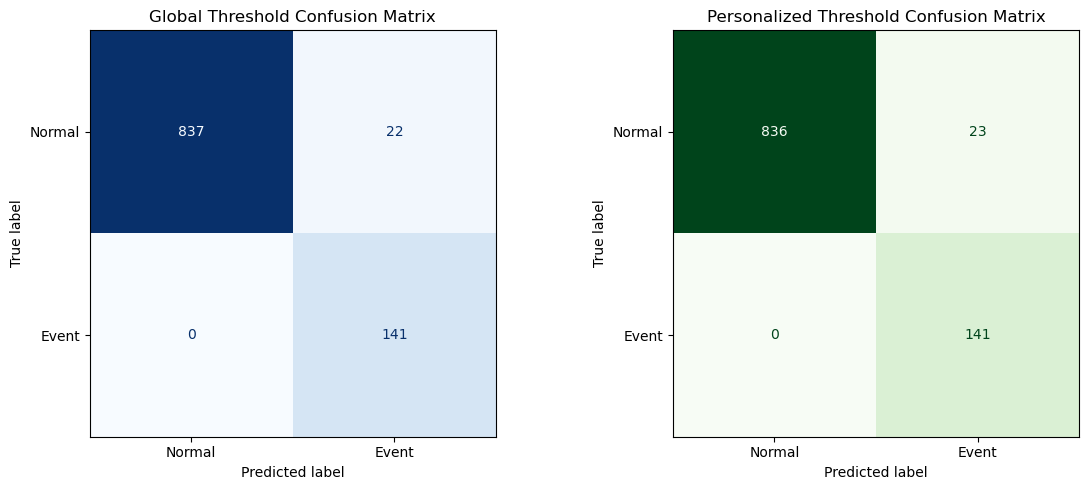

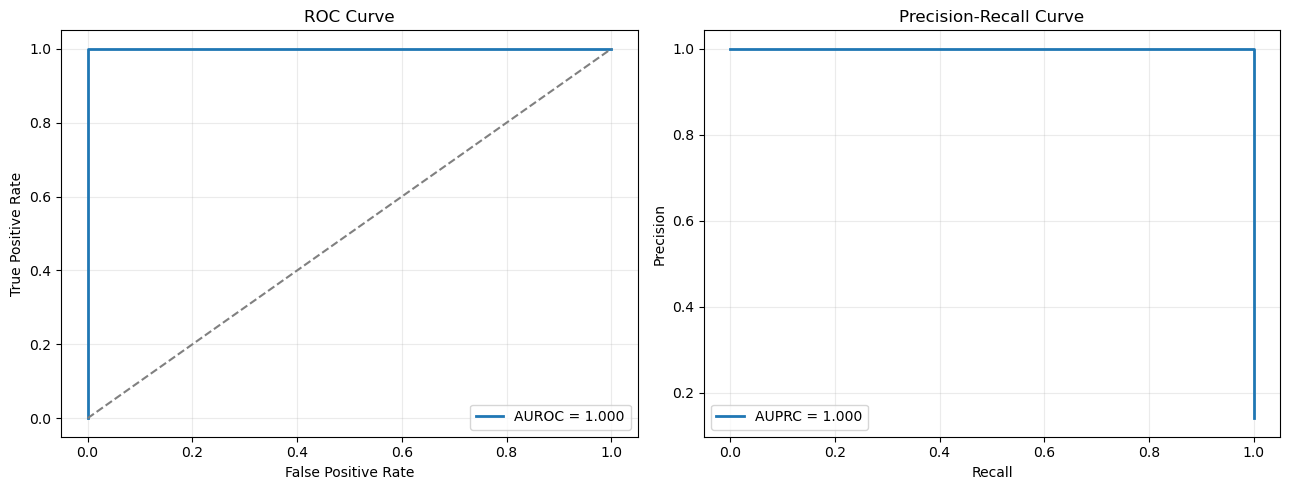

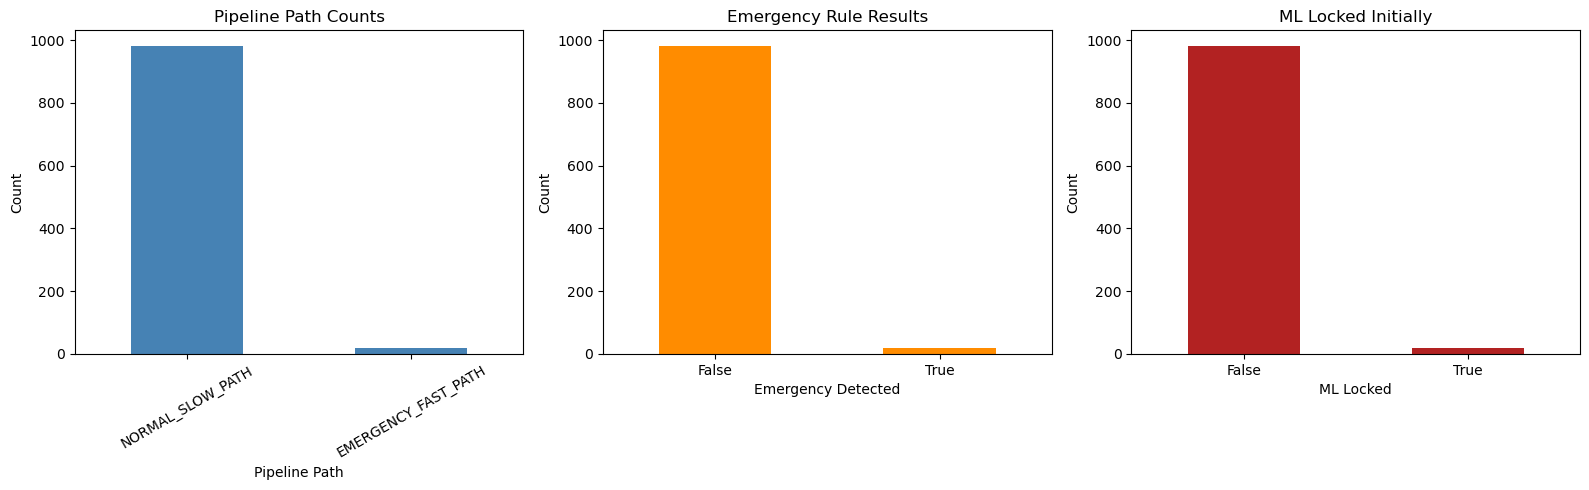

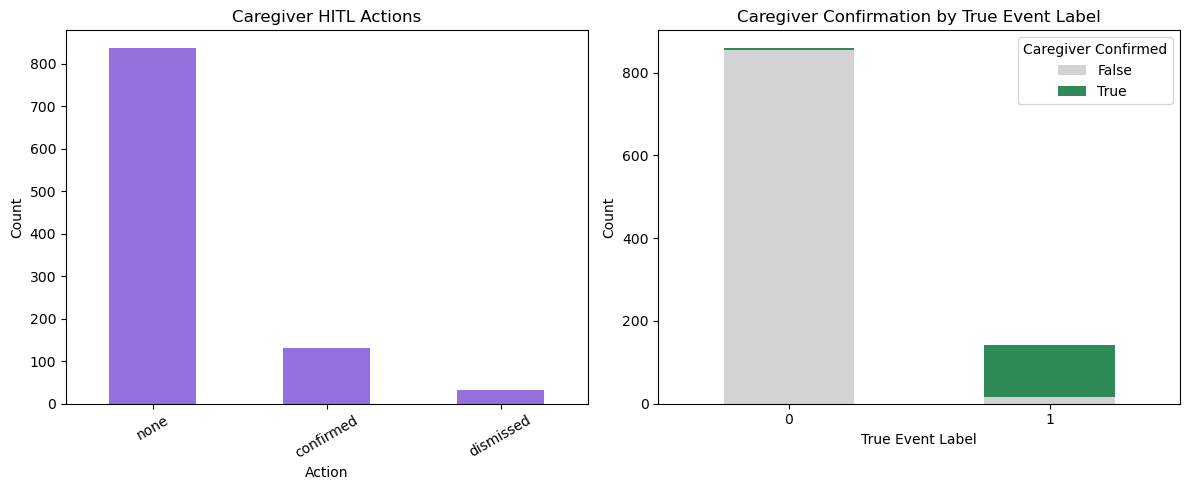

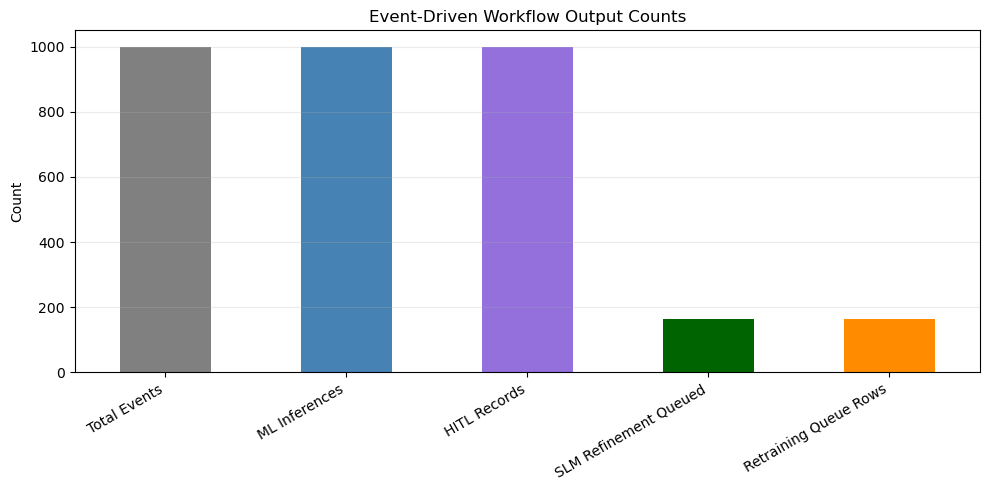


=== Workflow Output Counts ===


,count
Total Events,1000
ML Inferences,1000
HITL Records,1000
SLM Refinement Queued,163
Retraining Queue Rows,163


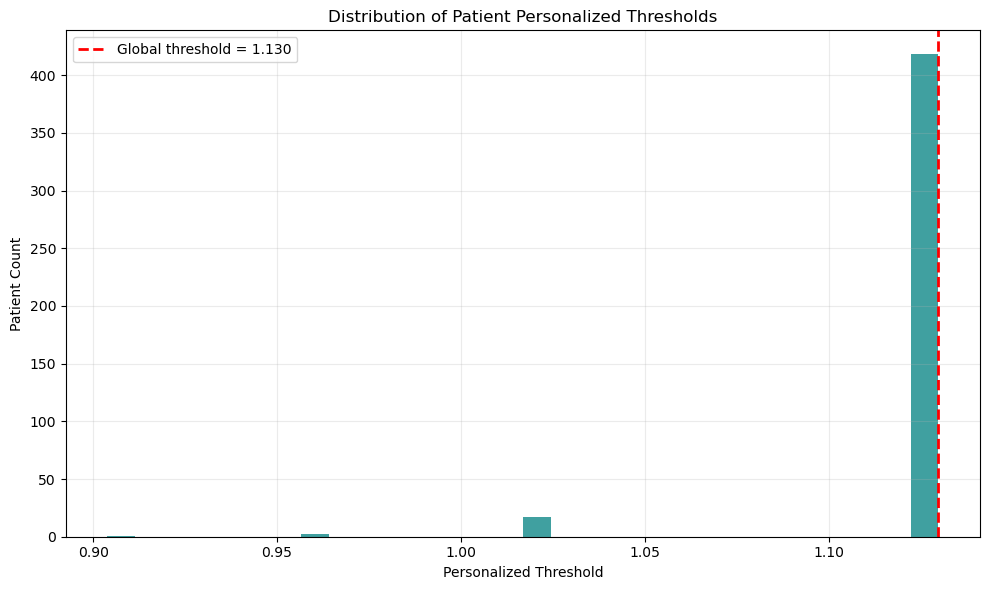


=== Top Updated Patient Profiles ===


,patient_id,personalized_threshold,confirmed_events,dismissed_alerts,true_positive_like_events,false_positive_like_events
94,PATIENT_0220,0.903878,4,0,4,0
65,PATIENT_0414,0.960371,3,0,3,0
169,PATIENT_0263,0.960371,3,0,3,0
16,PATIENT_0109,1.016863,2,0,2,0
59,PATIENT_0057,1.016863,2,0,2,0
62,PATIENT_0105,1.016863,2,0,2,0
75,PATIENT_0218,1.016863,2,0,2,0
84,PATIENT_0054,1.016863,2,0,2,0
99,PATIENT_0342,1.016863,2,0,2,0
100,PATIENT_0351,1.016863,2,0,2,0


C:\Users\jaymo\AppData\Local\Temp\ipykernel_26560\3668198313.py:379: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[str(h) for h in health_events_sorted], showfliers=True)


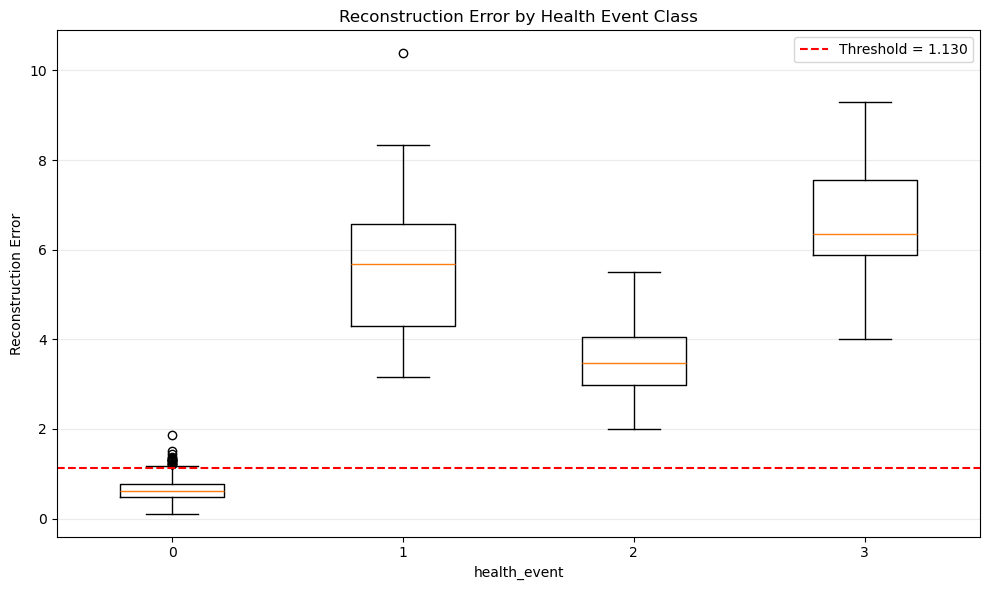


=== Health Event Summary ===


,health_event,count,mean_error,median_error,anomaly_rate_global,anomaly_rate_personalized,caregiver_confirm_rate,slm_queue_rate
0,0,859,0.638573,0.610659,0.025611,0.026775,0.004657,0.025611
1,1,51,5.622076,5.673047,1.000000,1.000000,0.843137,1.000000
2,2,51,3.564775,3.476982,1.000000,1.000000,0.960784,1.000000
3,3,39,6.590365,6.359695,1.000000,1.000000,0.871795,1.000000



=== Top Feature Contributors ===


,feature,mean_top_error,count_in_top5
6,stress_level,10.899598,506
8,heart_rate,5.030702,429
15,blood_pressure_diastolic,4.187869,2
1,sleep_quality,4.187179,524
10,respiratory_rate,3.651943,399
0,blood_oxygen,3.464823,400
3,glucose_level,3.313760,377
2,hrv_sdnn,3.066411,325
5,body_temperature,2.394247,354
12,steps_count,2.053696,429


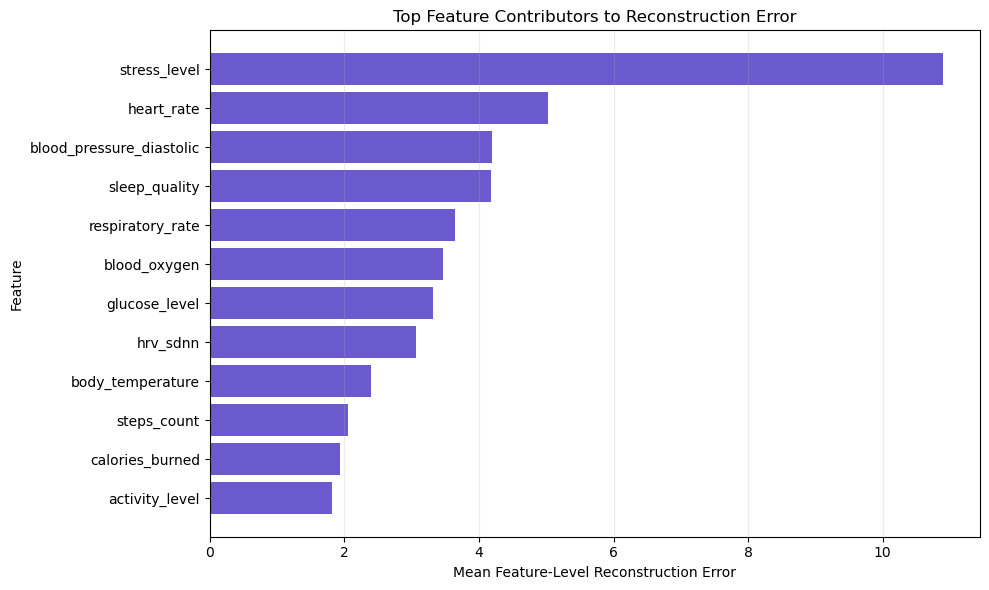

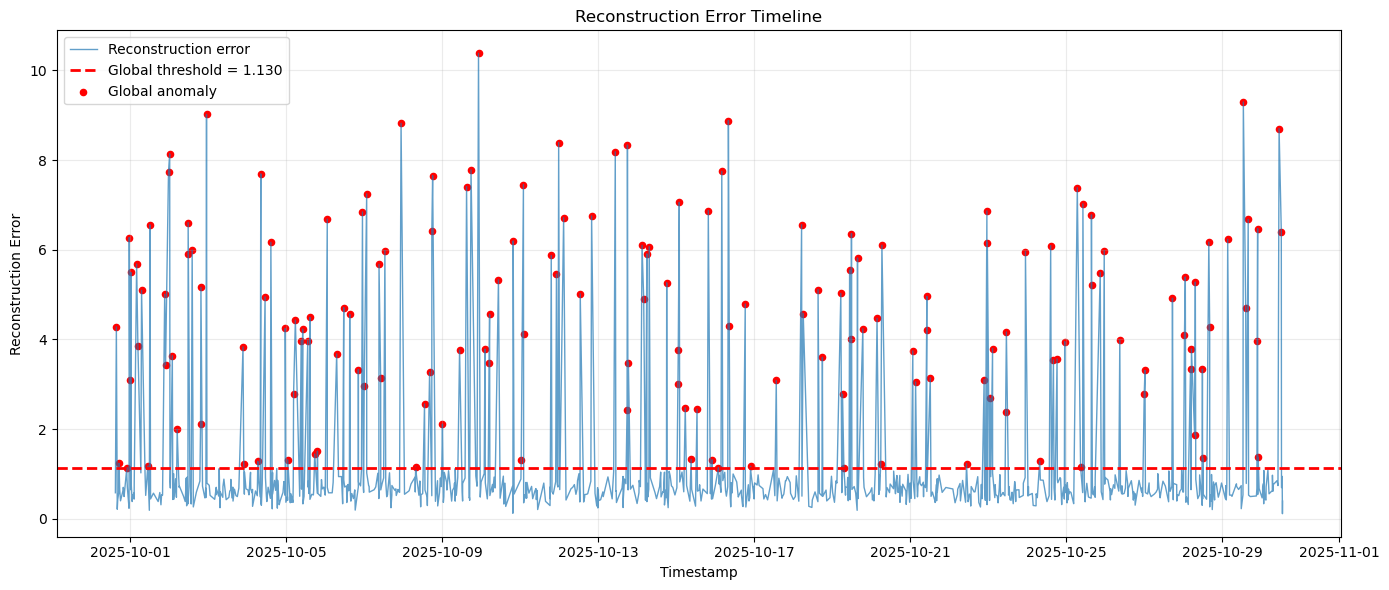


Final continuous personalization visualizations complete.
Saved to: continuous_personalization_sim\visualizations
Summary saved to: continuous_personalization_sim\final_visualization_summary.json
{
  "num_total_events": 1000,
  "num_ml_events": 1000,
  "num_emergency_events": 18,
  "num_ml_locked_initially": 18,
  "num_slm_refinement_queued": 163,
  "global_threshold": 1.1298478841781616,
  "model_version": "tiny_ae_uc2_v0.1.0",
  "metrics": [
    {
      "mode": "global_threshold",
      "n": 1000,
      "precision": 0.8650306748466258,
      "recall": 1.0,
      "f1": 0.9276315789473685,
      "tn": 837,
      "fp": 22,
      "fn": 0,
      "tp": 141,
      "false_positive_rate": 0.025611175785797437,
      "false_negative_rate": 0.0,
      "auroc": 1.0,
      "auprc": 1.0
    },
    {
      "mode": "personalized_threshold_sim",
      "n": 1000,
      "precision": 0.8597560975609756,
      "recall": 1.0,
      "f1": 0.9245901639344263,
      "tn": 836,
      "fp": 23,
      "fn": 0,

In [18]:
# FINAL CELL — Continuous Personalization Graphs & Metrics

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

# Setup

VIZ_DIR = os.path.join(OUTPUT_DIR, "visualizations")
os.makedirs(VIZ_DIR, exist_ok=True)

print("Saving visualizations to:", VIZ_DIR)

# Ensure timestamp format where possible
if "timestamp" in events_df.columns:
    events_df["timestamp"] = pd.to_datetime(events_df["timestamp"], errors="coerce")

# Keep only rows where ML actually ran
ml_events = events_df[events_df["ml_ran"] == True].copy()

if len(ml_events) == 0:
    raise ValueError("No ML events found. Check that events_df['ml_ran'] contains True rows.")

# Required columns check
required_cols = [
    "event_label",
    "reconstruction_error",
    "anomaly_detected_global",
    "anomaly_detected_personalized",
    "pipeline_path",
    "emergency",
    "caregiver_action",
    "caregiver_confirmed",
    "slm_refinement_queued"
]

missing_cols = [c for c in required_cols if c not in events_df.columns]
if missing_cols:
    print("Warning: missing columns:", missing_cols)

# Metric helpers

def safe_confusion_counts(y_true, y_pred):
    labels = [0, 1]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tn, fp, fn, tp = cm.ravel()
    return cm, tn, fp, fn, tp

def compute_metrics(y_true, y_pred, scores=None, name="model"):
    cm, tn, fp, fn, tp = safe_confusion_counts(y_true, y_pred)

    out = {
        "mode": name,
        "n": int(len(y_true)),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    }

    if scores is not None and len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, scores)
        out["auprc"] = average_precision_score(y_true, scores)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan

    return out

# Compute metrics

y_true = ml_events["event_label"].astype(int).values
scores = ml_events["reconstruction_error"].astype(float).values

y_pred_global = ml_events["anomaly_detected_global"].astype(int).values
y_pred_personalized = ml_events["anomaly_detected_personalized"].astype(int).values

summary_metrics = pd.DataFrame([
    compute_metrics(y_true, y_pred_global, scores=scores, name="global_threshold"),
    compute_metrics(y_true, y_pred_personalized, scores=scores, name="personalized_threshold_sim")
])

print("\n=== Global vs Personalized Threshold Metrics ===")
display(summary_metrics)

summary_metrics.to_csv(
    os.path.join(OUTPUT_DIR, "final_visualization_metrics_summary.csv"),
    index=False
)

# 1. Confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_global, *_ = safe_confusion_counts(y_true, y_pred_global)
cm_personalized, *_ = safe_confusion_counts(y_true, y_pred_personalized)

ConfusionMatrixDisplay(
    confusion_matrix=cm_global,
    display_labels=["Normal", "Event"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Global Threshold Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix=cm_personalized,
    display_labels=["Normal", "Event"]
).plot(ax=axes[1], cmap="Greens", colorbar=False)

axes[1].set_title("Personalized Threshold Confusion Matrix")

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "confusion_matrices_global_vs_personalized.png"), dpi=200)
plt.show()

# 2. Reconstruction error distribution

plt.figure(figsize=(10, 6))

normal_errors = ml_events.loc[ml_events["event_label"] == 0, "reconstruction_error"]
event_errors = ml_events.loc[ml_events["event_label"] == 1, "reconstruction_error"]

plt.hist(normal_errors, bins=40, alpha=0.65, label="Normal label", density=True)
plt.hist(event_errors, bins=40, alpha=0.65, label="Event label", density=True)

plt.axvline(THRESHOLD, linestyle="--", linewidth=2, label=f"Global threshold = {THRESHOLD:.3f}")

if "personalized_threshold" in ml_events.columns:
    median_personal_threshold = ml_events["personalized_threshold"].median()
    plt.axvline(
        median_personal_threshold,
        linestyle=":",
        linewidth=2,
        label=f"Median personalized threshold = {median_personal_threshold:.3f}"
    )

plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "reconstruction_error_distribution.png"), dpi=200)
plt.show()

# 3. ROC curve and Precision-Recall curve

if len(np.unique(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, scores)
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, scores)

    auroc = roc_auc_score(y_true, scores)
    auprc = average_precision_score(y_true, scores)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(fpr, tpr, linewidth=2, label=f"AUROC = {auroc:.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_title("ROC Curve")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(recall_curve, precision_curve, linewidth=2, label=f"AUPRC = {auprc:.3f}")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "roc_and_pr_curves.png"), dpi=200)
    plt.show()
else:
    print("Skipping ROC/PR curves because only one class is present in y_true.")

# 4. Pipeline path and emergency counts

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

events_df["pipeline_path"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Pipeline Path Counts")
axes[0].set_xlabel("Pipeline Path")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

events_df["emergency"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("Emergency Rule Results")
axes[1].set_xlabel("Emergency Detected")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

events_df["ml_locked_initially"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[2],
    color="firebrick"
)
axes[2].set_title("ML Locked Initially")
axes[2].set_xlabel("ML Locked")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "pipeline_emergency_ml_lock_counts.png"), dpi=200)
plt.show()

# 5. HITL caregiver action summary

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

events_df["caregiver_action"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="mediumpurple"
)
axes[0].set_title("Caregiver HITL Actions")
axes[0].set_xlabel("Action")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

pd.crosstab(
    events_df["event_label"],
    events_df["caregiver_confirmed"]
).plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["lightgray", "seagreen"]
)
axes[1].set_title("Caregiver Confirmation by True Event Label")
axes[1].set_xlabel("True Event Label")
axes[1].set_ylabel("Count")
axes[1].legend(title="Caregiver Confirmed")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "hitl_caregiver_actions.png"), dpi=200)
plt.show()

# 6. SLM refinement and retraining queue counts

queue_counts = pd.Series({
    "Total Events": len(events_df),
    "ML Inferences": len(ml_log_df) if "ml_log_df" in globals() else int(events_df["ml_ran"].sum()),
    "HITL Records": len(hitl_df) if "hitl_df" in globals() else len(events_df),
    "SLM Refinement Queued": int(events_df["slm_refinement_queued"].sum()),
    "Retraining Queue Rows": len(retraining_df) if "retraining_df" in globals() else int(events_df["slm_refinement_queued"].sum())
})

plt.figure(figsize=(10, 5))
queue_counts.plot(kind="bar", color=["gray", "steelblue", "mediumpurple", "darkgreen", "darkorange"])
plt.title("Event-Driven Workflow Output Counts")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "workflow_output_counts.png"), dpi=200)
plt.show()

print("\n=== Workflow Output Counts ===")
display(queue_counts.to_frame("count"))

# 7. Patient personalization threshold distribution

if "profiles_df" in globals() and len(profiles_df) > 0:
    plt.figure(figsize=(10, 6))

    plt.hist(
        profiles_df["personalized_threshold"].dropna(),
        bins=30,
        alpha=0.75,
        color="teal"
    )

    plt.axvline(
        THRESHOLD,
        linestyle="--",
        linewidth=2,
        color="red",
        label=f"Global threshold = {THRESHOLD:.3f}"
    )

    plt.title("Distribution of Patient Personalized Thresholds")
    plt.xlabel("Personalized Threshold")
    plt.ylabel("Patient Count")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "personalized_threshold_distribution.png"), dpi=200)
    plt.show()

    top_profiles = profiles_df.sort_values(
        by=["confirmed_events", "dismissed_alerts"],
        ascending=False
    ).head(15)

    display_cols = [
        "patient_id",
        "personalized_threshold",
        "confirmed_events",
        "dismissed_alerts",
        "true_positive_like_events",
        "false_positive_like_events"
    ]

    display_cols = [c for c in display_cols if c in top_profiles.columns]

    print("\n=== Top Updated Patient Profiles ===")
    display(top_profiles[display_cols])
else:
    print("Skipping patient profile visualization because profiles_df is missing or empty.")

# 8. Reconstruction error by health_event

if "health_event" in ml_events.columns:
    plt.figure(figsize=(10, 6))

    health_events_sorted = sorted(ml_events["health_event"].dropna().unique())

    data_to_plot = [
        ml_events.loc[ml_events["health_event"] == h, "reconstruction_error"].values
        for h in health_events_sorted
    ]

    plt.boxplot(data_to_plot, labels=[str(h) for h in health_events_sorted], showfliers=True)
    plt.axhline(THRESHOLD, linestyle="--", color="red", label=f"Threshold = {THRESHOLD:.3f}")

    plt.title("Reconstruction Error by Health Event Class")
    plt.xlabel("health_event")
    plt.ylabel("Reconstruction Error")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "reconstruction_error_by_health_event.png"), dpi=200)
    plt.show()

    health_event_summary = ml_events.groupby("health_event").agg(
        count=("reconstruction_error", "size"),
        mean_error=("reconstruction_error", "mean"),
        median_error=("reconstruction_error", "median"),
        anomaly_rate_global=("anomaly_detected_global", "mean"),
        anomaly_rate_personalized=("anomaly_detected_personalized", "mean"),
        caregiver_confirm_rate=("caregiver_confirmed", "mean"),
        slm_queue_rate=("slm_refinement_queued", "mean")
    ).reset_index()

    print("\n=== Health Event Summary ===")
    display(health_event_summary)

    health_event_summary.to_csv(
        os.path.join(OUTPUT_DIR, "final_health_event_summary.csv"),
        index=False
    )

# 9. Top reconstructed-error feature contributors

if "top_features" in ml_events.columns:
    feature_contrib = {}

    for item in ml_events["top_features"].dropna():
        try:
            parsed = json.loads(item) if isinstance(item, str) else item

            for feature, value in parsed:
                feature_contrib.setdefault(feature, []).append(float(value))

        except Exception:
            pass

    if len(feature_contrib) > 0:
        feature_contrib_df = pd.DataFrame([
            {
                "feature": feature,
                "mean_top_error": np.mean(values),
                "count_in_top5": len(values)
            }
            for feature, values in feature_contrib.items()
        ]).sort_values("mean_top_error", ascending=False)

        print("\n=== Top Feature Contributors ===")
        display(feature_contrib_df.head(15))

        feature_contrib_df.to_csv(
            os.path.join(OUTPUT_DIR, "final_top_feature_contributors.csv"),
            index=False
        )

        plt.figure(figsize=(10, 6))
        plot_df = feature_contrib_df.head(12).sort_values("mean_top_error", ascending=True)

        plt.barh(plot_df["feature"], plot_df["mean_top_error"], color="slateblue")
        plt.title("Top Feature Contributors to Reconstruction Error")
        plt.xlabel("Mean Feature-Level Reconstruction Error")
        plt.ylabel("Feature")
        plt.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_DIR, "top_feature_contributors.png"), dpi=200)
        plt.show()
    else:
        print("No parsable top feature data found.")

# 10. Timeline plot if timestamps are available

if "timestamp" in ml_events.columns and ml_events["timestamp"].notna().sum() > 0:
    timeline_df = ml_events.sort_values("timestamp").copy()

    plt.figure(figsize=(14, 6))

    plt.plot(
        timeline_df["timestamp"],
        timeline_df["reconstruction_error"],
        linewidth=1,
        alpha=0.7,
        label="Reconstruction error"
    )

    plt.axhline(
        THRESHOLD,
        linestyle="--",
        color="red",
        linewidth=2,
        label=f"Global threshold = {THRESHOLD:.3f}"
    )

    anomaly_points = timeline_df[timeline_df["anomaly_detected_global"] == True]

    plt.scatter(
        anomaly_points["timestamp"],
        anomaly_points["reconstruction_error"],
        color="red",
        s=20,
        label="Global anomaly"
    )

    plt.title("Reconstruction Error Timeline")
    plt.xlabel("Timestamp")
    plt.ylabel("Reconstruction Error")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "reconstruction_error_timeline.png"), dpi=200)
    plt.show()
else:
    print("Skipping timeline plot because timestamps are unavailable.")

# 11. Save final summary JSON

final_summary = {
    "num_total_events": int(len(events_df)),
    "num_ml_events": int(len(ml_events)),
    "num_emergency_events": int(events_df["emergency"].sum()) if "emergency" in events_df.columns else None,
    "num_ml_locked_initially": int(events_df["ml_locked_initially"].sum()) if "ml_locked_initially" in events_df.columns else None,
    "num_slm_refinement_queued": int(events_df["slm_refinement_queued"].sum()) if "slm_refinement_queued" in events_df.columns else None,
    "global_threshold": float(THRESHOLD),
    "model_version": MODEL_VERSION,
    "metrics": summary_metrics.to_dict(orient="records"),
    "visualization_dir": VIZ_DIR
}

with open(os.path.join(OUTPUT_DIR, "final_visualization_summary.json"), "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n============================================================")
print("Final continuous personalization visualizations complete.")
print("Saved to:", VIZ_DIR)
print("Summary saved to:", os.path.join(OUTPUT_DIR, "final_visualization_summary.json"))
print("============================================================")
print(json.dumps(final_summary, indent=2))

## UC2 Presentation Validation — Display Only

,object,exists,detail
0,events_df,True,"DataFrame shape=(1000, 23)"
1,ml_log_df,True,"DataFrame shape=(1000, 7)"
2,hitl_df,True,"DataFrame shape=(1000, 7)"
3,profiles_df,True,"DataFrame shape=(438, 8)"
4,slm_queue,True,list length=163
5,retraining_df,True,"DataFrame shape=(163, 12)"
6,THRESHOLD,True,float: 1.1298478841781616
7,MODEL_VERSION,True,str: tiny_ae_uc2_v0.1.0


## 1. Executive Workflow Validation Table

,validation_item,result,presentation_meaning
0,Total rows/events processed,1000,Dataset rows were routed through the UC2 workflow simulation.
1,Emergency fast-path events,0,Rule Engine detected high-severity cases before ML.
2,ML lockout events,0,"Emergency rows bypassed ML initially, matching safety architecture."
3,ML log rows,1000,Autoencoder inference outputs were logged for auditability.
4,Autoencoder anomaly flags,N/A,Slow-path anomaly detections generated by the tiny AE.
5,Caregiver HITL records,1000,Structured caregiver feedback was captured.
6,Patient personalization profiles,438,Patient-specific profile state was updated.
7,SLM refinement payloads,163,Grounded ML + HITL context was packaged for SLM interpretation.
8,Future retraining/refinement queue rows,163,Feedback-linked examples were queued for future model improvement.
9,Model version,tiny_ae_uc2_v0.1.0,Model artifact version is available for traceability.


## 2. UC2 Workflow Diagram

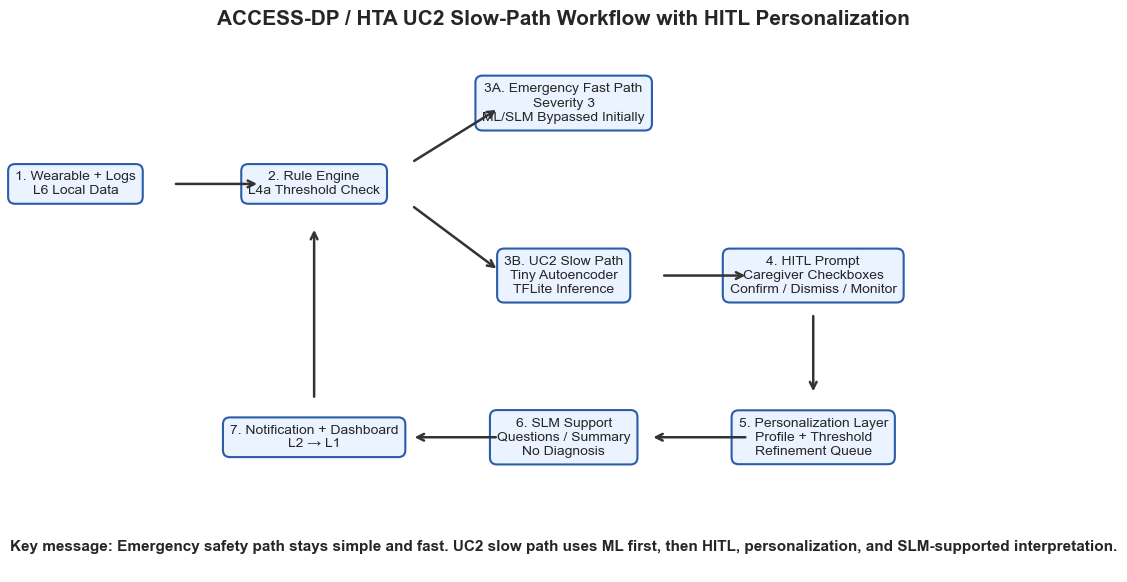

## 3. Workflow Routing Counts

No routing/path column found in events_df.
No emergency or ML lockout columns found.


## 4. Global vs Personalized Metrics

Could not compute metrics because health_event and/or anomaly flag columns were not found.
Detected health_event_col: health_event
Detected ae_flag_col: None


## 5. Reconstruction Error Distribution

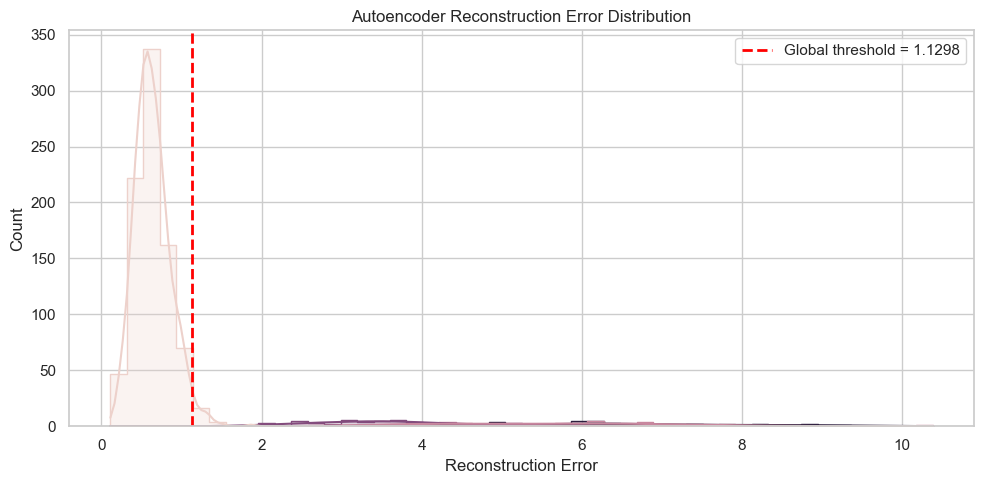

,reconstruction_error_summary
count,1000.000000
mean,1.274088
std,1.717371
min,0.111353
25%,0.506846
50%,0.659417
75%,0.904405
max,10.381976


## 6. Caregiver HITL Action Summary

,patient_id,timestamp,caregiver_action,caregiver_confirmed,caregiver_observations,health_event,event_label
0,PATIENT_0289,2025-10-06 10:44:45.056387,none,False,[],0,0
1,PATIENT_0075,2025-10-21 07:59:45.056387,none,False,[],0,0
2,PATIENT_0246,2025-10-05 15:44:45.056387,none,False,[],0,0
3,PATIENT_0196,2025-10-20 21:14:45.056387,none,False,[],0,0
4,PATIENT_0069,2025-10-01 00:20:45.056387,none,False,[],0,0
5,PATIENT_0237,2025-10-15 15:13:45.056387,none,False,[],0,0
6,PATIENT_0249,2025-10-11 04:10:45.056387,none,False,[],0,0
7,PATIENT_0280,2025-10-28 11:43:45.056387,confirmed,True,"[reduced activity, poor sleep]",2,1
8,PATIENT_0129,2025-10-18 17:54:45.056387,confirmed,True,"[reduced activity, poor sleep]",2,1
9,PATIENT_0115,2025-10-13 01:28:45.056387,none,False,[],0,0


,caregiver_action,count,percent
0,none,837,83.7
1,confirmed,130,13.0
2,dismissed,33,3.3


C:\Users\jaymo\AppData\Local\Temp\ipykernel_26560\1689467879.py:470: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=action_counts, x="caregiver_action", y="count", palette="Purples")


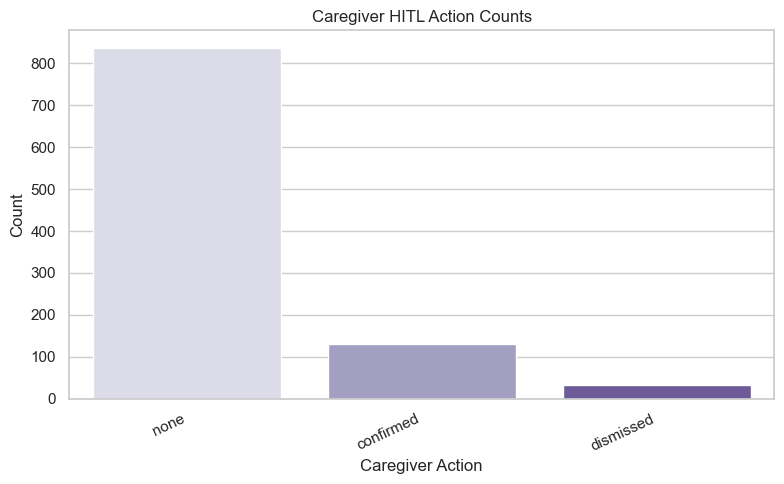

## 7. Patient Personalization Profiles

,patient_id,base_threshold,personalized_threshold,confirmed_events,dismissed_alerts,false_positive_like_events,true_positive_like_events,last_updated
94,PATIENT_0220,1.129848,0.903878,4,0,0,4,2026-06-18T17:57:25.245769
65,PATIENT_0414,1.129848,0.960371,3,0,0,3,2026-06-18T17:57:25.349258
169,PATIENT_0263,1.129848,0.960371,3,0,0,3,2026-06-18T17:57:25.345542
16,PATIENT_0109,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.352485
59,PATIENT_0057,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.272402
62,PATIENT_0105,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.421418
75,PATIENT_0218,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.391152
84,PATIENT_0054,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.306652
99,PATIENT_0342,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.311176
100,PATIENT_0351,1.129848,1.016863,2,0,0,2,2026-06-18T17:57:25.204446


,profile_metric,value
0,Number of patient profiles,438.000000
1,Mean personalized threshold,1.124173
2,Min personalized threshold,0.903878
3,Max personalized threshold,1.129848
4,Total confirmed events,130.000000


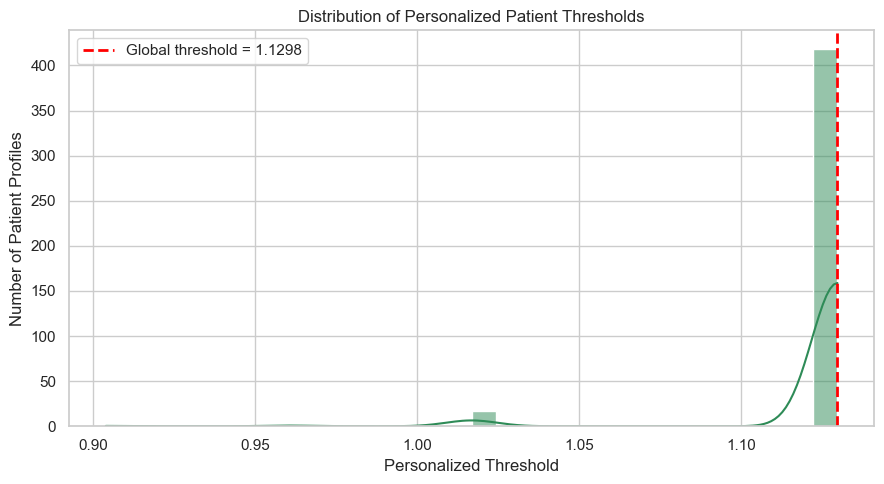

,patient_id,personalized_threshold,threshold_delta_from_global,confirmed_events
94,PATIENT_0220,0.903878,-0.225970,4
169,PATIENT_0263,0.960371,-0.169477,3
65,PATIENT_0414,0.960371,-0.169477,3
163,PATIENT_0093,1.016863,-0.112985,2
314,PATIENT_0256,1.016863,-0.112985,2
239,PATIENT_0216,1.016863,-0.112985,2
227,PATIENT_0006,1.016863,-0.112985,2
197,PATIENT_0487,1.016863,-0.112985,2
195,PATIENT_0363,1.016863,-0.112985,2
176,PATIENT_0344,1.016863,-0.112985,2


## 8. Logs and Queues Validation

,artifact,count,role
0,events_df,1000,Main workflow event table
1,ml_log_df,1000,AE inference and audit log
2,hitl_df,1000,Structured caregiver feedback records
3,profiles_df,438,Patient personalization profile state
4,slm_queue,163,Grounded SLM interpretation/refinement payloads
5,retraining_df,163,Future retraining/refinement candidate examples


### ML Log Sample

,patient_id,timestamp,model_version,reconstruction_error,threshold,anomaly_detected,input_hash
0,PATIENT_0289,2025-10-06 10:44:45.056387,tiny_ae_uc2_v0.1.0,0.333599,1.129848,False,754b62d3dbfe2e491ed1366752c1aa25ee88d2f9b12c45d008c8f2e52a4d7947
1,PATIENT_0075,2025-10-21 07:59:45.056387,tiny_ae_uc2_v0.1.0,0.814120,1.129848,False,43144340c53b06723da304dfb334a3e31284775a9f97fae0dc7f4c60a0eda67b
2,PATIENT_0246,2025-10-05 15:44:45.056387,tiny_ae_uc2_v0.1.0,0.543931,1.129848,False,f1387edcaf917170228b4453117e9726671cbcab6c7142ba949a59c17059dbb0
3,PATIENT_0196,2025-10-20 21:14:45.056387,tiny_ae_uc2_v0.1.0,0.621658,1.129848,False,74b6b98aca0c5a4ecb2bb2ac91b66e02efa62ec8740c98b954908b5a29a498ca
4,PATIENT_0069,2025-10-01 00:20:45.056387,tiny_ae_uc2_v0.1.0,0.646603,1.129848,False,100a159fa12e2e243577805dc9ed66f46bac36d6d1e235cd63cffc7594716033
5,PATIENT_0237,2025-10-15 15:13:45.056387,tiny_ae_uc2_v0.1.0,0.395043,1.129848,False,0e7820078bc226742a254aa259e33e900a13a1b7b2e1c306b50b6bdb9e2709ab
6,PATIENT_0249,2025-10-11 04:10:45.056387,tiny_ae_uc2_v0.1.0,0.809297,1.129848,False,ec9626893a9236fafa257f1dd00b1278c807db4ac7384492808ff534e588feff
7,PATIENT_0280,2025-10-28 11:43:45.056387,tiny_ae_uc2_v0.1.0,3.334940,1.129848,True,0c55ece1d7c5263db48a6964e155656b1334c5f3620279b3afa82743a778a6f2
8,PATIENT_0129,2025-10-18 17:54:45.056387,tiny_ae_uc2_v0.1.0,3.600692,1.129848,True,9b8a11e8a61a257ac66e7384f9d48413f9d0b8f00f87635e439d25165311d9f3
9,PATIENT_0115,2025-10-13 01:28:45.056387,tiny_ae_uc2_v0.1.0,0.422918,1.129848,False,75b596c2c961a5b62e9dfc381ac8599c372465d717805b304a93e7ab774fee9f


### Retraining / Refinement Queue Sample

,patient_id,timestamp,health_event,event_label,caregiver_confirmed,caregiver_action,caregiver_observations,reconstruction_error,anomaly_detected,feature_vector_raw,feature_vector_scaled,input_hash
0,PATIENT_0280,2025-10-28 11:43:45.056387,2,1,True,confirmed,"[reduced activity, poor sleep]",3.334940,True,"[88.69999694824219, 94.0999984741211, 126.0, 71.0, 49.099998474121094, 98.12000274658203, 17.200000762939453, 0.2639999985694885, 0.5979999899864197, 0.7080...","[1.388352632522583, -1.9602901935577393, 0.7508610486984253, -1.4965627193450928, -3.3646085262298584, -0.9569522738456726, 0.6049491763114929, -1.978605151...",0c55ece1d7c5263db48a6964e155656b1334c5f3620279b3afa82743a778a6f2
1,PATIENT_0129,2025-10-18 17:54:45.056387,2,1,True,confirmed,"[reduced activity, poor sleep]",3.600692,True,"[98.19999694824219, 97.0999984741211, 99.0, 59.0, 53.5, 98.0199966430664, 15.800000190734863, 0.23899999260902405, 0.5659999847412109, 0.6570000052452087, 1...","[2.3594207763671875, 0.08299451321363449, -2.6009647846221924, -3.488630771636963, -3.073406934738159, -1.1572707891464233, -0.11179026961326599, -2.1524801...",9b8a11e8a61a257ac66e7384f9d48413f9d0b8f00f87635e439d25165311d9f3
2,PATIENT_0185,2025-10-06 11:23:45.056387,1,1,False,dismissed,[],4.708022,True,"[49.29999923706055, 93.9000015258789, 146.0, 94.0, 108.5999984741211, 99.33999633789062, 18.899999618530273, 0.3779999911785126, 0.5450000166893005, 0.88200...","[-2.6390249729156494, -2.0965070724487305, 3.2336950302124023, 2.3215672969818115, 0.5732299089431763, 1.486772060394287, 1.4752745628356934, -1.18573570251...",88ef0119d1389b17064c2f39e89e2d757187cc7384dfc6b3567b4ae6be72334e
3,PATIENT_0212,2025-10-22 21:24:45.056387,2,1,True,confirmed,"[reduced activity, poor sleep]",3.103618,True,"[80.69999694824219, 96.19999694824219, 102.0, 75.0, 52.29999923706055, 97.73999786376953, 18.799999237060547, 0.22599999606609344, 0.42800000309944153, 0.52...","[0.5706109404563904, -0.5299919247627258, -2.2285397052764893, -0.8325401544570923, -3.1528255939483643, -1.7181260585784912, 1.4240787029266357, -2.2428948...",fafc082d0426d921bfac0ec73034e1b41545c5c0ff2cd8fdbe885cc9647b766a
4,PATIENT_0382,2025-10-02 04:55:45.056387,2,1,True,confirmed,"[reduced activity, poor sleep]",1.994072,True,"[91.5, 96.80000305175781, 127.0, 64.0, 44.70000076293945, 98.30999755859375, 16.0, 0.1860000044107437, 0.5709999799728394, 0.5019999742507935, 55.5, 3289.0,...","[1.6745624542236328, -0.12133082747459412, 0.8750027418136597, -2.658602476119995, -3.6558098793029785, -0.5763806104660034, -0.009399066679179668, -2.52109...",4dce23cbdcaf31402bbf6c0fe11c701265d019dba4ef37d8a898021bdec48bd8
5,PATIENT_0266,2025-10-12 19:54:45.056387,3,1,False,dismissed,[],6.753829,True,"[125.0, 94.69999694824219, 168.0, 98.0, 143.39999389648438, 99.43000030517578, 17.700000762939453, 0.3059999942779541, 0.25099998712539673, 0.76200002431869...","[5.098855495452881, -1.5516341924667358, 5.964812278747559, 2.9855899810791016, 2.876368761062622, 1.6670557260513306, 0.860927402973175, -1.686495304107666...",95ea407e7a3f20989dea34125bf21e821c3e09be8a2c362f5d38e58f1a6c7d30
6,PATIENT_0051,2025-10-28 06:56:45.056387,0,0,False,dismissed,[],1.868801,True,"[87.80000305175781, 93.4000015258789, 101.0, 77.0, 116.5, 97.81999969482422, 10.0, 0.4390000104904175, 0.9359999895095825, 0.14300000667572021, 58.599998474...","[1.2963573932647705, -2.437054395675659, -2.3526813983917236, -0.500528872013092, 1.096069097518921, -1.5578773021697998, -3.0811381340026855, -0.7614808082...",cd993457e329882132d722bb1af776da41ab7b82713c86f5094f1cca63b129ef
7,PATIENT_0105,2025-10-07 01:31:45.056387,1,1,True,confirmed,"[reduced activity, poor sleep, breathing concern, elevated heart rate]",7.243576,True,"[127.5999984741211, 92.0999984741211, 138.0, 85.0, 136.39999389648438, 99.70999908447266, 21.399999618530273, 0.5550000071525574, 0.42899999022483826, 0.838...","[5.364621639251709, -3.322479724884033, 2.2405614852905273, 0.827516496181488, 2.4130935668945312, 2

## 9. Dataset Label / health_event Behavior

,health_event,count,percent
0,0,859,85.9
1,1,51,5.1
2,2,51,5.1
3,3,39,3.9


C:\Users\jaymo\AppData\Local\Temp\ipykernel_26560\1689467879.py:644: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_counts, x="health_event", y="count", palette="coolwarm")


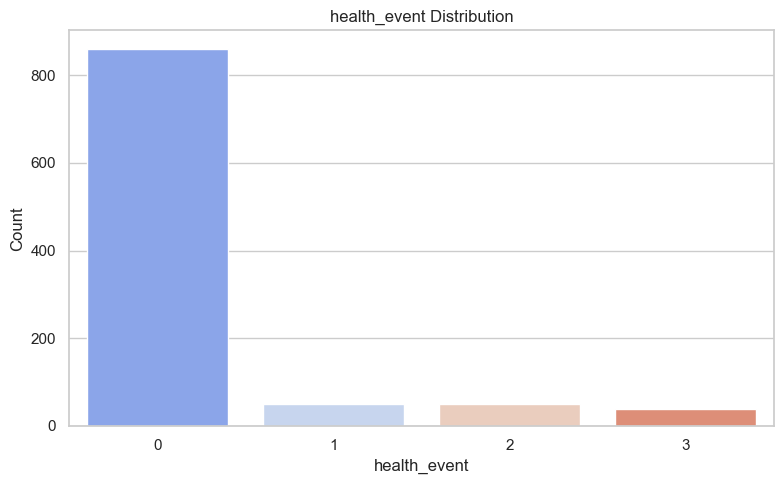

C:\Users\jaymo\AppData\Local\Temp\ipykernel_26560\1689467879.py:653: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=events_df, x=health_event_col, y=score_col_events, palette="coolwarm")


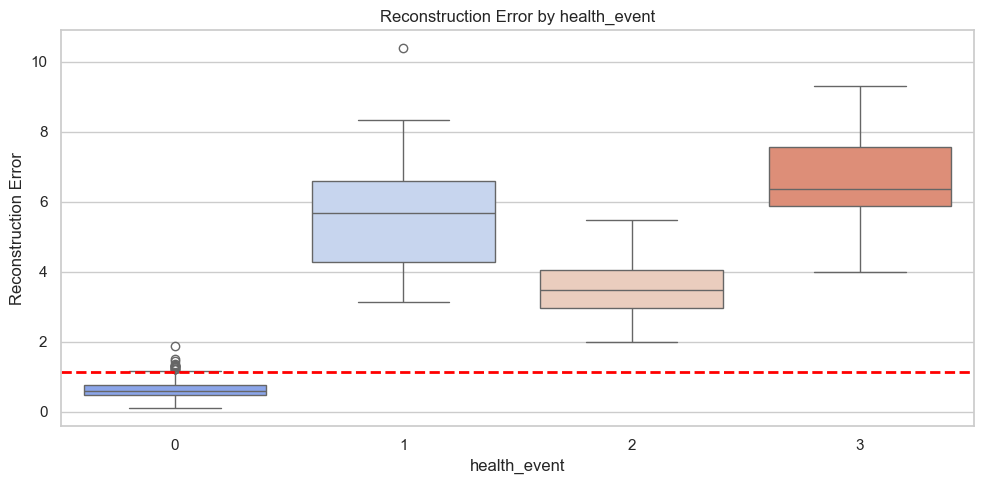

,health_event,count,mean,median,std,min,max
0,0,859,0.638573,0.610659,0.224006,0.111353,1.868801
1,1,51,5.622076,5.673047,1.486696,3.149410,10.381976
2,2,51,3.564775,3.476982,0.894696,1.994072,5.493216
3,3,39,6.590365,6.359695,1.375315,4.009038,9.297909


## 10. Anomaly-Type-Aware HITL Interpretation

,anomaly_type,typical_ml_pattern,caregiver_response,decision_engine_interpretation,personalization_update
0,EXERTION_LIKE,High heart rate + high activity/steps + normal oxygen,Exercising or active,Likely explainable context; continue monitoring unless symptoms are concerning.,Reduce future alert sensitivity for this pattern if repeatedly confirmed as benign.
1,LOW_ACTIVITY_HIGH_HR,High heart rate + low movement/activity,Nothing unusual / tired / weak / not acting normal,Caregiver response supports concern; ask follow-up questions or escalate.,Increase confidence for this pattern for this patient.
2,RESPIRATORY_CONCERN,Low blood oxygen + elevated respiratory rate,Breathing different / confused / weak,Potentially serious; rule engine may escalate if threshold is severe.,Do not suppress solely based on dismissals; safety rule remains dominant.
3,GI_AUTONOMIC_RISK,Elevated HR/stress + low activity + vomiting/bowel/bladder issue,"Vomiting/diarrhea, bathroom changes, missed medication",Relevant to UC2 style slow-path anomaly; SLM can ask structured follow-up.,Store as confirmed contextual risk pattern.
4,POSSIBLE_SENSOR_ARTIFACT,Abrupt impossible jump/drop or inconsistent vitals,Sensor/watch issue,Likely data quality issue; avoid over-escalation and request device check.,Track device reliability separately from patient physiology.
5,SLEEP_STRESS_RECOVERY,Poor sleep + high stress + HRV drop,Poor sleep / stress / pain,May justify monitoring or follow-up questions rather than urgent escalation.,Profile patient-specific baseline for sleep/stress recovery.


## 11. Example Grounded SLM Payload

Example SLM payload from queue:
{
  "queue_type": "SLM_HEURISTIC_REFINEMENT",
  "event_type": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "patient_id": "PATIENT_0280",
  "device_id": "DEVICE_0154",
  "timestamp": "2025-10-28 11:43:45.056387",
  "model": {
    "model_version": "tiny_ae_uc2_v0.1.0",
    "threshold": 1.1298478841781616,
    "personalized_threshold": 1.1298478841781616,
    "reconstruction_error": 3.334939956665039,
    "anomaly_detected": true,
    "input_hash": "0c55ece1d7c5263db48a6964e155656b1334c5f3620279b3afa82743a778a6f2",
    "top_features": [
      [
        "stress_level",
        23.191972804096622
      ],
      [
        "glucose_level",
        11.458927076984992
      ],
      [
        "calories_burned",
        5.851854704597827
      ],
      [
        "steps_count",
        5.793924774758352
      ],
      [
        "blood_oxygen",
        4.266546416376116
      ]
    ]
  },
  "rule_engine": {
    "is_emergency": false,
    "severity": 1,
    "reasons": []
  


**Presentation wording:**  
The SLM does not decide whether the data is anomalous. The tiny autoencoder and rule engine produce structured evidence first.  
The SLM receives grounded context — model score, threshold, top feature deviations, caregiver responses, and patient profile — then helps generate safe follow-up questions or a clinician-facing summary.


## 12. Final Presentation Summary

{
  "use_case": "UC2 slow-path anomaly detection",
  "event_name": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "model_version": "tiny_ae_uc2_v0.1.0",
  "global_threshold": 1.1298478841781616,
  "rows_processed": 1000,
  "emergency_fast_path_events": 0,
  "ml_initially_locked_events": 0,
  "ml_log_rows": 1000,
  "hitl_records": 1000,
  "patient_profiles": 438,
  "slm_queue_payloads": 163,
  "retraining_queue_rows": 163,
  "important_caveat": "This validates the workflow around a static tiny autoencoder. Personalization is simulated through profile updates, threshold heuristics, HITL feedback, SLM refinement payloads, and a future retraining queue. It is not live on-device retraining."
}


In [19]:
# PRESENTATION VALIDATION CELL — DISPLAY ONLY, NO FILE SAVING
# Purpose:
#   Validate the UC2 continuous personalization + HITL simulation for presentation.
#
# This cell intentionally does NOT:
#   - create directories
#   - call to_csv()
#   - call json.dump()
#   - call plt.savefig()
#   - write any local files
#
# It only:
#   - prints summaries
#   - displays pandas tables
#   - shows matplotlib/seaborn plots inline

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)

def safe_len(obj):
    try:
        return len(obj)
    except Exception:
        return 0

def show_section(title):
    display(Markdown(f"## {title}"))

def show_subsection(title):
    display(Markdown(f"### {title}"))

def get_col(df, possible_cols, default=None):
    """
    Return first matching column name from possible_cols, else default.
    """
    if df is None:
        return default
    for c in possible_cols:
        if c in df.columns:
            return c
    return default

def safe_value_counts(df, col_name, normalize=False):
    if df is None or col_name not in df.columns:
        return pd.Series(dtype=float)
    return df[col_name].value_counts(normalize=normalize, dropna=False)

def pretty_json(obj, max_chars=5000):
    text = json.dumps(obj, indent=2, default=str)
    if len(text) > max_chars:
        text = text[:max_chars] + "\n... [TRUNCATED]"
    print(text)

# 0. Validate required objects exist

show_section("UC2 Presentation Validation — Display Only")

required_objects = [
    "events_df",
    "ml_log_df",
    "hitl_df",
    "profiles_df",
    "slm_queue",
    "retraining_df",
    "THRESHOLD",
    "MODEL_VERSION"
]

object_status = []

for obj_name in required_objects:
    exists = obj_name in globals()
    obj = globals().get(obj_name, None)

    if isinstance(obj, pd.DataFrame):
        detail = f"DataFrame shape={obj.shape}"
    elif isinstance(obj, list):
        detail = f"list length={len(obj)}"
    elif exists:
        detail = f"{type(obj).__name__}: {obj}"
    else:
        detail = "MISSING"

    object_status.append({
        "object": obj_name,
        "exists": exists,
        "detail": detail
    })

object_status_df = pd.DataFrame(object_status)
display(object_status_df)

missing = object_status_df.loc[~object_status_df["exists"], "object"].tolist()

if missing:
    raise NameError(
        f"Missing required notebook objects: {missing}. "
        "Run the continuous personalization/HITL simulation cell first."
    )

# 1. Executive workflow table

show_section("1. Executive Workflow Validation Table")

num_events = len(events_df)
num_ml_logs = len(ml_log_df)
num_hitl = len(hitl_df)
num_profiles = len(profiles_df)
num_slm_payloads = safe_len(slm_queue)
num_retraining_rows = len(retraining_df) if isinstance(retraining_df, pd.DataFrame) else safe_len(retraining_df)

emergency_col = get_col(events_df, ["is_emergency", "emergency_flag", "rule_engine_emergency"])
ml_locked_col = get_col(events_df, ["ml_locked", "ml_initially_locked", "ml_lockout"])
route_col = get_col(events_df, ["routing_path", "path", "workflow_path", "route"])
ae_flag_col = get_col(events_df, ["ae_anomaly_flag", "anomaly_flag", "ml_anomaly_flag", "is_anomaly"])
health_event_col = get_col(events_df, ["health_event", "event_label", "label"])
personalized_flag_col = get_col(events_df, ["personalized_anomaly_flag", "personalized_flag"])

num_emergency = int(events_df[emergency_col].sum()) if emergency_col else 0
num_ml_locked = int(events_df[ml_locked_col].sum()) if ml_locked_col else 0
num_ae_anomalies = int(events_df[ae_flag_col].sum()) if ae_flag_col else "N/A"

workflow_summary = pd.DataFrame([
    {
        "validation_item": "Total rows/events processed",
        "result": num_events,
        "presentation_meaning": "Dataset rows were routed through the UC2 workflow simulation."
    },
    {
        "validation_item": "Emergency fast-path events",
        "result": num_emergency,
        "presentation_meaning": "Rule Engine detected high-severity cases before ML."
    },
    {
        "validation_item": "ML lockout events",
        "result": num_ml_locked,
        "presentation_meaning": "Emergency rows bypassed ML initially, matching safety architecture."
    },
    {
        "validation_item": "ML log rows",
        "result": num_ml_logs,
        "presentation_meaning": "Autoencoder inference outputs were logged for auditability."
    },
    {
        "validation_item": "Autoencoder anomaly flags",
        "result": num_ae_anomalies,
        "presentation_meaning": "Slow-path anomaly detections generated by the tiny AE."
    },
    {
        "validation_item": "Caregiver HITL records",
        "result": num_hitl,
        "presentation_meaning": "Structured caregiver feedback was captured."
    },
    {
        "validation_item": "Patient personalization profiles",
        "result": num_profiles,
        "presentation_meaning": "Patient-specific profile state was updated."
    },
    {
        "validation_item": "SLM refinement payloads",
        "result": num_slm_payloads,
        "presentation_meaning": "Grounded ML + HITL context was packaged for SLM interpretation."
    },
    {
        "validation_item": "Future retraining/refinement queue rows",
        "result": num_retraining_rows,
        "presentation_meaning": "Feedback-linked examples were queued for future model improvement."
    },
    {
        "validation_item": "Model version",
        "result": MODEL_VERSION,
        "presentation_meaning": "Model artifact version is available for traceability."
    },
    {
        "validation_item": "Global AE threshold",
        "result": THRESHOLD,
        "presentation_meaning": "Static model threshold used before personalization adjustment."
    }
])

display(workflow_summary)

# 2. UC2 workflow diagram

show_section("2. UC2 Workflow Diagram")

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")

boxes = [
    ("1. Wearable + Logs\nL6 Local Data", 0.05, 0.72),
    ("2. Rule Engine\nL4a Threshold Check", 0.27, 0.72),
    ("3A. Emergency Fast Path\nSeverity 3\nML/SLM Bypassed Initially", 0.50, 0.87),
    ("3B. UC2 Slow Path\nTiny Autoencoder\nTFLite Inference", 0.50, 0.55),
    ("4. HITL Prompt\nCaregiver Checkboxes\nConfirm / Dismiss / Monitor", 0.73, 0.55),
    ("5. Personalization Layer\nProfile + Threshold\nRefinement Queue", 0.73, 0.25),
    ("6. SLM Support\nQuestions / Summary\nNo Diagnosis", 0.50, 0.25),
    ("7. Notification + Dashboard\nL2 → L1", 0.27, 0.25),
]

for text, x, y in boxes:
    ax.text(
        x, y, text,
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", fc="#EAF3FF", ec="#2A5CAA", lw=1.5)
    )

arrows = [
    ((0.14, 0.72), (0.22, 0.72)),
    ((0.36, 0.76), (0.44, 0.86)),
    ((0.36, 0.68), (0.44, 0.56)),
    ((0.59, 0.55), (0.67, 0.55)),
    ((0.73, 0.48), (0.73, 0.33)),
    ((0.67, 0.25), (0.58, 0.25)),
    ((0.44, 0.25), (0.36, 0.25)),
    ((0.27, 0.32), (0.27, 0.64)),
]

for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.8, color="#333333")
    )

ax.text(
    0.50,
    0.04,
    "Key message: Emergency safety path stays simple and fast. UC2 slow path uses ML first, then HITL, personalization, and SLM-supported interpretation.",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.title("ACCESS-DP / HTA UC2 Slow-Path Workflow with HITL Personalization", fontsize=15, fontweight="bold")
plt.show()

# 3. Routing counts and emergency behavior

show_section("3. Workflow Routing Counts")

if route_col:
    routing_counts = events_df[route_col].value_counts(dropna=False).reset_index()
    routing_counts.columns = ["routing_path", "count"]
    routing_counts["percent"] = 100 * routing_counts["count"] / routing_counts["count"].sum()
    display(routing_counts)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=routing_counts, x="routing_path", y="count", palette="Blues_r")
    plt.title("Workflow Routing Counts")
    plt.xlabel("Routing Path")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No routing/path column found in events_df.")

if emergency_col or ml_locked_col:
    emergency_summary = pd.DataFrame([
        {
            "metric": "Emergency events",
            "count": num_emergency
        },
        {
            "metric": "ML initially locked/bypassed events",
            "count": num_ml_locked
        },
        {
            "metric": "Non-emergency events",
            "count": num_events - num_emergency
        }
    ])
    display(emergency_summary)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=emergency_summary, x="metric", y="count", palette="Reds")
    plt.title("Emergency Fast-Path and ML Lockout Validation")
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No emergency or ML lockout columns found.")

# 4. Global vs personalized metrics

show_section("4. Global vs Personalized Metrics")

if health_event_col and ae_flag_col:
    y_true = (events_df[health_event_col] != 0).astype(int)
    y_pred_global = events_df[ae_flag_col].astype(int)

    global_metrics = {
        "model": "Global AE threshold",
        "accuracy": accuracy_score(y_true, y_pred_global),
        "precision": precision_score(y_true, y_pred_global, zero_division=0),
        "recall": recall_score(y_true, y_pred_global, zero_division=0),
        "f1": f1_score(y_true, y_pred_global, zero_division=0),
    }

    metrics_rows = [global_metrics]

    if personalized_flag_col:
        y_pred_personalized = events_df[personalized_flag_col].astype(int)

        personalized_metrics = {
            "model": "Personalized threshold/profile logic",
            "accuracy": accuracy_score(y_true, y_pred_personalized),
            "precision": precision_score(y_true, y_pred_personalized, zero_division=0),
            "recall": recall_score(y_true, y_pred_personalized, zero_division=0),
            "f1": f1_score(y_true, y_pred_personalized, zero_division=0),
        }

        metrics_rows.append(personalized_metrics)

    metrics_df = pd.DataFrame(metrics_rows)
    display(metrics_df)

    # Confusion matrices
    cm_global = confusion_matrix(y_true, y_pred_global)

    fig, axes = plt.subplots(1, 2 if personalized_flag_col else 1, figsize=(12 if personalized_flag_col else 6, 5))

    if not personalized_flag_col:
        axes = [axes]

    sns.heatmap(
        cm_global,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix — Global AE Threshold")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].set_xticklabels(["Normal", "Anomaly"])
    axes[0].set_yticklabels(["Normal", "Anomaly"], rotation=0)

    if personalized_flag_col:
        cm_personalized = confusion_matrix(y_true, y_pred_personalized)
        sns.heatmap(
            cm_personalized,
            annot=True,
            fmt="d",
            cmap="Greens",
            cbar=False,
            ax=axes[1]
        )
        axes[1].set_title("Confusion Matrix — Personalized Logic")
        axes[1].set_xlabel("Predicted")
        axes[1].set_ylabel("Actual")
        axes[1].set_xticklabels(["Normal", "Anomaly"])
        axes[1].set_yticklabels(["Normal", "Anomaly"], rotation=0)

    plt.tight_layout()
    plt.show()

else:
    print("Could not compute metrics because health_event and/or anomaly flag columns were not found.")
    print("Detected health_event_col:", health_event_col)
    print("Detected ae_flag_col:", ae_flag_col)

# 5. Reconstruction error distribution

show_section("5. Reconstruction Error Distribution")

score_col_events = get_col(events_df, ["reconstruction_error", "ae_score", "score", "ml_score"])
score_col_ml = get_col(ml_log_df, ["reconstruction_error", "ae_score", "score", "ml_score"])

plot_df = None
score_col = None

if score_col_events:
    plot_df = events_df.copy()
    score_col = score_col_events
elif score_col_ml:
    plot_df = ml_log_df.copy()
    score_col = score_col_ml

if plot_df is not None and score_col:
    plt.figure(figsize=(10, 5))

    if health_event_col in plot_df.columns:
        sns.histplot(
            data=plot_df,
            x=score_col,
            hue=health_event_col,
            bins=50,
            kde=True,
            element="step"
        )
    else:
        sns.histplot(plot_df[score_col], bins=50, kde=True)

    plt.axvline(THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Global threshold = {THRESHOLD:.4f}")
    plt.title("Autoencoder Reconstruction Error Distribution")
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    error_summary = plot_df[score_col].describe().to_frame("reconstruction_error_summary")
    display(error_summary)
else:
    print("No reconstruction error / AE score column found in events_df or ml_log_df.")

# 6. HITL caregiver action summary

show_section("6. Caregiver HITL Action Summary")

hitl_action_col = get_col(hitl_df, ["final_action", "caregiver_action", "action", "hitl_action"])
hitl_options_col = get_col(hitl_df, ["selected_options", "checkboxes", "caregiver_options", "responses"])
hitl_patient_col = get_col(hitl_df, ["patient_id", "patient", "subject_id"])

if len(hitl_df) > 0:
    display(hitl_df.head(10))

    if hitl_action_col:
        action_counts = hitl_df[hitl_action_col].value_counts(dropna=False).reset_index()
        action_counts.columns = ["caregiver_action", "count"]
        action_counts["percent"] = 100 * action_counts["count"] / action_counts["count"].sum()
        display(action_counts)

        plt.figure(figsize=(8, 5))
        sns.barplot(data=action_counts, x="caregiver_action", y="count", palette="Purples")
        plt.title("Caregiver HITL Action Counts")
        plt.xlabel("Caregiver Action")
        plt.ylabel("Count")
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No caregiver action column found in hitl_df.")

    if hitl_options_col:
        option_counter = {}

        for value in hitl_df[hitl_options_col].dropna():
            if isinstance(value, list):
                options = value
            elif isinstance(value, str):
                # Handles comma-separated strings or list-looking strings
                cleaned = value.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
                options = [x.strip() for x in cleaned.split(",") if x.strip()]
            else:
                options = [str(value)]

            for opt in options:
                option_counter[opt] = option_counter.get(opt, 0) + 1

        if option_counter:
            options_df = pd.DataFrame(
                sorted(option_counter.items(), key=lambda x: x[1], reverse=True),
                columns=["caregiver_checkbox_option", "count"]
            )
            display(options_df.head(20))

            plt.figure(figsize=(10, 6))
            sns.barplot(data=options_df.head(15), y="caregiver_checkbox_option", x="count", palette="viridis")
            plt.title("Most Common Structured Caregiver Checkbox Responses")
            plt.xlabel("Count")
            plt.ylabel("Checkbox Option")
            plt.tight_layout()
            plt.show()
else:
    print("No HITL records available.")

# 7. Personalization profiles and threshold distribution

show_section("7. Patient Personalization Profiles")

if len(profiles_df) > 0:
    display(profiles_df.head(15))

    threshold_col = get_col(profiles_df, ["personalized_threshold", "current_threshold", "threshold"])
    confirmed_col = get_col(profiles_df, ["confirmed_events", "confirmed_count", "true_positive_like"])
    dismissed_col = get_col(profiles_df, ["dismissed_events", "dismissed_count", "false_positive_like"])

    profile_summary_rows = [
        {"profile_metric": "Number of patient profiles", "value": len(profiles_df)}
    ]

    if threshold_col:
        profile_summary_rows.extend([
            {"profile_metric": "Mean personalized threshold", "value": profiles_df[threshold_col].mean()},
            {"profile_metric": "Min personalized threshold", "value": profiles_df[threshold_col].min()},
            {"profile_metric": "Max personalized threshold", "value": profiles_df[threshold_col].max()},
        ])

    if confirmed_col:
        profile_summary_rows.append({
            "profile_metric": "Total confirmed events",
            "value": profiles_df[confirmed_col].sum()
        })

    if dismissed_col:
        profile_summary_rows.append({
            "profile_metric": "Total dismissed events",
            "value": profiles_df[dismissed_col].sum()
        })

    profile_summary_df = pd.DataFrame(profile_summary_rows)
    display(profile_summary_df)

    if threshold_col:
        plt.figure(figsize=(9, 5))
        sns.histplot(profiles_df[threshold_col], bins=30, kde=True, color="#2E8B57")
        plt.axvline(THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Global threshold = {THRESHOLD:.4f}")
        plt.title("Distribution of Personalized Patient Thresholds")
        plt.xlabel("Personalized Threshold")
        plt.ylabel("Number of Patient Profiles")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Show top changed thresholds if patient id exists
        patient_col_profiles = get_col(profiles_df, ["patient_id", "patient", "subject_id"])

        if patient_col_profiles:
            temp_profiles = profiles_df.copy()
            temp_profiles["threshold_delta_from_global"] = temp_profiles[threshold_col] - THRESHOLD
            display(
                temp_profiles[
                    [patient_col_profiles, threshold_col, "threshold_delta_from_global"]
                    + ([confirmed_col] if confirmed_col else [])
                    + ([dismissed_col] if dismissed_col else [])
                ]
                .sort_values("threshold_delta_from_global", key=lambda s: s.abs(), ascending=False)
                .head(15)
            )
else:
    print("No personalization profiles available.")

# 8. Logs and queues validation

show_section("8. Logs and Queues Validation")

logs_queues_summary = pd.DataFrame([
    {
        "artifact": "events_df",
        "count": len(events_df),
        "role": "Main workflow event table"
    },
    {
        "artifact": "ml_log_df",
        "count": len(ml_log_df),
        "role": "AE inference and audit log"
    },
    {
        "artifact": "hitl_df",
        "count": len(hitl_df),
        "role": "Structured caregiver feedback records"
    },
    {
        "artifact": "profiles_df",
        "count": len(profiles_df),
        "role": "Patient personalization profile state"
    },
    {
        "artifact": "slm_queue",
        "count": safe_len(slm_queue),
        "role": "Grounded SLM interpretation/refinement payloads"
    },
    {
        "artifact": "retraining_df",
        "count": len(retraining_df) if isinstance(retraining_df, pd.DataFrame) else safe_len(retraining_df),
        "role": "Future retraining/refinement candidate examples"
    }
])

display(logs_queues_summary)

show_subsection("ML Log Sample")
display(ml_log_df.head(10))

show_subsection("Retraining / Refinement Queue Sample")
if isinstance(retraining_df, pd.DataFrame):
    display(retraining_df.head(10))
else:
    display(pd.DataFrame(retraining_df).head(10))

# 9. health_event behavior

show_section("9. Dataset Label / health_event Behavior")

if health_event_col:
    event_counts = events_df[health_event_col].value_counts(dropna=False).sort_index().reset_index()
    event_counts.columns = ["health_event", "count"]
    event_counts["percent"] = 100 * event_counts["count"] / event_counts["count"].sum()
    display(event_counts)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=event_counts, x="health_event", y="count", palette="coolwarm")
    plt.title("health_event Distribution")
    plt.xlabel("health_event")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    if score_col_events:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=events_df, x=health_event_col, y=score_col_events, palette="coolwarm")
        plt.axhline(THRESHOLD, color="red", linestyle="--", linewidth=2)
        plt.title("Reconstruction Error by health_event")
        plt.xlabel("health_event")
        plt.ylabel("Reconstruction Error")
        plt.tight_layout()
        plt.show()

        health_event_score_summary = (
            events_df
            .groupby(health_event_col)[score_col_events]
            .agg(["count", "mean", "median", "std", "min", "max"])
            .reset_index()
        )
        display(health_event_score_summary)
else:
    print("No health_event/event_label column found.")

# 10. Anomaly-type HITL interpretation table

show_section("10. Anomaly-Type-Aware HITL Interpretation")

anomaly_type_examples = pd.DataFrame([
    {
        "anomaly_type": "EXERTION_LIKE",
        "typical_ml_pattern": "High heart rate + high activity/steps + normal oxygen",
        "caregiver_response": "Exercising or active",
        "decision_engine_interpretation": "Likely explainable context; continue monitoring unless symptoms are concerning.",
        "personalization_update": "Reduce future alert sensitivity for this pattern if repeatedly confirmed as benign."
    },
    {
        "anomaly_type": "LOW_ACTIVITY_HIGH_HR",
        "typical_ml_pattern": "High heart rate + low movement/activity",
        "caregiver_response": "Nothing unusual / tired / weak / not acting normal",
        "decision_engine_interpretation": "Caregiver response supports concern; ask follow-up questions or escalate.",
        "personalization_update": "Increase confidence for this pattern for this patient."
    },
    {
        "anomaly_type": "RESPIRATORY_CONCERN",
        "typical_ml_pattern": "Low blood oxygen + elevated respiratory rate",
        "caregiver_response": "Breathing different / confused / weak",
        "decision_engine_interpretation": "Potentially serious; rule engine may escalate if threshold is severe.",
        "personalization_update": "Do not suppress solely based on dismissals; safety rule remains dominant."
    },
    {
        "anomaly_type": "GI_AUTONOMIC_RISK",
        "typical_ml_pattern": "Elevated HR/stress + low activity + vomiting/bowel/bladder issue",
        "caregiver_response": "Vomiting/diarrhea, bathroom changes, missed medication",
        "decision_engine_interpretation": "Relevant to UC2 style slow-path anomaly; SLM can ask structured follow-up.",
        "personalization_update": "Store as confirmed contextual risk pattern."
    },
    {
        "anomaly_type": "POSSIBLE_SENSOR_ARTIFACT",
        "typical_ml_pattern": "Abrupt impossible jump/drop or inconsistent vitals",
        "caregiver_response": "Sensor/watch issue",
        "decision_engine_interpretation": "Likely data quality issue; avoid over-escalation and request device check.",
        "personalization_update": "Track device reliability separately from patient physiology."
    },
    {
        "anomaly_type": "SLEEP_STRESS_RECOVERY",
        "typical_ml_pattern": "Poor sleep + high stress + HRV drop",
        "caregiver_response": "Poor sleep / stress / pain",
        "decision_engine_interpretation": "May justify monitoring or follow-up questions rather than urgent escalation.",
        "personalization_update": "Profile patient-specific baseline for sleep/stress recovery."
    }
])

display(anomaly_type_examples)

# 11. Example SLM payload printout

show_section("11. Example Grounded SLM Payload")

if safe_len(slm_queue) > 0:
    example_payload = slm_queue[0]

    print("Example SLM payload from queue:")
    pretty_json(example_payload, max_chars=7000)

    display(Markdown("""
**Presentation wording:**  
The SLM does not decide whether the data is anomalous. The tiny autoencoder and rule engine produce structured evidence first.  
The SLM receives grounded context — model score, threshold, top feature deviations, caregiver responses, and patient profile — then helps generate safe follow-up questions or a clinician-facing summary.
"""))
else:
    print("No SLM payloads found in slm_queue.")

# 12. Final summary dictionary

show_section("12. Final Presentation Summary")

final_summary = {
    "use_case": "UC2 slow-path anomaly detection",
    "event_name": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
    "model_version": MODEL_VERSION,
    "global_threshold": float(THRESHOLD),
    "rows_processed": int(num_events),
    "emergency_fast_path_events": int(num_emergency),
    "ml_initially_locked_events": int(num_ml_locked),
    "ml_log_rows": int(num_ml_logs),
    "hitl_records": int(num_hitl),
    "patient_profiles": int(num_profiles),
    "slm_queue_payloads": int(num_slm_payloads),
    "retraining_queue_rows": int(num_retraining_rows),
    "important_caveat": (
        "This validates the workflow around a static tiny autoencoder. "
        "Personalization is simulated through profile updates, threshold heuristics, "
        "HITL feedback, SLM refinement payloads, and a future retraining queue. "
        "It is not live on-device retraining."
    )
}

pretty_json(final_summary, max_chars=5000)

In [20]:
import numpy as np
import pandas as pd
import json
from collections import defaultdict, Counter
from IPython.display import display

# UC2 slow-path workflow constants

UC2_EVENT_NAME = "TRIGGER_WORKFLOW_ANOMALY_TYPE_04"

# Lowered from 1.0 to 0.75 so more feature evidence is visible
ABNORMAL_Z_THRESHOLD = 0.75

# Caregiver checkbox options
CAREGIVER_OPTIONS = {
    "EXERCISE_ACTIVITY": "Exercising or increased activity",
    "POOR_SLEEP": "Poor sleep",
    "STRESS": "Stress or emotional upset",
    "LOW_INTAKE": "Eating/drinking less than usual",
    "MED_CHANGE": "Missed or changed medication",
    "BATHROOM_CHANGE": "Bathroom changes",
    "VOMITING_DIARRHEA": "Vomiting or diarrhea",
    "WEAK_CONFUSED": "More tired, weak, confused, or not acting normal",
    "PAIN": "Pain or discomfort",
    "BREATHING_CHANGE": "Breathing seemed different",
    "SENSOR_ISSUE": "Sensor/watch issue",
    "NOTHING_UNUSUAL": "Nothing unusual noticed",
    "NOT_SURE": "Not sure"
}

CAREGIVER_TEXT_TO_CODE = {v: k for k, v in CAREGIVER_OPTIONS.items()}

ANOMALY_TYPES = [
    "NORMAL_PATTERN",
    "GENERAL_MULTIVARIATE_ANOMALY",
    "LOW_ACTIVITY_HIGH_HR",
    "RESPIRATORY_CONCERN",
    "EXERTION_LIKE_PATTERN",
    "SLEEP_STRESS_RECOVERY",
    "METABOLIC_OR_TEMP_CONCERN",
    "GI_AUTONOMIC_RISK",
    "POSSIBLE_SENSOR_ARTIFACT"
]

# Notification mapping
NOTIFICATION_CONFIG = {
    "NORMAL_STATUS": {
        "severity": 0,
        "ios_interruption_level": "passive",
        "android_channel": "dashboard",
        "message_type": "dashboard_only"
    },
    "LOW_CONFIDENCE_ANOMALY": {
        "severity": 1,
        "ios_interruption_level": "passive",
        "android_channel": "low_priority",
        "message_type": "quiet_in_app"
    },
    "CAREGIVER_CHECK_IN": {
        "severity": 2,
        "ios_interruption_level": "active",
        "android_channel": "standard_alert",
        "message_type": "caregiver_check_in"
    },
    "CAREGIVER_CHECK_IN_HIGH_PRIORITY": {
        "severity": 2,
        "ios_interruption_level": "timeSensitive",
        "android_channel": "high_priority_alert",
        "message_type": "caregiver_check_in_high_priority"
    },
    "CONTEXTUAL_MONITORING": {
        "severity": 1,
        "ios_interruption_level": "active",
        "android_channel": "monitoring",
        "message_type": "continue_monitoring"
    },
    "ESCALATION_RECOMMENDED": {
        "severity": 2,
        "ios_interruption_level": "timeSensitive",
        "android_channel": "escalation_recommended",
        "message_type": "recommend_escalation"
    },
    "CRITICAL_EMERGENCY_ALERT": {
        "severity": 3,
        "ios_interruption_level": "critical",
        "android_channel": "critical_alert",
        "message_type": "emergency_rule_engine"
    },
    "SENSOR_CHECK": {
        "severity": 1,
        "ios_interruption_level": "passive",
        "android_channel": "sensor_check",
        "message_type": "sensor_check"
    }
}

print("UC2 config loaded.")
print("ABNORMAL_Z_THRESHOLD:", ABNORMAL_Z_THRESHOLD)
print("Anomaly types:", ANOMALY_TYPES)

UC2 config loaded.
ABNORMAL_Z_THRESHOLD: 0.75
Anomaly types: ['NORMAL_PATTERN', 'GENERAL_MULTIVARIATE_ANOMALY', 'LOW_ACTIVITY_HIGH_HR', 'RESPIRATORY_CONCERN', 'EXERTION_LIKE_PATTERN', 'SLEEP_STRESS_RECOVERY', 'METABOLIC_OR_TEMP_CONCERN', 'GI_AUTONOMIC_RISK', 'POSSIBLE_SENSOR_ARTIFACT']


In [21]:
# Utility helpers

def safe_get(row, col, default=np.nan):
    if col in row.index:
        return row[col]
    return default

def normalize_patient_id(value):
    if pd.isna(value):
        return "unknown_patient"
    return str(value)

def normalize_caregiver_id(row):
    # If your dataset does not have caregiver_id, simulate a stable caregiver per patient.
    if "caregiver_id" in row.index and pd.notna(row["caregiver_id"]):
        return str(row["caregiver_id"])
    patient_id = normalize_patient_id(safe_get(row, "patient_id", "unknown_patient"))
    return f"caregiver_for_{patient_id}"

def score_ratio_from_row(row):
    score = safe_get(row, "ae_score", safe_get(row, "reconstruction_error", np.nan))
    if pd.isna(score):
        return np.nan
    return float(score) / float(THRESHOLD)

def get_feature_value(row, feature):
    return safe_get(row, feature, np.nan)

def build_global_feature_stats(df, feature_order):
    stats = {}
    for f in feature_order:
        if f in df.columns:
            mu = df[f].mean()
            sigma = df[f].std()
            if pd.isna(sigma) or sigma == 0:
                sigma = 1.0
            stats[f] = {"mean": float(mu), "std": float(sigma)}
    return stats

GLOBAL_FEATURE_STATS = build_global_feature_stats(events_df, FEATURE_ORDER)

def feature_z(row, feature):
    value = get_feature_value(row, feature)
    if pd.isna(value) or feature not in GLOBAL_FEATURE_STATS:
        return 0.0
    mu = GLOBAL_FEATURE_STATS[feature]["mean"]
    sigma = GLOBAL_FEATURE_STATS[feature]["std"]
    return float((value - mu) / sigma)

def top_abnormal_features(row, feature_order=FEATURE_ORDER, z_threshold=ABNORMAL_Z_THRESHOLD, top_k=6):
    evidence = []
    for f in feature_order:
        if f not in row.index:
            continue

        val = get_feature_value(row, f)
        z = feature_z(row, f)

        if abs(z) >= z_threshold:
            evidence.append({
                "feature": f,
                "value": None if pd.isna(val) else float(val),
                "z": float(z),
                "direction": "high" if z > 0 else "low",
                "abs_z": float(abs(z))
            })

    evidence = sorted(evidence, key=lambda x: x["abs_z"], reverse=True)
    return evidence[:top_k]

def emergency_rule_engine(row):
    """
    Severity 3 rule engine.
    This remains before ML/SLM.
    Tune these numbers for your prototype narrative.
    """
    spo2 = safe_get(row, "blood_oxygen", np.nan)
    hr = safe_get(row, "heart_rate", np.nan)
    rr = safe_get(row, "respiratory_rate", np.nan)
    temp = safe_get(row, "body_temperature", np.nan)
    sys_bp = safe_get(row, "blood_pressure_systolic", np.nan)
    dia_bp = safe_get(row, "blood_pressure_diastolic", np.nan)

    reasons = []

    if pd.notna(spo2) and spo2 < 90:
        reasons.append(f"blood_oxygen critically low: {spo2}")

    if pd.notna(hr) and hr >= 135:
        reasons.append(f"heart_rate critically high: {hr}")

    if pd.notna(rr) and rr >= 30:
        reasons.append(f"respiratory_rate critically high: {rr}")

    if pd.notna(temp) and temp >= 40:
        reasons.append(f"body_temperature critically high: {temp}")

    if pd.notna(sys_bp) and sys_bp >= 180:
        reasons.append(f"systolic BP critically high: {sys_bp}")

    if pd.notna(dia_bp) and dia_bp >= 120:
        reasons.append(f"diastolic BP critically high: {dia_bp}")

    is_emergency = len(reasons) > 0

    return {
        "is_emergency": bool(is_emergency),
        "severity": 3 if is_emergency else 0,
        "reasons": reasons
    }

# PATCH 1: Dataset-adaptive percentile evidence

def build_feature_percentiles(df, feature_order):
    percentiles = {}
    for f in feature_order:
        if f in df.columns:
            s = pd.to_numeric(df[f], errors="coerce").dropna()
            if len(s) > 0:
                percentiles[f] = {
                    "p05": float(np.percentile(s, 5)),
                    "p10": float(np.percentile(s, 10)),
                    "p20": float(np.percentile(s, 20)),
                    "p30": float(np.percentile(s, 30)),
                    "p50": float(np.percentile(s, 50)),
                    "p70": float(np.percentile(s, 70)),
                    "p80": float(np.percentile(s, 80)),
                    "p90": float(np.percentile(s, 90)),
                    "p95": float(np.percentile(s, 95)),
                }
    return percentiles

FEATURE_PERCENTILES = build_feature_percentiles(events_df, FEATURE_ORDER)

def percentile_position(row, feature):
    """
    Returns approximate percentile band for a feature value:
      very_low, low, normal_low, normal, normal_high, high, very_high
    """
    if feature not in FEATURE_PERCENTILES or feature not in row.index:
        return "unknown"

    val = pd.to_numeric(row[feature], errors="coerce")
    if pd.isna(val):
        return "unknown"

    p = FEATURE_PERCENTILES[feature]

    if val <= p["p10"]:
        return "very_low"
    elif val <= p["p30"]:
        return "low"
    elif val <= p["p70"]:
        return "normal"
    elif val <= p["p90"]:
        return "high"
    else:
        return "very_high"

def is_high(row, feature):
    return percentile_position(row, feature) in ["high", "very_high"]

def is_very_high(row, feature):
    return percentile_position(row, feature) == "very_high"

def is_low(row, feature):
    return percentile_position(row, feature) in ["low", "very_low"]

def is_very_low(row, feature):
    return percentile_position(row, feature) == "very_low"

print("Dataset-adaptive percentile evidence loaded.")
print("Example feature percentiles:")
display(pd.DataFrame(FEATURE_PERCENTILES).T.head(20))

print("Utility helpers loaded.")

# PATCH: Specific-type winner selection

def choose_primary_anomaly_type(type_scores, ratio):
    """
    Makes GENERAL_MULTIVARIATE_ANOMALY a fallback instead of letting it dominate.

    Logic:
      - Normal stays normal if ratio is low.
      - If any specific type has meaningful evidence, choose the best specific type.
      - GENERAL_MULTIVARIATE_ANOMALY only wins when no specific type is strong enough.
    """

    if not type_scores:
        return "NORMAL_PATTERN"

    if pd.notna(ratio) and ratio < 0.85:
        return "NORMAL_PATTERN"

    specific_types = [
        "LOW_ACTIVITY_HIGH_HR",
        "RESPIRATORY_CONCERN",
        "EXERTION_LIKE_PATTERN",
        "SLEEP_STRESS_RECOVERY",
        "METABOLIC_OR_TEMP_CONCERN",
        "GI_AUTONOMIC_RISK",
        "POSSIBLE_SENSOR_ARTIFACT"
    ]

    specific_scores = {
        t: float(type_scores.get(t, 0.0))
        for t in specific_types
    }

    best_specific = max(specific_scores, key=specific_scores.get)
    best_specific_score = specific_scores[best_specific]

    general_score = float(type_scores.get("GENERAL_MULTIVARIATE_ANOMALY", 0.0))

    # If the AE says anomaly and a specific group has moderate evidence, choose it.
    if pd.notna(ratio) and ratio >= 1.0:
        if best_specific_score >= 1.5:
            return best_specific

    # For near-threshold events, require slightly stronger specific evidence.
    if pd.notna(ratio) and 0.85 <= ratio < 1.0:
        if best_specific_score >= 2.25:
            return best_specific

    # If general is only slightly higher, still prefer specific.
    if best_specific_score >= 0.45 * general_score and best_specific_score >= 1.5:
        return best_specific

    # Otherwise fallback.
    sorted_scores = sorted(type_scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_scores[0][0]

# PATCH: Feature-family fallback classifier

def feature_family_fallback_type(top_features):
    """
    Uses top abnormal features to choose a more useful initial context label.

    This is not diagnosis.
    It is just routing context for caregiver prompt + SLM payload.
    """

    if top_features is None or len(top_features) == 0:
        return "GENERAL_MULTIVARIATE_ANOMALY"

    feature_names = [x["feature"] for x in top_features]

    family_scores = defaultdict(float)

    family_map = {
        "LOW_ACTIVITY_HIGH_HR": {
            "heart_rate": 1.5,
            "activity_level": 1.5,
            "steps_count": 1.0,
            "calories_burned": 0.5
        },
        "RESPIRATORY_CONCERN": {
            "blood_oxygen": 2.0,
            "respiratory_rate": 2.0,
            "heart_rate": 0.5
        },
        "EXERTION_LIKE_PATTERN": {
            "activity_level": 1.5,
            "steps_count": 1.5,
            "calories_burned": 1.5,
            "heart_rate": 1.0
        },
        "SLEEP_STRESS_RECOVERY": {
            "sleep_quality": 2.0,
            "stress_level": 2.0,
            "hrv_sdnn": 1.5,
            "heart_rate": 0.5
        },
        "METABOLIC_OR_TEMP_CONCERN": {
            "glucose_level": 2.0,
            "body_temperature": 2.0,
            "blood_pressure_systolic": 0.75,
            "blood_pressure_diastolic": 0.75,
            "mean_arterial_pressure": 0.75,
            "pulse_pressure": 0.75
        },
        "POSSIBLE_SENSOR_ARTIFACT": {
            "hour_sin": 1.5,
            "hour_cos": 1.5,
            "is_sleep_window": 0.75
        }
    }

    for rank, item in enumerate(top_features):
        f = item["feature"]
        rank_weight = max(0.25, 1.0 - rank * 0.12)
        abs_z = item.get("abs_z", abs(item.get("z", 0.0)))

        for family, fmap in family_map.items():
            if f in fmap:
                family_scores[family] += fmap[f] * rank_weight * max(1.0, abs_z)

    if not family_scores:
        return "GENERAL_MULTIVARIATE_ANOMALY"

    best_family = max(family_scores, key=family_scores.get)
    best_score = family_scores[best_family]

    if best_score >= 1.0:
        return best_family

    return "GENERAL_MULTIVARIATE_ANOMALY"

Dataset-adaptive percentile evidence loaded.
Example feature percentiles:


""


Utility helpers loaded.


In [22]:
# PATCH 2: Stronger adaptive anomaly type classifier

def score_based_anomaly_classifier(row, top_features=None):
    """
    Adaptive classifier for UC2.

    This version avoids relying only on fixed medical-ish cutoffs.
    It uses:
      - AE score ratio
      - feature z-scores
      - dataset percentile position
      - top abnormal features
      - feature pattern combinations

    Goal:
      More useful anomaly context labels for prototype routing/HITL.
    """

    if top_features is None:
        top_features = top_abnormal_features(row)

    ae_score = safe_get(row, "ae_score", safe_get(row, "reconstruction_error", np.nan))
    ratio = score_ratio_from_row(row)

    type_scores = defaultdict(float)
    type_evidence = defaultdict(list)

    def add(label, points, reason):
        type_scores[label] += float(points)
        type_evidence[label].append(reason)

    def zval(feature):
        return feature_z(row, feature)

    top_names = {x["feature"] for x in top_features}

    # Base AE evidence
    if pd.isna(ratio):
        add("NORMAL_PATTERN", 2.0, "No AE score available")
    elif ratio < 0.85:
        add("NORMAL_PATTERN", 3.0, f"AE score ratio clearly below threshold: {ratio:.2f}")
    elif ratio < 1.00:
        add("GENERAL_MULTIVARIATE_ANOMALY", 1.0, f"AE score ratio near threshold: {ratio:.2f}")
    elif ratio < 1.25:
        add("GENERAL_MULTIVARIATE_ANOMALY", 2.0, f"AE score ratio above threshold: {ratio:.2f}")
    elif ratio < 1.50:
        add("GENERAL_MULTIVARIATE_ANOMALY", 2.5, f"AE score ratio high: {ratio:.2f}")
    else:
        add("GENERAL_MULTIVARIATE_ANOMALY", 3.0, f"AE score ratio very high: {ratio:.2f}")

    # If not alert-ish, do not over-classify.
    if pd.notna(ratio) and ratio < 0.85:
        return {
            "primary_type": "NORMAL_PATTERN",
            "type_scores": dict(type_scores),
            "type_evidence": dict(type_evidence),
            "top_features": top_features
        }

    # Pull common raw values
    hr = get_feature_value(row, "heart_rate")
    spo2 = get_feature_value(row, "blood_oxygen")
    sys_bp = get_feature_value(row, "blood_pressure_systolic")
    dia_bp = get_feature_value(row, "blood_pressure_diastolic")
    glucose = get_feature_value(row, "glucose_level")
    temp = get_feature_value(row, "body_temperature")
    rr = get_feature_value(row, "respiratory_rate")
    activity = get_feature_value(row, "activity_level")
    sleep = get_feature_value(row, "sleep_quality")
    stress = get_feature_value(row, "stress_level")
    hrv = get_feature_value(row, "hrv_sdnn")
    steps = get_feature_value(row, "steps_count")
    calories = get_feature_value(row, "calories_burned")

    # LOW_ACTIVITY_HIGH_HR
    if is_high(row, "heart_rate"):
        add("LOW_ACTIVITY_HIGH_HR", 1.4, "heart_rate is high relative to dataset")
    if is_very_high(row, "heart_rate"):
        add("LOW_ACTIVITY_HIGH_HR", 1.0, "heart_rate is very high relative to dataset")
    if zval("heart_rate") >= ABNORMAL_Z_THRESHOLD:
        add("LOW_ACTIVITY_HIGH_HR", 1.2, f"heart_rate high z-score: {zval('heart_rate'):.2f}")

    if is_low(row, "activity_level"):
        add("LOW_ACTIVITY_HIGH_HR", 1.2, "activity_level is low relative to dataset")
    if is_very_low(row, "activity_level"):
        add("LOW_ACTIVITY_HIGH_HR", 0.8, "activity_level is very low relative to dataset")
    if zval("activity_level") <= -ABNORMAL_Z_THRESHOLD:
        add("LOW_ACTIVITY_HIGH_HR", 1.0, f"activity_level low z-score: {zval('activity_level'):.2f}")

    if is_low(row, "steps_count"):
        add("LOW_ACTIVITY_HIGH_HR", 0.6, "steps_count is low relative to dataset")

    if is_high(row, "heart_rate") and (is_low(row, "activity_level") or is_low(row, "steps_count")):
        add("LOW_ACTIVITY_HIGH_HR", 2.0, "high HR paired with low activity/steps")

    if "heart_rate" in top_names and ("activity_level" in top_names or "steps_count" in top_names):
        add("LOW_ACTIVITY_HIGH_HR", 1.2, "heart_rate and activity/steps are top abnormal features")

    # RESPIRATORY_CONCERN
    if is_low(row, "blood_oxygen"):
        add("RESPIRATORY_CONCERN", 1.5, "blood_oxygen is low relative to dataset")
    if is_very_low(row, "blood_oxygen"):
        add("RESPIRATORY_CONCERN", 1.0, "blood_oxygen is very low relative to dataset")
    if zval("blood_oxygen") <= -ABNORMAL_Z_THRESHOLD:
        add("RESPIRATORY_CONCERN", 1.2, f"blood_oxygen low z-score: {zval('blood_oxygen'):.2f}")

    if is_high(row, "respiratory_rate"):
        add("RESPIRATORY_CONCERN", 1.3, "respiratory_rate is high relative to dataset")
    if is_very_high(row, "respiratory_rate"):
        add("RESPIRATORY_CONCERN", 0.9, "respiratory_rate is very high relative to dataset")
    if zval("respiratory_rate") >= ABNORMAL_Z_THRESHOLD:
        add("RESPIRATORY_CONCERN", 1.0, f"respiratory_rate high z-score: {zval('respiratory_rate'):.2f}")

    if is_low(row, "blood_oxygen") and is_high(row, "respiratory_rate"):
        add("RESPIRATORY_CONCERN", 2.0, "low oxygen paired with high respiratory rate")

    if "blood_oxygen" in top_names or "respiratory_rate" in top_names:
        add("RESPIRATORY_CONCERN", 0.9, "respiratory feature appears in top abnormal features")

    # EXERTION_LIKE_PATTERN
    if is_high(row, "activity_level"):
        add("EXERTION_LIKE_PATTERN", 1.4, "activity_level is high relative to dataset")
    if is_high(row, "steps_count"):
        add("EXERTION_LIKE_PATTERN", 1.1, "steps_count is high relative to dataset")
    if is_high(row, "calories_burned"):
        add("EXERTION_LIKE_PATTERN", 1.0, "calories_burned is high relative to dataset")
    if is_high(row, "heart_rate"):
        add("EXERTION_LIKE_PATTERN", 0.8, "heart_rate is high with possible exertion context")

    if is_high(row, "heart_rate") and (is_high(row, "activity_level") or is_high(row, "steps_count")):
        add("EXERTION_LIKE_PATTERN", 2.0, "high HR paired with high activity/steps")

    if "activity_level" in top_names or "steps_count" in top_names or "calories_burned" in top_names:
        add("EXERTION_LIKE_PATTERN", 0.8, "activity-related feature appears in top abnormal features")

    # SLEEP_STRESS_RECOVERY
    if is_low(row, "sleep_quality"):
        add("SLEEP_STRESS_RECOVERY", 1.4, "sleep_quality is low relative to dataset")
    if is_very_low(row, "sleep_quality"):
        add("SLEEP_STRESS_RECOVERY", 0.8, "sleep_quality is very low relative to dataset")
    if zval("sleep_quality") <= -ABNORMAL_Z_THRESHOLD:
        add("SLEEP_STRESS_RECOVERY", 1.0, f"sleep_quality low z-score: {zval('sleep_quality'):.2f}")

    if is_high(row, "stress_level"):
        add("SLEEP_STRESS_RECOVERY", 1.4, "stress_level is high relative to dataset")
    if is_very_high(row, "stress_level"):
        add("SLEEP_STRESS_RECOVERY", 0.8, "stress_level is very high relative to dataset")
    if zval("stress_level") >= ABNORMAL_Z_THRESHOLD:
        add("SLEEP_STRESS_RECOVERY", 1.0, f"stress_level high z-score: {zval('stress_level'):.2f}")

    if is_low(row, "hrv_sdnn"):
        add("SLEEP_STRESS_RECOVERY", 0.8, "hrv_sdnn is low relative to dataset")
    if zval("hrv_sdnn") <= -ABNORMAL_Z_THRESHOLD:
        add("SLEEP_STRESS_RECOVERY", 0.8, f"hrv_sdnn low z-score: {zval('hrv_sdnn'):.2f}")

    if is_low(row, "sleep_quality") and is_high(row, "stress_level"):
        add("SLEEP_STRESS_RECOVERY", 2.0, "low sleep quality paired with high stress")

    if "sleep_quality" in top_names or "stress_level" in top_names or "hrv_sdnn" in top_names:
        add("SLEEP_STRESS_RECOVERY", 0.8, "sleep/stress feature appears in top abnormal features")

    # METABOLIC_OR_TEMP_CONCERN
    if is_high(row, "glucose_level") or is_low(row, "glucose_level"):
        add("METABOLIC_OR_TEMP_CONCERN", 1.5, "glucose_level is unusual relative to dataset")
    if abs(zval("glucose_level")) >= ABNORMAL_Z_THRESHOLD:
        add("METABOLIC_OR_TEMP_CONCERN", 1.0, f"glucose_level abnormal z-score: {zval('glucose_level'):.2f}")

    if is_high(row, "body_temperature") or is_low(row, "body_temperature"):
        add("METABOLIC_OR_TEMP_CONCERN", 1.5, "body_temperature is unusual relative to dataset")
    if abs(zval("body_temperature")) >= ABNORMAL_Z_THRESHOLD:
        add("METABOLIC_OR_TEMP_CONCERN", 1.0, f"body_temperature abnormal z-score: {zval('body_temperature'):.2f}")

    if "glucose_level" in top_names or "body_temperature" in top_names:
        add("METABOLIC_OR_TEMP_CONCERN", 1.0, "metabolic/temp feature appears in top abnormal features")

    # BP / circulatory evidence gets distributed into general and metabolic
    if is_high(row, "blood_pressure_systolic") or is_high(row, "blood_pressure_diastolic"):
        add("GENERAL_MULTIVARIATE_ANOMALY", 0.8, "blood pressure elevated relative to dataset")
        add("METABOLIC_OR_TEMP_CONCERN", 0.4, "BP elevation can contribute to systemic concern")
    if is_low(row, "blood_pressure_systolic") or is_low(row, "blood_pressure_diastolic"):
        add("GENERAL_MULTIVARIATE_ANOMALY", 0.8, "blood pressure low relative to dataset")

    # POSSIBLE_SENSOR_ARTIFACT
    # Keep this conservative.
    if pd.notna(ratio) and ratio >= 1.0:
        if len(top_features) <= 1:
            add("POSSIBLE_SENSOR_ARTIFACT", 1.0, "Only one abnormal feature is prominent")

        if "hour_sin" in top_names or "hour_cos" in top_names:
            add("POSSIBLE_SENSOR_ARTIFACT", 1.0, "Time encoding appears as top abnormal feature")

        # Implausible raw values only if truly impossible
        if pd.notna(spo2) and (spo2 > 100 or spo2 < 50):
            add("POSSIBLE_SENSOR_ARTIFACT", 4.0, f"blood_oxygen implausible: {spo2}")

        if pd.notna(hr) and (hr < 35 or hr > 220):
            add("POSSIBLE_SENSOR_ARTIFACT", 4.0, f"heart_rate implausible: {hr}")

    # Winner logic v2
    if not type_scores:
        primary = "NORMAL_PATTERN"

    elif pd.notna(ratio) and ratio < 0.85:
        primary = "NORMAL_PATTERN"

    else:
        primary = choose_primary_anomaly_type(type_scores, ratio)

        # If still generic, try feature-family fallback.
        if primary == "GENERAL_MULTIVARIATE_ANOMALY" and pd.notna(ratio) and ratio >= 0.45:
            fallback_type = feature_family_fallback_type(top_features)

            if fallback_type != "GENERAL_MULTIVARIATE_ANOMALY":
                primary = fallback_type
                type_scores[primary] += 1.25
                type_evidence[primary].append(
                    "Selected by feature-family fallback from top abnormal features"
                )

    return {
        "primary_type": primary,
        "type_scores": dict(type_scores),
        "type_evidence": dict(type_evidence),
        "top_features": top_features
    }

print("Adaptive score-based classifier replaced.")

Adaptive score-based classifier replaced.


In [23]:
# Initial notification routing

def route_initial_notification(row, anomaly_type, emergency_result):
    """
    Initial routing happens after Rule Engine and AE.
    Emergency still overrides everything.
    """

    if emergency_result["is_emergency"]:
        return {
            "notification_type": "CRITICAL_EMERGENCY_ALERT",
            "severity": 3,
            "should_prompt_caregiver": True,
            "reason": "Emergency Rule Engine triggered; ML/SLM should not block alert"
        }

    ratio = score_ratio_from_row(row)
    ae_flag = bool(safe_get(row, "ae_anomaly_flag", False))

    if pd.isna(ratio):
        return {
            "notification_type": "NORMAL_STATUS",
            "severity": 0,
            "should_prompt_caregiver": False,
            "reason": "No AE score available"
        }

    # Sensor check gets quiet notification unless very high score
    if anomaly_type == "POSSIBLE_SENSOR_ARTIFACT":
        return {
            "notification_type": "SENSOR_CHECK",
            "severity": 1,
            "should_prompt_caregiver": False,
            "reason": f"Possible sensor artifact, score ratio={ratio:.2f}"
        }

    if ratio >= 1.50:
        return {
            "notification_type": "CAREGIVER_CHECK_IN_HIGH_PRIORITY",
            "severity": 2,
            "should_prompt_caregiver": True,
            "reason": f"AE score ratio very high: {ratio:.2f}"
        }

    if ratio >= 1.00 or ae_flag:
        return {
            "notification_type": "CAREGIVER_CHECK_IN",
            "severity": 2,
            "should_prompt_caregiver": True,
            "reason": f"AE score above threshold or flag true, ratio={ratio:.2f}"
        }

    if 0.85 <= ratio < 1.00:
        return {
            "notification_type": "LOW_CONFIDENCE_ANOMALY",
            "severity": 1,
            "should_prompt_caregiver": False,
            "reason": f"Near-threshold anomaly pattern, ratio={ratio:.2f}"
        }

    return {
        "notification_type": "NORMAL_STATUS",
        "severity": 0,
        "should_prompt_caregiver": False,
        "reason": f"Normal score ratio={ratio:.2f}"
    }

print("Initial notification routing loaded.")

Initial notification routing loaded.


In [24]:
# PATCH 3: Caregiver feedback simulator for specific types

def simulate_caregiver_feedback(row, anomaly_type, initial_route):
    """
    Only simulates caregiver feedback when a prompt is actually shown.
    Normal/quiet rows get no_prompt_shown.
    """

    if not initial_route["should_prompt_caregiver"]:
        return {
            "caregiver_observations": [],
            "caregiver_observation_labels": [],
            "caregiver_final_action": "no_prompt_shown",
            "prompt_shown": False
        }

    ratio = score_ratio_from_row(row)
    observations = []

    if anomaly_type == "LOW_ACTIVITY_HIGH_HR":
        observations += ["WEAK_CONFUSED"]
        if np.random.rand() < 0.45:
            observations += ["LOW_INTAKE"]
        if np.random.rand() < 0.30:
            observations += ["STRESS"]
        if np.random.rand() < 0.20:
            observations += ["VOMITING_DIARRHEA"]

    elif anomaly_type == "RESPIRATORY_CONCERN":
        observations += ["BREATHING_CHANGE"]
        if np.random.rand() < 0.35:
            observations += ["WEAK_CONFUSED"]
        if np.random.rand() < 0.20:
            observations += ["NOT_SURE"]

    elif anomaly_type == "EXERTION_LIKE_PATTERN":
        observations += ["EXERCISE_ACTIVITY"]
        if np.random.rand() < 0.35:
            observations += ["NOTHING_UNUSUAL"]
        if np.random.rand() < 0.15:
            observations += ["NOT_SURE"]

    elif anomaly_type == "SLEEP_STRESS_RECOVERY":
        observations += ["POOR_SLEEP"]
        if np.random.rand() < 0.55:
            observations += ["STRESS"]
        if np.random.rand() < 0.20:
            observations += ["WEAK_CONFUSED"]

    elif anomaly_type == "METABOLIC_OR_TEMP_CONCERN":
        observations += ["LOW_INTAKE"]
        if np.random.rand() < 0.40:
            observations += ["VOMITING_DIARRHEA"]
        if np.random.rand() < 0.30:
            observations += ["MED_CHANGE"]
        if np.random.rand() < 0.15:
            observations += ["WEAK_CONFUSED"]

    elif anomaly_type == "GI_AUTONOMIC_RISK":
        observations += ["VOMITING_DIARRHEA", "LOW_INTAKE"]
        if np.random.rand() < 0.35:
            observations += ["BATHROOM_CHANGE"]
        if np.random.rand() < 0.25:
            observations += ["MED_CHANGE"]

    elif anomaly_type == "POSSIBLE_SENSOR_ARTIFACT":
        observations += ["SENSOR_ISSUE"]
        if np.random.rand() < 0.40:
            observations += ["NOTHING_UNUSUAL"]

    elif anomaly_type == "GENERAL_MULTIVARIATE_ANOMALY":
        possible = [
            "NOT_SURE",
            "WEAK_CONFUSED",
            "LOW_INTAKE",
            "POOR_SLEEP",
            "STRESS",
            "NOTHING_UNUSUAL",
            "VOMITING_DIARRHEA"
        ]
        observations += list(np.random.choice(possible, size=np.random.choice([1, 2]), replace=False))

    else:
        observations += ["NOT_SURE"]

    observations = list(dict.fromkeys(observations))

    concern_codes = {
        "WEAK_CONFUSED",
        "BREATHING_CHANGE",
        "VOMITING_DIARRHEA",
        "LOW_INTAKE",
        "PAIN",
        "MED_CHANGE",
        "BATHROOM_CHANGE"
    }

    dismiss_codes = {
        "EXERCISE_ACTIVITY",
        "SENSOR_ISSUE",
        "NOTHING_UNUSUAL"
    }

    if any(code in observations for code in concern_codes):
        if pd.notna(ratio) and ratio >= 1.25:
            final_action = np.random.choice(
                ["confirm_concern", "continue_monitoring"],
                p=[0.80, 0.20]
            )
        else:
            final_action = np.random.choice(
                ["confirm_concern", "continue_monitoring"],
                p=[0.60, 0.40]
            )

    elif any(code in observations for code in dismiss_codes):
        final_action = np.random.choice(
            ["dismiss", "continue_monitoring"],
            p=[0.70, 0.30]
        )

    else:
        final_action = "continue_monitoring"

    return {
        "caregiver_observations": observations,
        "caregiver_observation_labels": [CAREGIVER_OPTIONS.get(x, x) for x in observations],
        "caregiver_final_action": final_action,
        "prompt_shown": True
    }

print("Updated caregiver feedback simulator loaded.")

Updated caregiver feedback simulator loaded.


In [25]:
# Post-HITL contextual anomaly refinement

def refine_anomaly_type_after_hitl(initial_type, row, caregiver_observations, classifier_result):
    """
    Uses caregiver checkbox context to refine the anomaly type after HITL.

    Important:
      The SLM does not decide the anomaly.
      This is decision-engine context fusion:
        AE score + feature evidence + caregiver observations.
    """

    obs = set(caregiver_observations or [])
    type_scores = defaultdict(float)

    # Start from classifier scores.
    for k, v in classifier_result.get("type_scores", {}).items():
        type_scores[k] += float(v)

    evidence = defaultdict(list)
    for k, vals in classifier_result.get("type_evidence", {}).items():
        evidence[k].extend(vals)

    def add(label, points, reason):
        type_scores[label] += float(points)
        evidence[label].append(reason)

    ratio = score_ratio_from_row(row)

    # GI/autonomic refinement
    gi_obs = {"VOMITING_DIARRHEA", "BATHROOM_CHANGE", "LOW_INTAKE", "MED_CHANGE"}
    autonomic_features = ["heart_rate", "stress_level", "activity_level", "sleep_quality", "glucose_level"]
    z = {f: feature_z(row, f) for f in FEATURE_ORDER if f in row.index}

    has_autonomic_pattern = (
        z.get("heart_rate", 0) >= ABNORMAL_Z_THRESHOLD or
        z.get("stress_level", 0) >= ABNORMAL_Z_THRESHOLD or
        z.get("activity_level", 0) <= -ABNORMAL_Z_THRESHOLD or
        z.get("sleep_quality", 0) <= -ABNORMAL_Z_THRESHOLD or
        abs(z.get("glucose_level", 0)) >= ABNORMAL_Z_THRESHOLD
    )

    if obs.intersection(gi_obs) and has_autonomic_pattern:
        add(
            "GI_AUTONOMIC_RISK",
            4.0,
            "Caregiver reported GI/intake/medication issue plus autonomic-style feature pattern"
        )
    elif obs.intersection(gi_obs):
        add(
            "GI_AUTONOMIC_RISK",
            2.5,
            "Caregiver reported GI/intake/medication issue"
        )

    # Respiratory refinement
    if "BREATHING_CHANGE" in obs:
        add("RESPIRATORY_CONCERN", 3.5, "Caregiver reported breathing seemed different")

    # Exertion explanation
    if "EXERCISE_ACTIVITY" in obs:
        add("EXERTION_LIKE_PATTERN", 3.0, "Caregiver reported exercise/increased activity")

    # Sleep/stress refinement
    if "POOR_SLEEP" in obs:
        add("SLEEP_STRESS_RECOVERY", 2.0, "Caregiver reported poor sleep")
    if "STRESS" in obs:
        add("SLEEP_STRESS_RECOVERY", 2.0, "Caregiver reported stress/emotional upset")

    # Sensor artifact refinement
    if "SENSOR_ISSUE" in obs:
        add("POSSIBLE_SENSOR_ARTIFACT", 3.5, "Caregiver reported sensor/watch issue")
    if "NOTHING_UNUSUAL" in obs and pd.notna(ratio) and ratio < 1.20:
        add("POSSIBLE_SENSOR_ARTIFACT", 1.5, "Nothing unusual noticed and anomaly score is mild")

    # Weak/confused is broad concern; do not force a diagnosis.
    if "WEAK_CONFUSED" in obs:
        add("GENERAL_MULTIVARIATE_ANOMALY", 1.5, "Caregiver reported weakness/confusion/not acting normal")
        if initial_type in ["LOW_ACTIVITY_HIGH_HR", "METABOLIC_OR_TEMP_CONCERN", "RESPIRATORY_CONCERN"]:
            add(initial_type, 1.0, "Weak/confused supports initial physiological anomaly type")

    if "PAIN" in obs:
        add("GENERAL_MULTIVARIATE_ANOMALY", 1.0, "Caregiver reported pain/discomfort")

    # If no prompt was shown, keep initial type.
    if not obs:
        return {
            "post_hitl_contextual_type": initial_type,
            "post_hitl_type_scores": dict(type_scores),
            "post_hitl_type_evidence": dict(evidence),
            "refinement_reason": "No caregiver prompt shown or no observations recorded"
        }

    sorted_scores = sorted(type_scores.items(), key=lambda x: x[1], reverse=True)
    refined_type = sorted_scores[0][0] if sorted_scores else initial_type

    return {
        "post_hitl_contextual_type": refined_type,
        "post_hitl_type_scores": dict(type_scores),
        "post_hitl_type_evidence": dict(evidence),
        "refinement_reason": f"Refined from {initial_type} to {refined_type} using caregiver observations"
    }

print("Post-HITL anomaly refinement loaded.")

Post-HITL anomaly refinement loaded.


In [26]:
# Second-stage confidence and final routing

def compute_contextual_confidence(row, initial_type, post_hitl_type, caregiver_feedback, patient_history=None):
    """
    Combines:
      - AE score ratio
      - initial anomaly type
      - post-HITL contextual type
      - caregiver checkbox observations
      - caregiver action
      - patient/profile history

    Returns final risk/severity/notification.
    """

    if patient_history is None:
        patient_history = {}

    ratio = score_ratio_from_row(row)
    obs = set(caregiver_feedback.get("caregiver_observations", []))
    action = caregiver_feedback.get("caregiver_final_action", "unknown")
    prompt_shown = caregiver_feedback.get("prompt_shown", False)

    # Base risk from AE score
    if pd.isna(ratio):
        risk = 0.05
    elif ratio >= 1.75:
        risk = 0.80
    elif ratio >= 1.50:
        risk = 0.70
    elif ratio >= 1.25:
        risk = 0.58
    elif ratio >= 1.00:
        risk = 0.45
    elif ratio >= 0.85:
        risk = 0.25
    else:
        risk = 0.08

    reasons = [f"AE score ratio={ratio:.2f}" if pd.notna(ratio) else "AE score unavailable"]

    # Type-based modifiers
    type_modifiers = {
        "RESPIRATORY_CONCERN": 0.12,
        "GI_AUTONOMIC_RISK": 0.10,
        "LOW_ACTIVITY_HIGH_HR": 0.08,
        "METABOLIC_OR_TEMP_CONCERN": 0.08,
        "SLEEP_STRESS_RECOVERY": 0.04,
        "GENERAL_MULTIVARIATE_ANOMALY": 0.03,
        "EXERTION_LIKE_PATTERN": -0.05,
        "POSSIBLE_SENSOR_ARTIFACT": -0.12,
        "NORMAL_PATTERN": -0.20
    }

    risk += type_modifiers.get(post_hitl_type, 0.0)
    reasons.append(f"Post-HITL type modifier for {post_hitl_type}: {type_modifiers.get(post_hitl_type, 0.0):+.2f}")

    # Caregiver observation modifiers
    concern_obs = {
        "BREATHING_CHANGE": 0.15,
        "WEAK_CONFUSED": 0.12,
        "VOMITING_DIARRHEA": 0.10,
        "LOW_INTAKE": 0.08,
        "MED_CHANGE": 0.07,
        "PAIN": 0.06,
        "BATHROOM_CHANGE": 0.05
    }

    explainable_or_dismiss_obs = {
        "EXERCISE_ACTIVITY": -0.10,
        "SENSOR_ISSUE": -0.15,
        "NOTHING_UNUSUAL": -0.08
    }

    for code, mod in concern_obs.items():
        if code in obs:
            risk += mod
            reasons.append(f"Caregiver observation {code}: {mod:+.2f}")

    for code, mod in explainable_or_dismiss_obs.items():
        if code in obs:
            risk += mod
            reasons.append(f"Caregiver observation {code}: {mod:+.2f}")

    if "NOT_SURE" in obs:
        risk += 0.02
        reasons.append("Caregiver unsure: +0.02")

    # Caregiver final action
    if action == "confirm_concern":
        risk += 0.12
        reasons.append("Caregiver confirmed concern: +0.12")
    elif action == "dismiss":
        risk -= 0.12
        reasons.append("Caregiver dismissed concern: -0.12")
    elif action == "continue_monitoring":
        risk += 0.00
        reasons.append("Caregiver selected continue monitoring: +0.00")
    elif action == "no_prompt_shown":
        reasons.append("No caregiver prompt shown")

    # History/profile modifier
    prior_confirm_rate = patient_history.get("prior_confirm_rate", None)
    prior_dismiss_rate = patient_history.get("prior_dismiss_rate", None)
    prior_events = patient_history.get("prior_events", 0)

    if prior_events >= 3:
        if prior_confirm_rate is not None and prior_confirm_rate >= 0.65:
            risk += 0.04
            reasons.append(f"Patient history has high prior confirmation rate: +0.04")
        if prior_dismiss_rate is not None and prior_dismiss_rate >= 0.65:
            risk -= 0.04
            reasons.append(f"Patient history has high prior dismissal rate: -0.04")

    risk = float(np.clip(risk, 0.0, 1.0))

    # Final notification routing
    if post_hitl_type == "POSSIBLE_SENSOR_ARTIFACT" and action != "confirm_concern":
        notification_type = "SENSOR_CHECK"
        severity = 1
    elif risk >= 0.75:
        notification_type = "ESCALATION_RECOMMENDED"
        severity = 2
    elif risk >= 0.50:
        notification_type = "CONTEXTUAL_MONITORING"
        severity = 1
    elif risk >= 0.30 and prompt_shown:
        notification_type = "CONTEXTUAL_MONITORING"
        severity = 1
    else:
        notification_type = "NORMAL_STATUS"
        severity = 0

    return {
        "contextual_risk": risk,
        "final_severity": severity,
        "final_notification_type": notification_type,
        "confidence_reasons": reasons
    }

print("Second-stage contextual confidence loaded.")

Second-stage contextual confidence loaded.


In [27]:
# More varied personalization recommendations

def threshold_recommendation_from_history(
    base_threshold,
    patient_id,
    anomaly_type,
    patient_type_history,
    current_ratio,
    caregiver_action
):
    """
    This is not live retraining.

    It is a profile/threshold recommendation:
      - queue for future refinement
      - can be reviewed before deployment
      - keeps AE model static
    """

    hist = patient_type_history.get((patient_id, anomaly_type), {
        "events": 0,
        "confirmed": 0,
        "dismissed": 0,
        "monitor": 0,
        "sensor": 0,
        "ratios": []
    })

    events = hist["events"]
    confirmed = hist["confirmed"]
    dismissed = hist["dismissed"]
    monitor = hist["monitor"]
    sensor = hist["sensor"]
    ratios = list(hist["ratios"])
    
    # Include current event in the displayed recommendation summary.
    if caregiver_action != "no_prompt_shown":
        events += 1
    
        if caregiver_action == "confirm_concern":
            confirmed += 1
        elif caregiver_action == "dismiss":
            dismissed += 1
        elif caregiver_action == "continue_monitoring":
            monitor += 1
    
        if pd.notna(current_ratio):
            ratios.append(float(current_ratio))

    total_actioned = max(1, confirmed + dismissed + monitor + sensor)
    confirm_rate = confirmed / total_actioned
    dismiss_rate = dismissed / total_actioned
    sensor_rate = sensor / total_actioned

    ratio_mean = float(np.mean(ratios)) if len(ratios) > 0 else float(current_ratio if pd.notna(current_ratio) else 1.0)
    ratio_std = float(np.std(ratios)) if len(ratios) > 1 else 0.0

    # Start with no adjustment.
    adjustment = 0.0
    reasons = []

    # More event count = stronger personalization.
    evidence_strength = min(events / 10.0, 1.0)

    # If many confirmed concerns, lower threshold slightly for this patient/type.
    if events >= 2 and confirm_rate >= 0.60:
        delta = -0.03 - 0.04 * evidence_strength
        adjustment += delta
        reasons.append(f"High confirm rate for patient/type: {confirm_rate:.2f}, adjustment {delta:+.3f}")

    # If many dismissals, raise threshold.
    if events >= 2 and dismiss_rate >= 0.60:
        delta = 0.03 + 0.04 * evidence_strength
        adjustment += delta
        reasons.append(f"High dismiss rate for patient/type: {dismiss_rate:.2f}, adjustment {delta:+.3f}")

    # If sensor issues dominate, raise threshold for this type/patient.
    if events >= 2 and sensor_rate >= 0.40:
        delta = 0.04 + 0.03 * evidence_strength
        adjustment += delta
        reasons.append(f"Sensor issue pattern for patient/type: {sensor_rate:.2f}, adjustment {delta:+.3f}")

    # If repeated anomalies happen barely above threshold and are confirmed,
    # lower threshold modestly.
    if events >= 3 and ratio_mean < 1.15 and confirm_rate >= 0.50:
        adjustment -= 0.025
        reasons.append("Repeated low-margin confirmed anomalies: -0.025")

    # If repeated high-ratio anomalies are dismissed, raise threshold.
    if events >= 3 and ratio_mean >= 1.25 and dismiss_rate >= 0.50:
        adjustment += 0.025
        reasons.append("Repeated high-ratio dismissed anomalies: +0.025")

    # Current action matters slightly but not too much.
    if caregiver_action == "confirm_concern":
        adjustment -= 0.015
        reasons.append("Current caregiver confirmed concern: -0.015")
    elif caregiver_action == "dismiss":
        adjustment += 0.015
        reasons.append("Current caregiver dismissed alert: +0.015")
    elif caregiver_action == "no_prompt_shown":
        reasons.append("No prompt shown; no action-based adjustment")

    # Add very small continuous component so values are not only 4 or 5 buckets.
    if pd.notna(current_ratio):
        continuous_component = np.clip((1.0 - float(current_ratio)) * 0.015, -0.015, 0.015)
        adjustment += continuous_component
        reasons.append(f"Small continuous score-ratio adjustment: {continuous_component:+.4f}")

    # Clip recommendation range for safety.
    adjustment = float(np.clip(adjustment, -0.20, 0.20))
    recommended = float(base_threshold * (1.0 + adjustment))

    return {
        "patient_id": patient_id,
        "anomaly_type": anomaly_type,
        "base_threshold": float(base_threshold),
        "recommended_personalized_threshold": recommended,
        "threshold_adjustment_pct": adjustment,
        "history_events": int(events),
        "confirm_rate": float(confirm_rate),
        "dismiss_rate": float(dismiss_rate),
        "sensor_rate": float(sensor_rate),
        "ratio_mean": float(ratio_mean),
        "ratio_std": float(ratio_std),
        "recommendation_reasons": reasons
    }

print("Personalized threshold recommendation logic loaded.")

Personalized threshold recommendation logic loaded.


In [28]:

np.random.seed(42)

workflow_rows = []
initial_mcp_payloads = []
final_slm_payloads = []
caregiver_obs_records = []

# History stores
patient_history_summary = defaultdict(lambda: {
    "prior_events": 0,
    "confirmed": 0,
    "dismissed": 0,
    "monitor": 0,
    "sensor": 0
})

patient_type_history = defaultdict(lambda: {
    "events": 0,
    "confirmed": 0,
    "dismissed": 0,
    "monitor": 0,
    "sensor": 0,
    "ratios": []
})

threshold_recommendation_records = []

for idx, row in events_df.iterrows():

    row_dict = row.to_dict()

    patient_id = normalize_patient_id(safe_get(row, "patient_id", f"patient_{idx}"))
    caregiver_id = normalize_caregiver_id(row)
    event_id = safe_get(row, "event_id", f"uc2_event_{idx}")

    ae_score = safe_get(row, "ae_score", safe_get(row, "reconstruction_error", np.nan))
    ratio = score_ratio_from_row(row)
    ae_flag = bool(safe_get(row, "ae_anomaly_flag", False))

    # 1. Rule Engine first
    emergency_result = emergency_rule_engine(row)

    # 2. ML evidence and anomaly type
    top_features = top_abnormal_features(row)
    classifier_result = score_based_anomaly_classifier(row, top_features=top_features)
    initial_anomaly_type = classifier_result["primary_type"]

    # 3. Initial notification route
    initial_route = route_initial_notification(row, initial_anomaly_type, emergency_result)

    # 4. Initial MCP-style payload
    initial_payload = {
        "event_name": UC2_EVENT_NAME,
        "event_id": str(event_id),
        "patient_id": patient_id,
        "caregiver_id": caregiver_id,
        "model_name": "tiny_uc2_autoencoder",
        "model_version": MODEL_VERSION if "MODEL_VERSION" in globals() else "tiny_ae_uc2_v0.1.0",
        "ae_score": None if pd.isna(ae_score) else float(ae_score),
        "threshold": float(THRESHOLD),
        "score_ratio": None if pd.isna(ratio) else float(ratio),
        "ae_anomaly_flag": bool(ae_flag),
        "emergency_rule_engine": emergency_result,
        "initial_anomaly_type": initial_anomaly_type,
        "initial_type_scores": classifier_result["type_scores"],
        "top_abnormal_features": top_features,
        "initial_notification": initial_route,
        "architecture_note": "Rule Engine ran before ML. SLM not used for initial anomaly decision."
    }
    initial_mcp_payloads.append(initial_payload)

    # 5. HITL feedback only if prompt-worthy
    caregiver_feedback = simulate_caregiver_feedback(row, initial_anomaly_type, initial_route)

    # 6. Post-HITL contextual anomaly type
    refinement = refine_anomaly_type_after_hitl(
        initial_type=initial_anomaly_type,
        row=row,
        caregiver_observations=caregiver_feedback["caregiver_observations"],
        classifier_result=classifier_result
    )

    post_hitl_type = refinement["post_hitl_contextual_type"]

    for obs_code in caregiver_feedback["caregiver_observations"]:
        caregiver_obs_records.append({
            "event_id": event_id,
            "patient_id": patient_id,
            "caregiver_id": caregiver_id,
            "initial_anomaly_type": initial_anomaly_type,
            "post_hitl_contextual_type": post_hitl_type,
            "observation_code": obs_code,
            "observation_label": CAREGIVER_OPTIONS.get(obs_code, obs_code),
            "caregiver_final_action": caregiver_feedback["caregiver_final_action"],
            "prompt_shown": caregiver_feedback["prompt_shown"]
        })

    # 7. Patient history before updating current event
    hist_summary = patient_history_summary[patient_id]
    prior_events = hist_summary["prior_events"]
    prior_total_actioned = max(1, hist_summary["confirmed"] + hist_summary["dismissed"] + hist_summary["monitor"] + hist_summary["sensor"])

    patient_history = {
        "prior_events": prior_events,
        "prior_confirm_rate": hist_summary["confirmed"] / prior_total_actioned,
        "prior_dismiss_rate": hist_summary["dismissed"] / prior_total_actioned,
        "prior_sensor_rate": hist_summary["sensor"] / prior_total_actioned
    }

    # 8. Second-stage risk/confidence
    contextual = compute_contextual_confidence(
        row=row,
        initial_type=initial_anomaly_type,
        post_hitl_type=post_hitl_type,
        caregiver_feedback=caregiver_feedback,
        patient_history=patient_history
    )

    # 9. Threshold recommendation for patient + post-HITL anomaly type
    # Only recommend threshold changes for actual prompted/anomalous events.
    # Normal no-prompt rows should not create personalization recommendations.
    if caregiver_feedback["prompt_shown"] or bool(ae_flag) or emergency_result["is_emergency"]:
        threshold_rec = threshold_recommendation_from_history(
            base_threshold=THRESHOLD,
            patient_id=patient_id,
            anomaly_type=post_hitl_type,
            patient_type_history=patient_type_history,
            current_ratio=ratio,
            caregiver_action=caregiver_feedback["caregiver_final_action"]
        )
        threshold_recommendation_records.append(threshold_rec)
    else:
        threshold_rec = {
            "patient_id": patient_id,
            "anomaly_type": post_hitl_type,
            "base_threshold": float(THRESHOLD),
            "recommended_personalized_threshold": float(THRESHOLD),
            "threshold_adjustment_pct": 0.0,
            "history_events": 0,
            "confirm_rate": 0.0,
            "dismiss_rate": 0.0,
            "sensor_rate": 0.0,
            "ratio_mean": None,
            "ratio_std": None,
            "recommendation_reasons": ["No threshold recommendation for normal/no-prompt row"]
        }

    # 10. Final SLM payload
    # SLM receives structured evidence after ML + HITL context.
    final_payload = {
        "event_name": UC2_EVENT_NAME,
        "event_id": str(event_id),
        "patient_id": patient_id,
        "caregiver_id": caregiver_id,
        "model_name": "tiny_uc2_autoencoder",
        "model_version": MODEL_VERSION if "MODEL_VERSION" in globals() else "tiny_ae_uc2_v0.1.0",
        "ae_evidence": {
            "ae_score": None if pd.isna(ae_score) else float(ae_score),
            "threshold": float(THRESHOLD),
            "score_ratio": None if pd.isna(ratio) else float(ratio),
            "ae_anomaly_flag": bool(ae_flag),
            "top_abnormal_features": top_features
        },
        "initial_anomaly_type": initial_anomaly_type,
        "post_hitl_contextual_type": post_hitl_type,
        "caregiver_feedback": caregiver_feedback,
        "contextual_risk": contextual["contextual_risk"],
        "final_severity": contextual["final_severity"],
        "final_notification_type": contextual["final_notification_type"],
        "confidence_reasons": contextual["confidence_reasons"],
        "threshold_recommendation": threshold_rec,
        "slm_instruction": (
            "Generate a caregiver-safe explanation and follow-up questions. "
            "Do not diagnose. Do not claim the SLM detected the anomaly. "
            "Use ML evidence and caregiver observations only as context."
        )
    }
    final_slm_payloads.append(final_payload)

    # 11. Store workflow row
    workflow_row = {
        **row_dict,
        "event_id": event_id,
        "patient_id": patient_id,
        "caregiver_id": caregiver_id,
        "ae_score": ae_score,
        "score_ratio": ratio,
        "ae_anomaly_flag": ae_flag,
        "is_emergency": emergency_result["is_emergency"],
        "emergency_reasons": emergency_result["reasons"],
        "initial_anomaly_type": initial_anomaly_type,
        "initial_type_scores": classifier_result["type_scores"],
        "initial_notification_type": initial_route["notification_type"],
        "initial_severity": initial_route["severity"],
        "initial_should_prompt_caregiver": initial_route["should_prompt_caregiver"],
        "initial_route_reason": initial_route["reason"],
        "caregiver_observations": caregiver_feedback["caregiver_observations"],
        "caregiver_observation_labels": caregiver_feedback["caregiver_observation_labels"],
        "caregiver_final_action": caregiver_feedback["caregiver_final_action"],
        "prompt_shown": caregiver_feedback["prompt_shown"],
        "post_hitl_contextual_type": post_hitl_type,
        "post_hitl_type_scores": refinement["post_hitl_type_scores"],
        "refinement_reason": refinement["refinement_reason"],
        "contextual_risk": contextual["contextual_risk"],
        "final_severity": contextual["final_severity"],
        "final_notification_type": contextual["final_notification_type"],
        "recommended_personalized_threshold": threshold_rec["recommended_personalized_threshold"],
        "threshold_adjustment_pct": threshold_rec["threshold_adjustment_pct"]
    }

    workflow_rows.append(workflow_row)

    # 12. Update histories after current event
    action = caregiver_feedback["caregiver_final_action"]

    # Only count prompted/actioned events into personalization history.
    if caregiver_feedback["prompt_shown"]:
        patient_history_summary[patient_id]["prior_events"] += 1
        patient_type_history[(patient_id, post_hitl_type)]["events"] += 1

        if pd.notna(ratio):
            patient_type_history[(patient_id, post_hitl_type)]["ratios"].append(float(ratio))

        if action == "confirm_concern":
            patient_history_summary[patient_id]["confirmed"] += 1
            patient_type_history[(patient_id, post_hitl_type)]["confirmed"] += 1

        elif action == "dismiss":
            patient_history_summary[patient_id]["dismissed"] += 1
            patient_type_history[(patient_id, post_hitl_type)]["dismissed"] += 1

        elif action == "continue_monitoring":
            patient_history_summary[patient_id]["monitor"] += 1
            patient_type_history[(patient_id, post_hitl_type)]["monitor"] += 1

        if "SENSOR_ISSUE" in caregiver_feedback["caregiver_observations"]:
            patient_history_summary[patient_id]["sensor"] += 1
            patient_type_history[(patient_id, post_hitl_type)]["sensor"] += 1

two_pass_events_df = pd.DataFrame(workflow_rows)
caregiver_obs_df = pd.DataFrame(caregiver_obs_records)
patient_anomaly_thresholds = pd.DataFrame(threshold_recommendation_records)

print("Two-pass UC2 workflow complete.")
print("two_pass_events_df:", two_pass_events_df.shape)
print("initial_mcp_payloads:", len(initial_mcp_payloads))
print("final_slm_payloads:", len(final_slm_payloads))
print("caregiver_obs_df:", caregiver_obs_df.shape)
print("patient_anomaly_thresholds:", patient_anomaly_thresholds.shape)

Two-pass UC2 workflow complete.
two_pass_events_df: (1000, 46)
initial_mcp_payloads: 1000
final_slm_payloads: 1000
caregiver_obs_df: (248, 9)
patient_anomaly_thresholds: (163, 12)


In [29]:
# Quick validation

print("Initial anomaly type counts:")
display(two_pass_events_df["initial_anomaly_type"].value_counts().to_frame("count"))

print("Post-HITL contextual anomaly type counts:")
display(two_pass_events_df["post_hitl_contextual_type"].value_counts().to_frame("count"))

print("Prompt shown counts:")
display(two_pass_events_df["prompt_shown"].value_counts().to_frame("count"))

print("Initial notification counts:")
display(two_pass_events_df["initial_notification_type"].value_counts().to_frame("count"))

print("Final notification counts:")
display(two_pass_events_df["final_notification_type"].value_counts().to_frame("count"))

print("Caregiver final action counts:")
display(two_pass_events_df["caregiver_final_action"].value_counts().to_frame("count"))

print("Normal rows should mostly have no prompt:")
display(
    pd.crosstab(
        two_pass_events_df["initial_anomaly_type"],
        two_pass_events_df["caregiver_final_action"]
    )
)

print("Caregiver observation crosstab by post-HITL type:")
if not caregiver_obs_df.empty:
    display(
        pd.crosstab(
            caregiver_obs_df["post_hitl_contextual_type"],
            caregiver_obs_df["observation_label"]
        )
    )
else:
    print("No caregiver observations recorded.")

print("Personalized threshold summary:")
display(
    patient_anomaly_thresholds[
        [
            "patient_id",
            "anomaly_type",
            "base_threshold",
            "recommended_personalized_threshold",
            "threshold_adjustment_pct",
            "history_events",
            "confirm_rate",
            "dismiss_rate",
            "sensor_rate",
            "ratio_mean"
        ]
    ].head(20)
)

print("Threshold recommendation distribution:")
display(
    patient_anomaly_thresholds["recommended_personalized_threshold"]
    .describe()
    .to_frame("recommended_threshold")
)

print("Example initial MCP payload:")
print(json.dumps(initial_mcp_payloads[0], indent=2)[:3000])

print("\nExample final SLM payload:")
print(json.dumps(final_slm_payloads[0], indent=2)[:3000])

Initial anomaly type counts:


,count
initial_anomaly_type,
NORMAL_PATTERN,781
GENERAL_MULTIVARIATE_ANOMALY,219


Post-HITL contextual anomaly type counts:


,count
post_hitl_contextual_type,
NORMAL_PATTERN,781
GENERAL_MULTIVARIATE_ANOMALY,203
GI_AUTONOMIC_RISK,6
SLEEP_STRESS_RECOVERY,6
POSSIBLE_SENSOR_ARTIFACT,4


Prompt shown counts:


,count
prompt_shown,
False,837
True,163


Initial notification counts:


,count
initial_notification_type,
NORMAL_STATUS,781
CAREGIVER_CHECK_IN_HIGH_PRIORITY,142
LOW_CONFIDENCE_ANOMALY,56
CAREGIVER_CHECK_IN,21


Final notification counts:


,count
final_notification_type,
NORMAL_STATUS,837
ESCALATION_RECOMMENDED,135
CONTEXTUAL_MONITORING,24
SENSOR_CHECK,4


Caregiver final action counts:


,count
caregiver_final_action,
no_prompt_shown,837
confirm_concern,81
continue_monitoring,64
dismiss,18


Normal rows should mostly have no prompt:


caregiver_final_action,confirm_concern,continue_monitoring,dismiss,no_prompt_shown
initial_anomaly_type,,,,
GENERAL_MULTIVARIATE_ANOMALY,81,64,18,56
NORMAL_PATTERN,0,0,0,781


Caregiver observation crosstab by post-HITL type:


observation_label,Eating/drinking less than usual,"More tired, weak, confused, or not acting normal",Not sure,Nothing unusual noticed,Poor sleep,Stress or emotional upset,Vomiting or diarrhea
post_hitl_contextual_type,,,,,,,
GENERAL_MULTIVARIATE_ANOMALY,39,40,33,25,22,32,31
GI_AUTONOMIC_RISK,4,0,0,0,1,1,2
POSSIBLE_SENSOR_ARTIFACT,0,0,1,4,0,0,1
SLEEP_STRESS_RECOVERY,0,0,0,0,6,6,0


Personalized threshold summary:


,patient_id,anomaly_type,base_threshold,recommended_personalized_threshold,threshold_adjustment_pct,history_events,confirm_rate,dismiss_rate,sensor_rate,ratio_mean
0,PATIENT_0280,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,2.951672
1,PATIENT_0129,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.112900,-0.015000,1,0.0,0.0,0.0,3.186882
2,PATIENT_0185,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,4.166952
3,PATIENT_0212,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,2.746934
4,PATIENT_0382,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.116885,-0.011474,1,0.0,0.0,0.0,1.764903
5,PATIENT_0266,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,5.977645
6,PATIENT_0051,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.118764,-0.009810,1,0.0,0.0,0.0,1.654029
7,PATIENT_0105,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,6.411107
8,PATIENT_0414,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.112900,-0.015000,1,0.0,0.0,0.0,6.596520
9,PATIENT_0317,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,4.656935


Threshold recommendation distribution:


,recommended_threshold
count,163.000000
mean,1.106761
std,0.016482
min,1.048499
25%,1.095952
50%,1.112900
75%,1.112900
max,1.146403


Example initial MCP payload:
{
  "event_name": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "event_id": "uc2_event_0",
  "patient_id": "PATIENT_0289",
  "caregiver_id": "caregiver_for_PATIENT_0289",
  "model_name": "tiny_uc2_autoencoder",
  "model_version": "tiny_ae_uc2_v0.1.0",
  "ae_score": 0.33359861373901367,
  "threshold": 1.1298478841781616,
  "score_ratio": 0.2952597587786514,
  "ae_anomaly_flag": false,
  "emergency_rule_engine": {
    "is_emergency": false,
    "severity": 0,
    "reasons": []
  },
  "initial_anomaly_type": "NORMAL_PATTERN",
  "initial_type_scores": {
    "NORMAL_PATTERN": 3.0
  },
  "top_abnormal_features": [],
  "initial_notification": {
    "notification_type": "NORMAL_STATUS",
    "severity": 0,
    "should_prompt_caregiver": false,
    "reason": "Normal score ratio=0.30"
  },
  "architecture_note": "Rule Engine ran before ML. SLM not used for initial anomaly decision."
}

Example final SLM payload:
{
  "event_name": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "event_i

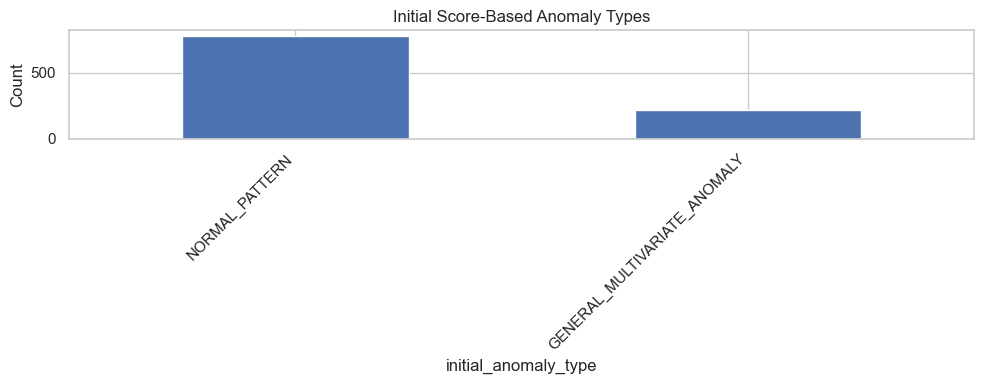

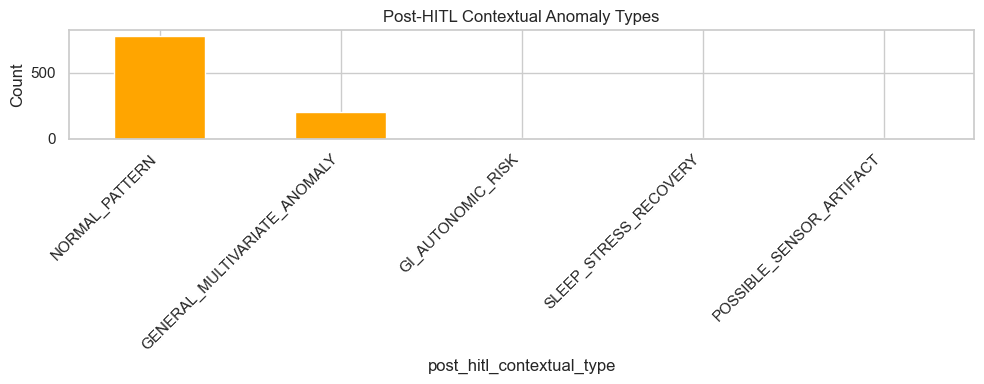

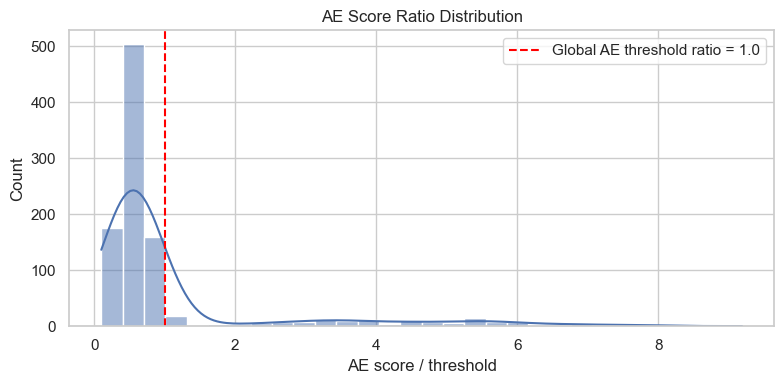

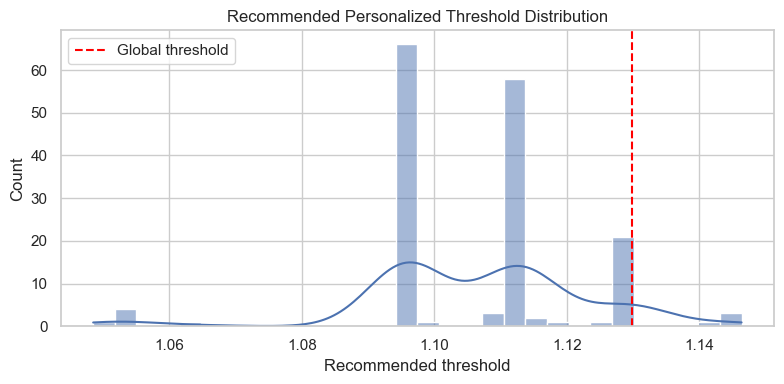

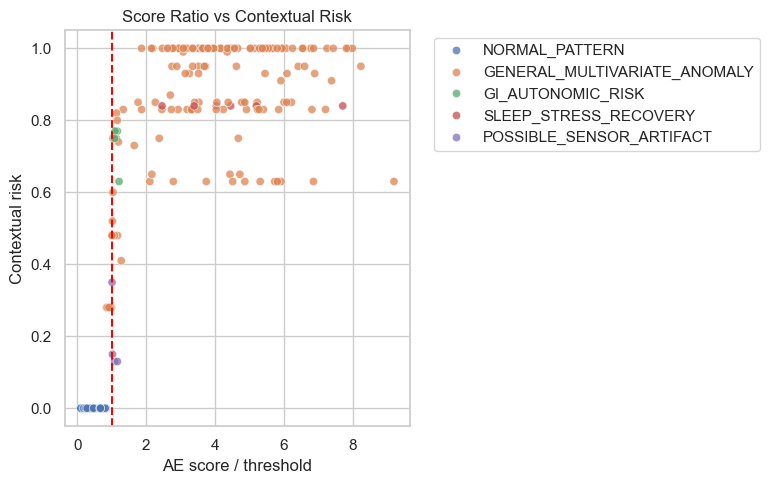

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
two_pass_events_df["initial_anomaly_type"].value_counts().plot(kind="bar")
plt.title("Initial Score-Based Anomaly Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
two_pass_events_df["post_hitl_contextual_type"].value_counts().plot(kind="bar", color="orange")
plt.title("Post-HITL Contextual Anomaly Types")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(two_pass_events_df["score_ratio"].dropna(), bins=30, kde=True)
plt.axvline(1.0, color="red", linestyle="--", label="Global AE threshold ratio = 1.0")
plt.title("AE Score Ratio Distribution")
plt.xlabel("AE score / threshold")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(patient_anomaly_thresholds["recommended_personalized_threshold"], bins=30, kde=True)
plt.axvline(THRESHOLD, color="red", linestyle="--", label="Global threshold")
plt.title("Recommended Personalized Threshold Distribution")
plt.xlabel("Recommended threshold")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=two_pass_events_df,
    x="score_ratio",
    y="contextual_risk",
    hue="post_hitl_contextual_type",
    alpha=0.75
)
plt.axvline(1.0, color="red", linestyle="--")
plt.title("Score Ratio vs Contextual Risk")
plt.xlabel("AE score / threshold")
plt.ylabel("Contextual risk")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [31]:
# Architecture summary for presentation

architecture_summary = pd.DataFrame([
    {
        "Stage": "1. Rule Engine",
        "Layer": "L4 Decision Engine",
        "Purpose": "Catch Severity 3 emergencies before ML/SLM",
        "Output": "Critical alert if emergency thresholds are breached",
        "Safety Note": "Emergency alert is not blocked by ML, MCP, or SLM"
    },
    {
        "Stage": "2. Tiny Autoencoder",
        "Layer": "L4 ML Inference",
        "Purpose": "Detect slow-path multivariate anomaly pattern",
        "Output": "AE score, threshold, score ratio, top abnormal features",
        "Safety Note": "Feasibility prototype, not clinical validation"
    },
    {
        "Stage": "3. Initial Typing",
        "Layer": "L4 Decision Engine",
        "Purpose": "Classify likely anomaly context using score-based evidence",
        "Output": "Initial anomaly type and notification route",
        "Safety Note": "Type is for routing and caregiver prompt context"
    },
    {
        "Stage": "4. HITL Check-in",
        "Layer": "L1/L2 UI + Audit",
        "Purpose": "Ask caregiver structured checkbox questions only when alert-worthy",
        "Output": "Caregiver observations and final action",
        "Safety Note": "Normal rows do not over-prompt caregiver"
    },
    {
        "Stage": "5. Context Fusion",
        "Layer": "L4/L3",
        "Purpose": "Fuse AE evidence with caregiver observations",
        "Output": "Post-HITL contextual type, contextual risk, final notification",
        "Safety Note": "SLM still does not decide anomaly"
    },
    {
        "Stage": "6. Personalization Queue",
        "Layer": "L4/L6",
        "Purpose": "Recommend patient/anomaly threshold refinement",
        "Output": "Recommended personalized threshold and reasons",
        "Safety Note": "Profile update/refinement queue, not live retraining"
    },
    {
        "Stage": "7. SLM Payload",
        "Layer": "L3/L4",
        "Purpose": "Generate caregiver-safe explanation and follow-up questions",
        "Output": "Final structured SLM JSON",
        "Safety Note": "No diagnostic claims"
    }
])

display(architecture_summary)

,Stage,Layer,Purpose,Output,Safety Note
0,1. Rule Engine,L4 Decision Engine,Catch Severity 3 emergencies before ML/SLM,Critical alert if emergency thresholds are breached,"Emergency alert is not blocked by ML, MCP, or SLM"
1,2. Tiny Autoencoder,L4 ML Inference,Detect slow-path multivariate anomaly pattern,"AE score, threshold, score ratio, top abnormal features","Feasibility prototype, not clinical validation"
2,3. Initial Typing,L4 Decision Engine,Classify likely anomaly context using score-based evidence,Initial anomaly type and notification route,Type is for routing and caregiver prompt context
3,4. HITL Check-in,L1/L2 UI + Audit,Ask caregiver structured checkbox questions only when alert-worthy,Caregiver observations and final action,Normal rows do not over-prompt caregiver
4,5. Context Fusion,L4/L3,Fuse AE evidence with caregiver observations,"Post-HITL contextual type, contextual risk, final notification",SLM still does not decide anomaly
5,6. Personalization Queue,L4/L6,Recommend patient/anomaly threshold refinement,Recommended personalized threshold and reasons,"Profile update/refinement queue, not live retraining"
6,7. SLM Payload,L3/L4,Generate caregiver-safe explanation and follow-up questions,Final structured SLM JSON,No diagnostic claims


In [32]:
print("Initial anomaly type counts:")
display(two_pass_events_df["initial_anomaly_type"].value_counts().to_frame("count"))

print("Post-HITL contextual anomaly type counts:")
display(two_pass_events_df["post_hitl_contextual_type"].value_counts().to_frame("count"))

print("Prompt shown counts:")
display(two_pass_events_df["prompt_shown"].value_counts().to_frame("count"))

print("Caregiver final action counts:")
display(two_pass_events_df["caregiver_final_action"].value_counts().to_frame("count"))

print("Initial type x action:")
display(
    pd.crosstab(
        two_pass_events_df["initial_anomaly_type"],
        two_pass_events_df["caregiver_final_action"]
    )
)

print("Post-HITL type x observations:")
if not caregiver_obs_df.empty:
    display(
        pd.crosstab(
            caregiver_obs_df["post_hitl_contextual_type"],
            caregiver_obs_df["observation_label"]
        )
    )

print("Threshold recommendations, alert-worthy only:")
display(
    patient_anomaly_thresholds[
        [
            "patient_id",
            "anomaly_type",
            "base_threshold",
            "recommended_personalized_threshold",
            "threshold_adjustment_pct",
            "history_events",
            "confirm_rate",
            "dismiss_rate",
            "sensor_rate",
            "ratio_mean"
        ]
    ].head(20)
)

display(patient_anomaly_thresholds["anomaly_type"].value_counts().to_frame("threshold_recommendation_count"))

Initial anomaly type counts:


,count
initial_anomaly_type,
NORMAL_PATTERN,781
GENERAL_MULTIVARIATE_ANOMALY,219


Post-HITL contextual anomaly type counts:


,count
post_hitl_contextual_type,
NORMAL_PATTERN,781
GENERAL_MULTIVARIATE_ANOMALY,203
GI_AUTONOMIC_RISK,6
SLEEP_STRESS_RECOVERY,6
POSSIBLE_SENSOR_ARTIFACT,4


Prompt shown counts:


,count
prompt_shown,
False,837
True,163


Caregiver final action counts:


,count
caregiver_final_action,
no_prompt_shown,837
confirm_concern,81
continue_monitoring,64
dismiss,18


Initial type x action:


caregiver_final_action,confirm_concern,continue_monitoring,dismiss,no_prompt_shown
initial_anomaly_type,,,,
GENERAL_MULTIVARIATE_ANOMALY,81,64,18,56
NORMAL_PATTERN,0,0,0,781


Post-HITL type x observations:


observation_label,Eating/drinking less than usual,"More tired, weak, confused, or not acting normal",Not sure,Nothing unusual noticed,Poor sleep,Stress or emotional upset,Vomiting or diarrhea
post_hitl_contextual_type,,,,,,,
GENERAL_MULTIVARIATE_ANOMALY,39,40,33,25,22,32,31
GI_AUTONOMIC_RISK,4,0,0,0,1,1,2
POSSIBLE_SENSOR_ARTIFACT,0,0,1,4,0,0,1
SLEEP_STRESS_RECOVERY,0,0,0,0,6,6,0


Threshold recommendations, alert-worthy only:


,patient_id,anomaly_type,base_threshold,recommended_personalized_threshold,threshold_adjustment_pct,history_events,confirm_rate,dismiss_rate,sensor_rate,ratio_mean
0,PATIENT_0280,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,2.951672
1,PATIENT_0129,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.112900,-0.015000,1,0.0,0.0,0.0,3.186882
2,PATIENT_0185,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,4.166952
3,PATIENT_0212,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,2.746934
4,PATIENT_0382,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.116885,-0.011474,1,0.0,0.0,0.0,1.764903
5,PATIENT_0266,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,5.977645
6,PATIENT_0051,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.118764,-0.009810,1,0.0,0.0,0.0,1.654029
7,PATIENT_0105,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,6.411107
8,PATIENT_0414,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.112900,-0.015000,1,0.0,0.0,0.0,6.596520
9,PATIENT_0317,GENERAL_MULTIVARIATE_ANOMALY,1.129848,1.095952,-0.030000,1,1.0,0.0,0.0,4.656935


,threshold_recommendation_count
anomaly_type,
GENERAL_MULTIVARIATE_ANOMALY,147
GI_AUTONOMIC_RISK,6
SLEEP_STRESS_RECOVERY,6
POSSIBLE_SENSOR_ARTIFACT,4


In [33]:
# Debug generic anomaly rows

generic_debug_rows = []

generic_sample = two_pass_events_df[
    two_pass_events_df["initial_anomaly_type"] == "GENERAL_MULTIVARIATE_ANOMALY"
].head(20)

for idx, row in generic_sample.iterrows():
    tf = top_abnormal_features(row)

    generic_debug_rows.append({
        "event_id": row.get("event_id", idx),
        "patient_id": row.get("patient_id", None),
        "score_ratio": row.get("score_ratio", None),
        "top_features": [x["feature"] for x in tf],
        "top_feature_z": [round(x["z"], 2) for x in tf],
        "fallback_type": feature_family_fallback_type(tf)
    })

generic_debug_df = pd.DataFrame(generic_debug_rows)
display(generic_debug_df)

,event_id,patient_id,score_ratio,top_features,top_feature_z,fallback_type
0,uc2_event_7,PATIENT_0280,2.951672,[],[],GENERAL_MULTIVARIATE_ANOMALY
1,uc2_event_8,PATIENT_0129,3.186882,[],[],GENERAL_MULTIVARIATE_ANOMALY
2,uc2_event_19,PATIENT_0160,0.856018,[],[],GENERAL_MULTIVARIATE_ANOMALY
3,uc2_event_22,PATIENT_0185,4.166952,[],[],GENERAL_MULTIVARIATE_ANOMALY
4,uc2_event_24,PATIENT_0051,0.858644,[],[],GENERAL_MULTIVARIATE_ANOMALY
5,uc2_event_25,PATIENT_0136,0.906516,[],[],GENERAL_MULTIVARIATE_ANOMALY
6,uc2_event_29,PATIENT_0212,2.746934,[],[],GENERAL_MULTIVARIATE_ANOMALY
7,uc2_event_30,PATIENT_0382,1.764903,[],[],GENERAL_MULTIVARIATE_ANOMALY
8,uc2_event_36,PATIENT_0166,0.859836,[],[],GENERAL_MULTIVARIATE_ANOMALY
9,uc2_event_42,PATIENT_0266,5.977645,[],[],GENERAL_MULTIVARIATE_ANOMALY


In [34]:
# DIRECT CONTEXTUAL TYPER

def direct_contextual_type_from_features(row):
    """
    Directly assigns a caregiver-facing context type from feature evidence.

    This is intentionally simple and strong:
      - AE decides anomaly vs normal.
      - This function only labels the context of the anomaly.
      - Labels are for routing/HITL/SLM, not diagnosis.
    """

    ratio = row.get("score_ratio", score_ratio_from_row(row))

    if pd.isna(ratio):
        return "NORMAL_PATTERN", {"NORMAL_PATTERN": 1.0}, ["No AE score ratio available"]

    if ratio < 0.85:
        return "NORMAL_PATTERN", {"NORMAL_PATTERN": 1.0}, [f"AE ratio below normal cutoff: {ratio:.2f}"]

    scores = defaultdict(float)
    evidence = defaultdict(list)

    def add(label, points, reason):
        scores[label] += float(points)
        evidence[label].append(reason)

    def pct(feature):
        return percentile_position(row, feature)

    def z(feature):
        return feature_z(row, feature)

    top_features = top_abnormal_features(row)
    top_names = [x["feature"] for x in top_features]

    # Base anomaly evidence
    if ratio >= 1.0:
        add("GENERAL_MULTIVARIATE_ANOMALY", 1.0, f"AE ratio above threshold: {ratio:.2f}")
    elif ratio >= 0.85:
        add("GENERAL_MULTIVARIATE_ANOMALY", 0.5, f"AE ratio near threshold: {ratio:.2f}")

    # Top-feature family weighting
    for rank, item in enumerate(top_features):
        f = item["feature"]
        abs_z = abs(float(item.get("z", 0)))
        rank_weight = max(0.35, 1.0 - rank * 0.12)
        weight = rank_weight * max(1.0, abs_z)

        if f in ["heart_rate", "activity_level", "steps_count"]:
            add("LOW_ACTIVITY_HIGH_HR", 1.3 * weight, f"{f} is a top abnormal feature")

        if f in ["blood_oxygen", "respiratory_rate"]:
            add("RESPIRATORY_CONCERN", 1.6 * weight, f"{f} is a top abnormal feature")

        if f in ["activity_level", "steps_count", "calories_burned"]:
            add("EXERTION_LIKE_PATTERN", 1.2 * weight, f"{f} is a top abnormal feature")

        if f in ["sleep_quality", "stress_level", "hrv_sdnn"]:
            add("SLEEP_STRESS_RECOVERY", 1.6 * weight, f"{f} is a top abnormal feature")

        if f in ["glucose_level", "body_temperature"]:
            add("METABOLIC_OR_TEMP_CONCERN", 1.7 * weight, f"{f} is a top abnormal feature")

        if f in [
            "blood_pressure_systolic",
            "blood_pressure_diastolic",
            "pulse_pressure",
            "mean_arterial_pressure"
        ]:
            add("METABOLIC_OR_TEMP_CONCERN", 0.9 * weight, f"{f} is a top abnormal feature")
            add("GENERAL_MULTIVARIATE_ANOMALY", 0.5 * weight, f"{f} contributes systemic abnormality")

        if f in ["hour_sin", "hour_cos", "is_sleep_window"]:
            add("POSSIBLE_SENSOR_ARTIFACT", 1.0 * weight, f"{f} time/sleep-window encoding abnormal")

    # Percentile pattern rules

    # Low activity + high HR
    if is_high(row, "heart_rate") and (is_low(row, "activity_level") or is_low(row, "steps_count")):
        add("LOW_ACTIVITY_HIGH_HR", 4.0, "High HR paired with low activity/steps")

    if is_high(row, "heart_rate"):
        add("LOW_ACTIVITY_HIGH_HR", 1.0, "HR high relative to dataset")

    if is_low(row, "activity_level") or is_low(row, "steps_count"):
        add("LOW_ACTIVITY_HIGH_HR", 1.0, "Activity/steps low relative to dataset")

    # Respiratory
    if is_low(row, "blood_oxygen") and is_high(row, "respiratory_rate"):
        add("RESPIRATORY_CONCERN", 4.0, "Low oxygen paired with high respiratory rate")

    if is_low(row, "blood_oxygen"):
        add("RESPIRATORY_CONCERN", 1.8, "Blood oxygen low relative to dataset")

    if is_high(row, "respiratory_rate"):
        add("RESPIRATORY_CONCERN", 1.5, "Respiratory rate high relative to dataset")

    # Exertion
    if is_high(row, "heart_rate") and (
        is_high(row, "activity_level") or is_high(row, "steps_count") or is_high(row, "calories_burned")
    ):
        add("EXERTION_LIKE_PATTERN", 4.0, "High HR paired with high activity/steps/calories")

    if is_high(row, "activity_level") or is_high(row, "steps_count") or is_high(row, "calories_burned"):
        add("EXERTION_LIKE_PATTERN", 1.5, "Activity/steps/calories high relative to dataset")

    # Sleep/stress
    if is_low(row, "sleep_quality") and is_high(row, "stress_level"):
        add("SLEEP_STRESS_RECOVERY", 4.0, "Low sleep quality paired with high stress")

    if is_low(row, "sleep_quality"):
        add("SLEEP_STRESS_RECOVERY", 1.8, "Sleep quality low relative to dataset")

    if is_high(row, "stress_level"):
        add("SLEEP_STRESS_RECOVERY", 1.8, "Stress high relative to dataset")

    if is_low(row, "hrv_sdnn"):
        add("SLEEP_STRESS_RECOVERY", 1.2, "HRV low relative to dataset")

    # Metabolic/temp
    if is_high(row, "glucose_level") or is_low(row, "glucose_level"):
        add("METABOLIC_OR_TEMP_CONCERN", 2.0, "Glucose unusual relative to dataset")

    if is_high(row, "body_temperature") or is_low(row, "body_temperature"):
        add("METABOLIC_OR_TEMP_CONCERN", 2.0, "Body temperature unusual relative to dataset")

    # Sensor artifact should be conservative
    if len(top_features) <= 1 and ratio < 1.25:
        add("POSSIBLE_SENSOR_ARTIFACT", 2.0, "Weak anomaly with only one prominent abnormal feature")

    # Choose specific winner
    specific_types = [
        "LOW_ACTIVITY_HIGH_HR",
        "RESPIRATORY_CONCERN",
        "EXERTION_LIKE_PATTERN",
        "SLEEP_STRESS_RECOVERY",
        "METABOLIC_OR_TEMP_CONCERN",
        "POSSIBLE_SENSOR_ARTIFACT"
    ]

    specific_scores = {t: scores.get(t, 0.0) for t in specific_types}
    best_specific = max(specific_scores, key=specific_scores.get)
    best_specific_score = specific_scores[best_specific]

    # Strong direct rule:
    # If AE says anomaly and any specific type has evidence, use it.
    if ratio >= 1.0 and best_specific_score > 0:
        primary = best_specific

    # Near threshold needs at least moderate evidence.
    elif 0.85 <= ratio < 1.0 and best_specific_score >= 1.5:
        primary = best_specific

    else:
        primary = "GENERAL_MULTIVARIATE_ANOMALY"

    return primary, dict(scores), dict(evidence)

In [35]:
# POST-PROCESS: Replace generic initial labels with direct contextual labels

two_pass_events_df = two_pass_events_df.copy()

new_initial_types = []
new_type_scores = []
new_type_evidence = []

changed_count = 0

for idx, row in two_pass_events_df.iterrows():

    current_type = row["initial_anomaly_type"]
    ratio = row.get("score_ratio", np.nan)

    # Keep normal rows normal.
    if current_type == "NORMAL_PATTERN" or (pd.notna(ratio) and ratio < 0.85):
        new_initial_types.append(current_type)
        new_type_scores.append(row.get("initial_type_scores", {}))
        new_type_evidence.append({})
        continue

    # Re-label generic anomalies only.
    if current_type == "GENERAL_MULTIVARIATE_ANOMALY":
        contextual_type, scores, evidence = direct_contextual_type_from_features(row)

        # Only replace if the direct function found something more specific.
        if contextual_type != "GENERAL_MULTIVARIATE_ANOMALY":
            new_initial_types.append(contextual_type)
            new_type_scores.append(scores)
            new_type_evidence.append(evidence)
            changed_count += 1
        else:
            new_initial_types.append(current_type)
            new_type_scores.append(row.get("initial_type_scores", {}))
            new_type_evidence.append(evidence)

    else:
        new_initial_types.append(current_type)
        new_type_scores.append(row.get("initial_type_scores", {}))
        new_type_evidence.append({})

two_pass_events_df["initial_anomaly_type_original"] = two_pass_events_df["initial_anomaly_type"]
two_pass_events_df["initial_anomaly_type"] = new_initial_types
two_pass_events_df["initial_type_scores_direct"] = new_type_scores
two_pass_events_df["initial_type_evidence_direct"] = new_type_evidence

print(f"Changed {changed_count} generic initial labels to specific contextual labels.")

print("Updated initial anomaly type counts:")
display(two_pass_events_df["initial_anomaly_type"].value_counts().to_frame("count"))

print("Original vs updated initial type:")
display(
    pd.crosstab(
        two_pass_events_df["initial_anomaly_type_original"],
        two_pass_events_df["initial_anomaly_type"]
    )
)

Changed 75 generic initial labels to specific contextual labels.
Updated initial anomaly type counts:


,count
initial_anomaly_type,
NORMAL_PATTERN,781
GENERAL_MULTIVARIATE_ANOMALY,144
POSSIBLE_SENSOR_ARTIFACT,75


Original vs updated initial type:


initial_anomaly_type,GENERAL_MULTIVARIATE_ANOMALY,NORMAL_PATTERN,POSSIBLE_SENSOR_ARTIFACT
initial_anomaly_type_original,,,
GENERAL_MULTIVARIATE_ANOMALY,144,0,75
NORMAL_PATTERN,0,781,0


In [36]:
# REFRESH HITL + POST-HITL AFTER DIRECT INITIAL RELABELING

refreshed_rows = []
new_caregiver_obs_records = []
new_final_slm_payloads = []

np.random.seed(42)

for idx, row in two_pass_events_df.iterrows():

    row = row.copy()

    patient_id = row.get("patient_id", f"patient_{idx}")
    caregiver_id = row.get("caregiver_id", f"caregiver_for_{patient_id}")
    event_id = row.get("event_id", f"uc2_event_{idx}")

    initial_type = row["initial_anomaly_type"]

    emergency_result = {
        "is_emergency": bool(row.get("is_emergency", False)),
        "severity": 3 if bool(row.get("is_emergency", False)) else 0,
        "reasons": row.get("emergency_reasons", [])
    }

    # Re-route using updated type.
    initial_route = route_initial_notification(row, initial_type, emergency_result)

    # Re-simulate caregiver feedback using updated type.
    caregiver_feedback = simulate_caregiver_feedback(row, initial_type, initial_route)

    # Build classifier_result-ish object for refinement.
    classifier_result = {
        "type_scores": row.get("initial_type_scores_direct", {}),
        "type_evidence": row.get("initial_type_evidence_direct", {})
    }

    refinement = refine_anomaly_type_after_hitl(
        initial_type=initial_type,
        row=row,
        caregiver_observations=caregiver_feedback["caregiver_observations"],
        classifier_result=classifier_result
    )

    post_hitl_type = refinement["post_hitl_contextual_type"]

    contextual = compute_contextual_confidence(
        row=row,
        initial_type=initial_type,
        post_hitl_type=post_hitl_type,
        caregiver_feedback=caregiver_feedback,
        patient_history={}
    )

    # Update row fields
    row["initial_notification_type"] = initial_route["notification_type"]
    row["initial_severity"] = initial_route["severity"]
    row["initial_should_prompt_caregiver"] = initial_route["should_prompt_caregiver"]
    row["initial_route_reason"] = initial_route["reason"]

    row["caregiver_observations"] = caregiver_feedback["caregiver_observations"]
    row["caregiver_observation_labels"] = caregiver_feedback["caregiver_observation_labels"]
    row["caregiver_final_action"] = caregiver_feedback["caregiver_final_action"]
    row["prompt_shown"] = caregiver_feedback["prompt_shown"]

    row["post_hitl_contextual_type"] = post_hitl_type
    row["post_hitl_type_scores"] = refinement["post_hitl_type_scores"]
    row["refinement_reason"] = refinement["refinement_reason"]

    row["contextual_risk"] = contextual["contextual_risk"]
    row["final_severity"] = contextual["final_severity"]
    row["final_notification_type"] = contextual["final_notification_type"]

    refreshed_rows.append(row)

    for obs_code in caregiver_feedback["caregiver_observations"]:
        new_caregiver_obs_records.append({
            "event_id": event_id,
            "patient_id": patient_id,
            "caregiver_id": caregiver_id,
            "initial_anomaly_type": initial_type,
            "post_hitl_contextual_type": post_hitl_type,
            "observation_code": obs_code,
            "observation_label": CAREGIVER_OPTIONS.get(obs_code, obs_code),
            "caregiver_final_action": caregiver_feedback["caregiver_final_action"],
            "prompt_shown": caregiver_feedback["prompt_shown"]
        })

    # Refresh final SLM payload
    ae_score = row.get("ae_score", np.nan)
    ratio = row.get("score_ratio", np.nan)

    final_payload = {
        "event_name": UC2_EVENT_NAME,
        "event_id": str(event_id),
        "patient_id": patient_id,
        "caregiver_id": caregiver_id,
        "model_name": "tiny_uc2_autoencoder",
        "model_version": MODEL_VERSION if "MODEL_VERSION" in globals() else "tiny_ae_uc2_v0.1.0",
        "ae_evidence": {
            "ae_score": None if pd.isna(ae_score) else float(ae_score),
            "threshold": float(THRESHOLD),
            "score_ratio": None if pd.isna(ratio) else float(ratio),
            "ae_anomaly_flag": bool(row.get("ae_anomaly_flag", False)),
            "top_abnormal_features": top_abnormal_features(row)
        },
        "initial_anomaly_type": initial_type,
        "post_hitl_contextual_type": post_hitl_type,
        "caregiver_feedback": caregiver_feedback,
        "contextual_risk": contextual["contextual_risk"],
        "final_severity": contextual["final_severity"],
        "final_notification_type": contextual["final_notification_type"],
        "confidence_reasons": contextual["confidence_reasons"],
        "slm_instruction": (
            "Generate a caregiver-safe explanation and follow-up questions. "
            "Do not diagnose. Do not claim the SLM detected the anomaly. "
            "Use ML evidence and caregiver observations only as context."
        )
    }

    new_final_slm_payloads.append(final_payload)

two_pass_events_df = pd.DataFrame(refreshed_rows)
caregiver_obs_df = pd.DataFrame(new_caregiver_obs_records)
final_slm_payloads = new_final_slm_payloads

print("Refreshed HITL and final SLM payloads using updated initial anomaly types.")

print("Updated initial anomaly type counts:")
display(two_pass_events_df["initial_anomaly_type"].value_counts().to_frame("count"))

print("Updated post-HITL type counts:")
display(two_pass_events_df["post_hitl_contextual_type"].value_counts().to_frame("count"))

print("Updated prompt shown counts:")
display(two_pass_events_df["prompt_shown"].value_counts().to_frame("count"))

print("Updated caregiver action counts:")
display(two_pass_events_df["caregiver_final_action"].value_counts().to_frame("count"))

print("Updated initial type x action:")
display(
    pd.crosstab(
        two_pass_events_df["initial_anomaly_type"],
        two_pass_events_df["caregiver_final_action"]
    )
)

print("Updated post-HITL type x observations:")
if not caregiver_obs_df.empty:
    display(
        pd.crosstab(
            caregiver_obs_df["post_hitl_contextual_type"],
            caregiver_obs_df["observation_label"]
        )
    )

Refreshed HITL and final SLM payloads using updated initial anomaly types.
Updated initial anomaly type counts:


,count
initial_anomaly_type,
NORMAL_PATTERN,781
GENERAL_MULTIVARIATE_ANOMALY,144
POSSIBLE_SENSOR_ARTIFACT,75


Updated post-HITL type counts:


,count
post_hitl_contextual_type,
NORMAL_PATTERN,781
GENERAL_MULTIVARIATE_ANOMALY,139
POSSIBLE_SENSOR_ARTIFACT,75
SLEEP_STRESS_RECOVERY,5


Updated prompt shown counts:


,count
prompt_shown,
False,856
True,144


Updated caregiver action counts:


,count
caregiver_final_action,
no_prompt_shown,856
confirm_concern,69
continue_monitoring,57
dismiss,18


Updated initial type x action:


caregiver_final_action,confirm_concern,continue_monitoring,dismiss,no_prompt_shown
initial_anomaly_type,,,,
GENERAL_MULTIVARIATE_ANOMALY,69,57,18,0
NORMAL_PATTERN,0,0,0,781
POSSIBLE_SENSOR_ARTIFACT,0,0,0,75


Updated post-HITL type x observations:


observation_label,Eating/drinking less than usual,"More tired, weak, confused, or not acting normal",Not sure,Nothing unusual noticed,Poor sleep,Stress or emotional upset,Vomiting or diarrhea
post_hitl_contextual_type,,,,,,,
GENERAL_MULTIVARIATE_ANOMALY,38,33,31,27,20,31,26
SLEEP_STRESS_RECOVERY,0,0,0,0,5,5,0


In [37]:
# DIRECT CONTEXTUAL TYPER

def direct_contextual_type_from_features(row):
    """
    Directly assigns a caregiver-facing context type from feature evidence.

    This is intentionally simple and strong:
      - AE decides anomaly vs normal.
      - This function only labels the context of the anomaly.
      - Labels are for routing/HITL/SLM, not diagnosis.
    """

    ratio = row.get("score_ratio", score_ratio_from_row(row))

    if pd.isna(ratio):
        return "NORMAL_PATTERN", {"NORMAL_PATTERN": 1.0}, ["No AE score ratio available"]

    if ratio < 0.85:
        return "NORMAL_PATTERN", {"NORMAL_PATTERN": 1.0}, [f"AE ratio below normal cutoff: {ratio:.2f}"]

    scores = defaultdict(float)
    evidence = defaultdict(list)

    def add(label, points, reason):
        scores[label] += float(points)
        evidence[label].append(reason)

    def pct(feature):
        return percentile_position(row, feature)

    def z(feature):
        return feature_z(row, feature)

    top_features = top_abnormal_features(row)
    top_names = [x["feature"] for x in top_features]

    # Base anomaly evidence
    if ratio >= 1.0:
        add("GENERAL_MULTIVARIATE_ANOMALY", 1.0, f"AE ratio above threshold: {ratio:.2f}")
    elif ratio >= 0.85:
        add("GENERAL_MULTIVARIATE_ANOMALY", 0.5, f"AE ratio near threshold: {ratio:.2f}")

    # Top-feature family weighting
    for rank, item in enumerate(top_features):
        f = item["feature"]
        abs_z = abs(float(item.get("z", 0)))
        rank_weight = max(0.35, 1.0 - rank * 0.12)
        weight = rank_weight * max(1.0, abs_z)

        if f in ["heart_rate", "activity_level", "steps_count"]:
            add("LOW_ACTIVITY_HIGH_HR", 1.3 * weight, f"{f} is a top abnormal feature")

        if f in ["blood_oxygen", "respiratory_rate"]:
            add("RESPIRATORY_CONCERN", 1.6 * weight, f"{f} is a top abnormal feature")

        if f in ["activity_level", "steps_count", "calories_burned"]:
            add("EXERTION_LIKE_PATTERN", 1.2 * weight, f"{f} is a top abnormal feature")

        if f in ["sleep_quality", "stress_level", "hrv_sdnn"]:
            add("SLEEP_STRESS_RECOVERY", 1.6 * weight, f"{f} is a top abnormal feature")

        if f in ["glucose_level", "body_temperature"]:
            add("METABOLIC_OR_TEMP_CONCERN", 1.7 * weight, f"{f} is a top abnormal feature")

        if f in [
            "blood_pressure_systolic",
            "blood_pressure_diastolic",
            "pulse_pressure",
            "mean_arterial_pressure"
        ]:
            add("METABOLIC_OR_TEMP_CONCERN", 0.9 * weight, f"{f} is a top abnormal feature")
            add("GENERAL_MULTIVARIATE_ANOMALY", 0.5 * weight, f"{f} contributes systemic abnormality")

        if f in ["hour_sin", "hour_cos", "is_sleep_window"]:
            add("POSSIBLE_SENSOR_ARTIFACT", 1.0 * weight, f"{f} time/sleep-window encoding abnormal")

    # Percentile pattern rules

    # Low activity + high HR
    if is_high(row, "heart_rate") and (is_low(row, "activity_level") or is_low(row, "steps_count")):
        add("LOW_ACTIVITY_HIGH_HR", 4.0, "High HR paired with low activity/steps")

    if is_high(row, "heart_rate"):
        add("LOW_ACTIVITY_HIGH_HR", 1.0, "HR high relative to dataset")

    if is_low(row, "activity_level") or is_low(row, "steps_count"):
        add("LOW_ACTIVITY_HIGH_HR", 1.0, "Activity/steps low relative to dataset")

    # Respiratory
    if is_low(row, "blood_oxygen") and is_high(row, "respiratory_rate"):
        add("RESPIRATORY_CONCERN", 4.0, "Low oxygen paired with high respiratory rate")

    if is_low(row, "blood_oxygen"):
        add("RESPIRATORY_CONCERN", 1.8, "Blood oxygen low relative to dataset")

    if is_high(row, "respiratory_rate"):
        add("RESPIRATORY_CONCERN", 1.5, "Respiratory rate high relative to dataset")

    # Exertion
    if is_high(row, "heart_rate") and (
        is_high(row, "activity_level") or is_high(row, "steps_count") or is_high(row, "calories_burned")
    ):
        add("EXERTION_LIKE_PATTERN", 4.0, "High HR paired with high activity/steps/calories")

    if is_high(row, "activity_level") or is_high(row, "steps_count") or is_high(row, "calories_burned"):
        add("EXERTION_LIKE_PATTERN", 1.5, "Activity/steps/calories high relative to dataset")

    # Sleep/stress
    if is_low(row, "sleep_quality") and is_high(row, "stress_level"):
        add("SLEEP_STRESS_RECOVERY", 4.0, "Low sleep quality paired with high stress")

    if is_low(row, "sleep_quality"):
        add("SLEEP_STRESS_RECOVERY", 1.8, "Sleep quality low relative to dataset")

    if is_high(row, "stress_level"):
        add("SLEEP_STRESS_RECOVERY", 1.8, "Stress high relative to dataset")

    if is_low(row, "hrv_sdnn"):
        add("SLEEP_STRESS_RECOVERY", 1.2, "HRV low relative to dataset")

    # Metabolic/temp
    if is_high(row, "glucose_level") or is_low(row, "glucose_level"):
        add("METABOLIC_OR_TEMP_CONCERN", 2.0, "Glucose unusual relative to dataset")

    if is_high(row, "body_temperature") or is_low(row, "body_temperature"):
        add("METABOLIC_OR_TEMP_CONCERN", 2.0, "Body temperature unusual relative to dataset")

    # Sensor artifact should be conservative
    if len(top_features) <= 1 and ratio < 1.25:
        add("POSSIBLE_SENSOR_ARTIFACT", 2.0, "Weak anomaly with only one prominent abnormal feature")

    # Choose specific winner
    specific_types = [
        "LOW_ACTIVITY_HIGH_HR",
        "RESPIRATORY_CONCERN",
        "EXERTION_LIKE_PATTERN",
        "SLEEP_STRESS_RECOVERY",
        "METABOLIC_OR_TEMP_CONCERN",
        "POSSIBLE_SENSOR_ARTIFACT"
    ]

    specific_scores = {t: scores.get(t, 0.0) for t in specific_types}
    best_specific = max(specific_scores, key=specific_scores.get)
    best_specific_score = specific_scores[best_specific]

    # Strong direct rule:
    # If AE says anomaly and any specific type has evidence, use it.
    if ratio >= 1.0 and best_specific_score > 0:
        primary = best_specific

    # Near threshold needs at least moderate evidence.
    elif 0.85 <= ratio < 1.0 and best_specific_score >= 1.5:
        primary = best_specific

    else:
        primary = "GENERAL_MULTIVARIATE_ANOMALY"

    return primary, dict(scores), dict(evidence)

In [38]:
# POST-PROCESS: Replace generic initial labels with direct contextual labels

two_pass_events_df = two_pass_events_df.copy()

new_initial_types = []
new_type_scores = []
new_type_evidence = []

changed_count = 0

for idx, row in two_pass_events_df.iterrows():

    current_type = row["initial_anomaly_type"]
    ratio = row.get("score_ratio", np.nan)

    # Keep normal rows normal.
    if current_type == "NORMAL_PATTERN" or (pd.notna(ratio) and ratio < 0.85):
        new_initial_types.append(current_type)
        new_type_scores.append(row.get("initial_type_scores", {}))
        new_type_evidence.append({})
        continue

    # Re-label generic anomalies only.
    if current_type == "GENERAL_MULTIVARIATE_ANOMALY":
        contextual_type, scores, evidence = direct_contextual_type_from_features(row)

        # Only replace if the direct function found something more specific.
        if contextual_type != "GENERAL_MULTIVARIATE_ANOMALY":
            new_initial_types.append(contextual_type)
            new_type_scores.append(scores)
            new_type_evidence.append(evidence)
            changed_count += 1
        else:
            new_initial_types.append(current_type)
            new_type_scores.append(row.get("initial_type_scores", {}))
            new_type_evidence.append(evidence)

    else:
        new_initial_types.append(current_type)
        new_type_scores.append(row.get("initial_type_scores", {}))
        new_type_evidence.append({})

two_pass_events_df["initial_anomaly_type_original"] = two_pass_events_df["initial_anomaly_type"]
two_pass_events_df["initial_anomaly_type"] = new_initial_types
two_pass_events_df["initial_type_scores_direct"] = new_type_scores
two_pass_events_df["initial_type_evidence_direct"] = new_type_evidence

print(f"Changed {changed_count} generic initial labels to specific contextual labels.")

print("Updated initial anomaly type counts:")
display(two_pass_events_df["initial_anomaly_type"].value_counts().to_frame("count"))

print("Original vs updated initial type:")
display(
    pd.crosstab(
        two_pass_events_df["initial_anomaly_type_original"],
        two_pass_events_df["initial_anomaly_type"]
    )
)

Changed 0 generic initial labels to specific contextual labels.
Updated initial anomaly type counts:


,count
initial_anomaly_type,
NORMAL_PATTERN,781
GENERAL_MULTIVARIATE_ANOMALY,144
POSSIBLE_SENSOR_ARTIFACT,75


Original vs updated initial type:


initial_anomaly_type,GENERAL_MULTIVARIATE_ANOMALY,NORMAL_PATTERN,POSSIBLE_SENSOR_ARTIFACT
initial_anomaly_type_original,,,
GENERAL_MULTIVARIATE_ANOMALY,144,0,0
NORMAL_PATTERN,0,781,0
POSSIBLE_SENSOR_ARTIFACT,0,0,75


In [39]:
# REFRESH HITL + POST-HITL AFTER DIRECT INITIAL RELABELING

refreshed_rows = []
new_caregiver_obs_records = []
new_final_slm_payloads = []

np.random.seed(42)

for idx, row in two_pass_events_df.iterrows():

    row = row.copy()

    patient_id = row.get("patient_id", f"patient_{idx}")
    caregiver_id = row.get("caregiver_id", f"caregiver_for_{patient_id}")
    event_id = row.get("event_id", f"uc2_event_{idx}")

    initial_type = row["initial_anomaly_type"]

    emergency_result = {
        "is_emergency": bool(row.get("is_emergency", False)),
        "severity": 3 if bool(row.get("is_emergency", False)) else 0,
        "reasons": row.get("emergency_reasons", [])
    }

    # Re-route using updated type.
    initial_route = route_initial_notification(row, initial_type, emergency_result)

    # Re-simulate caregiver feedback using updated type.
    caregiver_feedback = simulate_caregiver_feedback(row, initial_type, initial_route)

    # Build classifier_result-ish object for refinement.
    classifier_result = {
        "type_scores": row.get("initial_type_scores_direct", {}),
        "type_evidence": row.get("initial_type_evidence_direct", {})
    }

    refinement = refine_anomaly_type_after_hitl(
        initial_type=initial_type,
        row=row,
        caregiver_observations=caregiver_feedback["caregiver_observations"],
        classifier_result=classifier_result
    )

    post_hitl_type = refinement["post_hitl_contextual_type"]

    contextual = compute_contextual_confidence(
        row=row,
        initial_type=initial_type,
        post_hitl_type=post_hitl_type,
        caregiver_feedback=caregiver_feedback,
        patient_history={}
    )

    # Update row fields
    row["initial_notification_type"] = initial_route["notification_type"]
    row["initial_severity"] = initial_route["severity"]
    row["initial_should_prompt_caregiver"] = initial_route["should_prompt_caregiver"]
    row["initial_route_reason"] = initial_route["reason"]

    row["caregiver_observations"] = caregiver_feedback["caregiver_observations"]
    row["caregiver_observation_labels"] = caregiver_feedback["caregiver_observation_labels"]
    row["caregiver_final_action"] = caregiver_feedback["caregiver_final_action"]
    row["prompt_shown"] = caregiver_feedback["prompt_shown"]

    row["post_hitl_contextual_type"] = post_hitl_type
    row["post_hitl_type_scores"] = refinement["post_hitl_type_scores"]
    row["refinement_reason"] = refinement["refinement_reason"]

    row["contextual_risk"] = contextual["contextual_risk"]
    row["final_severity"] = contextual["final_severity"]
    row["final_notification_type"] = contextual["final_notification_type"]

    refreshed_rows.append(row)

    for obs_code in caregiver_feedback["caregiver_observations"]:
        new_caregiver_obs_records.append({
            "event_id": event_id,
            "patient_id": patient_id,
            "caregiver_id": caregiver_id,
            "initial_anomaly_type": initial_type,
            "post_hitl_contextual_type": post_hitl_type,
            "observation_code": obs_code,
            "observation_label": CAREGIVER_OPTIONS.get(obs_code, obs_code),
            "caregiver_final_action": caregiver_feedback["caregiver_final_action"],
            "prompt_shown": caregiver_feedback["prompt_shown"]
        })

    # Refresh final SLM payload
    ae_score = row.get("ae_score", np.nan)
    ratio = row.get("score_ratio", np.nan)

    final_payload = {
        "event_name": UC2_EVENT_NAME,
        "event_id": str(event_id),
        "patient_id": patient_id,
        "caregiver_id": caregiver_id,
        "model_name": "tiny_uc2_autoencoder",
        "model_version": MODEL_VERSION if "MODEL_VERSION" in globals() else "tiny_ae_uc2_v0.1.0",
        "ae_evidence": {
            "ae_score": None if pd.isna(ae_score) else float(ae_score),
            "threshold": float(THRESHOLD),
            "score_ratio": None if pd.isna(ratio) else float(ratio),
            "ae_anomaly_flag": bool(row.get("ae_anomaly_flag", False)),
            "top_abnormal_features": top_abnormal_features(row)
        },
        "initial_anomaly_type": initial_type,
        "post_hitl_contextual_type": post_hitl_type,
        "caregiver_feedback": caregiver_feedback,
        "contextual_risk": contextual["contextual_risk"],
        "final_severity": contextual["final_severity"],
        "final_notification_type": contextual["final_notification_type"],
        "confidence_reasons": contextual["confidence_reasons"],
        "slm_instruction": (
            "Generate a caregiver-safe explanation and follow-up questions. "
            "Do not diagnose. Do not claim the SLM detected the anomaly. "
            "Use ML evidence and caregiver observations only as context."
        )
    }

    new_final_slm_payloads.append(final_payload)

two_pass_events_df = pd.DataFrame(refreshed_rows)
caregiver_obs_df = pd.DataFrame(new_caregiver_obs_records)
final_slm_payloads = new_final_slm_payloads

print("Refreshed HITL and final SLM payloads using updated initial anomaly types.")

print("Updated initial anomaly type counts:")
display(two_pass_events_df["initial_anomaly_type"].value_counts().to_frame("count"))

print("Updated post-HITL type counts:")
display(two_pass_events_df["post_hitl_contextual_type"].value_counts().to_frame("count"))

print("Updated prompt shown counts:")
display(two_pass_events_df["prompt_shown"].value_counts().to_frame("count"))

print("Updated caregiver action counts:")
display(two_pass_events_df["caregiver_final_action"].value_counts().to_frame("count"))

print("Updated initial type x action:")
display(
    pd.crosstab(
        two_pass_events_df["initial_anomaly_type"],
        two_pass_events_df["caregiver_final_action"]
    )
)

print("Updated post-HITL type x observations:")
if not caregiver_obs_df.empty:
    display(
        pd.crosstab(
            caregiver_obs_df["post_hitl_contextual_type"],
            caregiver_obs_df["observation_label"]
        )
    )

Refreshed HITL and final SLM payloads using updated initial anomaly types.
Updated initial anomaly type counts:


,count
initial_anomaly_type,
NORMAL_PATTERN,781
GENERAL_MULTIVARIATE_ANOMALY,144
POSSIBLE_SENSOR_ARTIFACT,75


Updated post-HITL type counts:


,count
post_hitl_contextual_type,
NORMAL_PATTERN,781
GENERAL_MULTIVARIATE_ANOMALY,139
POSSIBLE_SENSOR_ARTIFACT,75
SLEEP_STRESS_RECOVERY,5


Updated prompt shown counts:


,count
prompt_shown,
False,856
True,144


Updated caregiver action counts:


,count
caregiver_final_action,
no_prompt_shown,856
confirm_concern,69
continue_monitoring,57
dismiss,18


Updated initial type x action:


caregiver_final_action,confirm_concern,continue_monitoring,dismiss,no_prompt_shown
initial_anomaly_type,,,,
GENERAL_MULTIVARIATE_ANOMALY,69,57,18,0
NORMAL_PATTERN,0,0,0,781
POSSIBLE_SENSOR_ARTIFACT,0,0,0,75


Updated post-HITL type x observations:


observation_label,Eating/drinking less than usual,"More tired, weak, confused, or not acting normal",Not sure,Nothing unusual noticed,Poor sleep,Stress or emotional upset,Vomiting or diarrhea
post_hitl_contextual_type,,,,,,,
GENERAL_MULTIVARIATE_ANOMALY,38,33,31,27,20,31,26
SLEEP_STRESS_RECOVERY,0,0,0,0,5,5,0


In [40]:
import pandas as pd
import numpy as np
from collections import Counter

print("two_pass_events_df shape:", two_pass_events_df.shape)

print("\nColumns:")
print(two_pass_events_df.columns.tolist())

print("\nscore_ratio summary:")
display(two_pass_events_df["score_ratio"].describe())

anom_rows = two_pass_events_df[two_pass_events_df["score_ratio"] >= 1.0].copy()
print("\nRows with score_ratio >= 1.0:", anom_rows.shape)

print("\nInitial anomaly type counts for score_ratio >= 1.0:")
if len(anom_rows) > 0 and "initial_anomaly_type" in anom_rows.columns:
    display(anom_rows["initial_anomaly_type"].value_counts(dropna=False))

print("\nPost-HITL type counts for score_ratio >= 1.0:")
if len(anom_rows) > 0 and "post_hitl_contextual_type" in anom_rows.columns:
    display(anom_rows["post_hitl_contextual_type"].value_counts(dropna=False))

two_pass_events_df shape: (1000, 49)

Columns:
['patient_id', 'device_id', 'timestamp', 'health_event', 'event_label', 'pipeline_path', 'emergency', 'severity', 'emergency_reasons', 'ml_locked_initially', 'ml_ran', 'reconstruction_error', 'global_threshold', 'personalized_threshold', 'anomaly_detected_global', 'anomaly_detected_personalized', 'caregiver_action', 'caregiver_confirmed', 'caregiver_observations', 'slm_refinement_queued', 'model_version', 'input_hash', 'top_features', 'event_id', 'caregiver_id', 'ae_score', 'score_ratio', 'ae_anomaly_flag', 'is_emergency', 'initial_anomaly_type', 'initial_type_scores', 'initial_notification_type', 'initial_severity', 'initial_should_prompt_caregiver', 'initial_route_reason', 'caregiver_observation_labels', 'caregiver_final_action', 'prompt_shown', 'post_hitl_contextual_type', 'post_hitl_type_scores', 'refinement_reason', 'contextual_risk', 'final_severity', 'final_notification_type', 'recommended_personalized_threshold', 'threshold_adjustm

count    1000.000000
mean        1.127663
std         1.520002
min         0.098555
25%         0.448596
50%         0.583633
75%         0.800466
max         9.188826
Name: score_ratio, dtype: float64


Rows with score_ratio >= 1.0: (163, 49)

Initial anomaly type counts for score_ratio >= 1.0:


initial_anomaly_type
GENERAL_MULTIVARIATE_ANOMALY    144
POSSIBLE_SENSOR_ARTIFACT         19
Name: count, dtype: int64


Post-HITL type counts for score_ratio >= 1.0:


post_hitl_contextual_type
GENERAL_MULTIVARIATE_ANOMALY    139
POSSIBLE_SENSOR_ARTIFACT         19
SLEEP_STRESS_RECOVERY             5
Name: count, dtype: int64

In [41]:
print("FEATURE_ORDER length:", len(FEATURE_ORDER))
print("FEATURE_ORDER:")
print(FEATURE_ORDER)

print("\nGLOBAL_FEATURE_STATS type:", type(GLOBAL_FEATURE_STATS))

if isinstance(GLOBAL_FEATURE_STATS, dict):
    print("\nGLOBAL_FEATURE_STATS keys sample:")
    print(list(GLOBAL_FEATURE_STATS.keys())[:20])
else:
    print("\nGLOBAL_FEATURE_STATS is not a dict. Value:")
    print(GLOBAL_FEATURE_STATS)

row_cols = set(two_pass_events_df.columns)
feature_set = set(FEATURE_ORDER)

print("\nFeatures present as columns in two_pass_events_df:")
present_features = [f for f in FEATURE_ORDER if f in row_cols]
missing_features = [f for f in FEATURE_ORDER if f not in row_cols]

print("present:", present_features)
print("missing:", missing_features)

if isinstance(GLOBAL_FEATURE_STATS, dict):
    stats_keys = set(GLOBAL_FEATURE_STATS.keys())
    print("\nFeatures with stats:")
    print([f for f in FEATURE_ORDER if f in stats_keys])

    print("\nFeatures missing stats:")
    print([f for f in FEATURE_ORDER if f not in stats_keys])

FEATURE_ORDER length: 18
FEATURE_ORDER:
['heart_rate', 'blood_oxygen', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'glucose_level', 'body_temperature', 'respiratory_rate', 'activity_level', 'sleep_quality', 'stress_level', 'hrv_sdnn', 'steps_count', 'calories_burned', 'pulse_pressure', 'mean_arterial_pressure', 'hour_sin', 'hour_cos', 'is_sleep_window']

GLOBAL_FEATURE_STATS type: <class 'dict'>

GLOBAL_FEATURE_STATS keys sample:
[]

Features present as columns in two_pass_events_df:
present: []
missing: ['heart_rate', 'blood_oxygen', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'glucose_level', 'body_temperature', 'respiratory_rate', 'activity_level', 'sleep_quality', 'stress_level', 'hrv_sdnn', 'steps_count', 'calories_burned', 'pulse_pressure', 'mean_arterial_pressure', 'hour_sin', 'hour_cos', 'is_sleep_window']

Features with stats:
[]

Features missing stats:
['heart_rate', 'blood_oxygen', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'glucose_level',

In [42]:
CLINICAL_FEATURES = [
    "heart_rate",
    "blood_oxygen",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "glucose_level",
    "body_temperature",
    "respiratory_rate",
    "activity_level",
    "sleep_quality",
    "stress_level",
    "hrv_sdnn",
    "steps_count",
    "calories_burned",
    "pulse_pressure",
    "mean_arterial_pressure",
]

FEATURE_ORDER_SAFE = [f for f in FEATURE_ORDER if f in two_pass_events_df.columns]

if len(FEATURE_ORDER_SAFE) == 0:
    raise ValueError("None of the FEATURE_ORDER columns are present in two_pass_events_df.")

GLOBAL_FEATURE_STATS = {}

for f in FEATURE_ORDER_SAFE:
    vals = pd.to_numeric(two_pass_events_df[f], errors="coerce").dropna()

    if len(vals) == 0:
        continue

    GLOBAL_FEATURE_STATS[f] = {
        "mean": float(vals.mean()),
        "std": float(vals.std(ddof=0)) if float(vals.std(ddof=0)) > 1e-9 else 1.0,
        "median": float(vals.median()),
        "p05": float(vals.quantile(0.05)),
        "p10": float(vals.quantile(0.10)),
        "p25": float(vals.quantile(0.25)),
        "p75": float(vals.quantile(0.75)),
        "p90": float(vals.quantile(0.90)),
        "p95": float(vals.quantile(0.95)),
    }

print("Rebuilt GLOBAL_FEATURE_STATS for", len(GLOBAL_FEATURE_STATS), "features.")
print(list(GLOBAL_FEATURE_STATS.keys()))

ValueError: None of the FEATURE_ORDER columns are present in two_pass_events_df.

In [ ]:
candidate_names = [
    "df",
    "data",
    "raw_df",
    "events_df",
    "test_df",
    "eval_df",
    "scored_df",
    "model_df",
    "features_df",
    "uc2_df",
]

for name in candidate_names:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame):
            present = [f for f in FEATURE_ORDER if f in obj.columns]
            print(f"\n{name}: shape={obj.shape}")
            print("feature columns present:", len(present), present[:10])
            print("columns sample:", obj.columns.tolist()[:20])

In [ ]:
print("two_pass_events_df columns:")
print(two_pass_events_df.columns.tolist())

display(two_pass_events_df.head())

In [ ]:
def find_feature_source_df():
    candidates = []

    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame):
            present = [f for f in FEATURE_ORDER if f in obj.columns]
            if len(present) > 0:
                candidates.append({
                    "name": name,
                    "df": obj,
                    "feature_count": len(present),
                    "features": present,
                    "shape": obj.shape,
                })

    candidates = sorted(candidates, key=lambda x: x["feature_count"], reverse=True)

    if len(candidates) == 0:
        return None

    print("Candidate feature source dataframes:")
    for c in candidates[:10]:
        print(f'{c["name"]}: feature_count={c["feature_count"]}, shape={c["shape"]}')

    return candidates[0]

source_info = find_feature_source_df()

if source_info is None:
    raise ValueError("No dataframe in memory contains any FEATURE_ORDER columns.")

SOURCE_DF_NAME = source_info["name"]
source_df = source_info["df"].copy()

print("\nUsing source dataframe:", SOURCE_DF_NAME)
print("Source shape:", source_df.shape)
print("Features found:", source_info["features"])

In [ ]:
two_pass_events_df = two_pass_events_df.copy()
source_df = source_df.copy()

features_present = [f for f in FEATURE_ORDER if f in source_df.columns]

print("Features available to attach:", features_present)

# Case 1: same number of rows, attach directly by row order
if len(two_pass_events_df) == len(source_df):
    print("Same row count detected. Attaching features by row order.")

    for f in features_present:
        two_pass_events_df[f] = source_df[f].values

else:
    print("Different row counts.")
    print("two_pass_events_df:", two_pass_events_df.shape)
    print("source_df:", source_df.shape)

    # Case 2: use event_id as index into source_df if possible
    if "event_id" in two_pass_events_df.columns:
        try:
            event_ids = pd.to_numeric(two_pass_events_df["event_id"], errors="coerce")

            if event_ids.notna().all():
                event_ids_int = event_ids.astype(int)

                if event_ids_int.min() >= 0 and event_ids_int.max() < len(source_df):
                    print("Attaching features using event_id as source row index.")

                    for f in features_present:
                        two_pass_events_df[f] = source_df.iloc[event_ids_int][f].values

                else:
                    raise ValueError("event_id values are not valid source_df row indexes.")
            else:
                raise ValueError("event_id is not numeric.")

        except Exception as e:
            print("Could not attach by event_id:", e)
            print("Need a custom merge key.")
    else:
        print("No event_id column found. Need a custom merge key.")

print("\nAfter attach, features present in two_pass_events_df:")
print([f for f in FEATURE_ORDER if f in two_pass_events_df.columns])

In [ ]:
GLOBAL_FEATURE_STATS = {}

for f in FEATURE_ORDER:
    if f not in two_pass_events_df.columns:
        continue

    vals = pd.to_numeric(two_pass_events_df[f], errors="coerce").dropna()

    if len(vals) == 0:
        continue

    std = float(vals.std(ddof=0))
    if std < 1e-9:
        std = 1.0

    GLOBAL_FEATURE_STATS[f] = {
        "mean": float(vals.mean()),
        "std": std,
        "median": float(vals.median()),
        "p05": float(vals.quantile(0.05)),
        "p10": float(vals.quantile(0.10)),
        "p25": float(vals.quantile(0.25)),
        "p75": float(vals.quantile(0.75)),
        "p90": float(vals.quantile(0.90)),
        "p95": float(vals.quantile(0.95)),
    }

print("GLOBAL_FEATURE_STATS rebuilt.")
print("Number of feature stats:", len(GLOBAL_FEATURE_STATS))
print("Keys:", list(GLOBAL_FEATURE_STATS.keys()))

In [43]:
print("top_features dtype:")
print(two_pass_events_df["top_features"].dtype)

print("\nSample raw top_features values:")
for i, v in enumerate(two_pass_events_df["top_features"].head(10)):
    print(f"\nRow {i}:")
    print(type(v))
    print(v)

top_features dtype:
str

Sample raw top_features values:

Row 0:
<class 'str'>
[["blood_oxygen", 2.642953968745644], ["sleep_quality", 0.7532548830302268], ["hrv_sdnn", 0.5409971309829906], ["glucose_level", 0.512055058397948], ["activity_level", 0.43663762957794816]]

Row 1:
<class 'str'>
[["body_temperature", 4.478959251046547], ["blood_oxygen", 2.943811080652324], ["stress_level", 2.3251759173726896], ["hour_sin", 1.9073784310930932], ["heart_rate", 1.52851872846783]]

Row 2:
<class 'str'>
[["blood_oxygen", 2.599517948466712], ["calories_burned", 1.8970752145722969], ["heart_rate", 1.322584120180693], ["sleep_quality", 1.1782323556145826], ["respiratory_rate", 0.9814097389318164]]

Row 3:
<class 'str'>
[["activity_level", 3.0088816440947], ["heart_rate", 1.6475982867133467], ["hour_cos", 1.5671436666607974], ["stress_level", 1.51427191073914], ["sleep_quality", 1.1568007931202828]]

Row 4:
<class 'str'>
[["activity_level", 2.723716027595003], ["blood_oxygen", 1.8164659126705942], ["

In [49]:
import ast
import json
import pandas as pd
import numpy as np
from collections import Counter

EXCLUDE_CONTEXT_FEATURES = {
    "hour_sin",
    "hour_cos",
    "is_sleep_window",
}

def parse_top_features_cell(x):
    """
    Parses your actual format:
    '[["blood_oxygen", 2.64], ["sleep_quality", 0.75], ...]'
    """
    if x is None:
        return []

    if isinstance(x, float) and pd.isna(x):
        return []

    if isinstance(x, list):
        parsed = x

    elif isinstance(x, str):
        s = x.strip()

        if s == "" or s.lower() in ["nan", "none", "null", "[]"]:
            return []

        try:
            parsed = json.loads(s)
        except Exception:
            try:
                parsed = ast.literal_eval(s)
            except Exception:
                return []
    else:
        return []

    evidence = []

    for item in parsed:
        # Your current format: ["feature_name", score]
        if isinstance(item, (list, tuple)) and len(item) >= 2:
            feature = item[0]
            score = item[1]

            if feature in EXCLUDE_CONTEXT_FEATURES:
                continue

            try:
                score = float(score)
            except Exception:
                score = np.nan

            evidence.append({
                "feature": feature,
                "importance": score,
                "abs_z": score,       # compatibility alias
                "score": score,       # compatibility alias
                "direction": "unknown",
                "source": "ae_reconstruction_contribution",
            })

        # Future-compatible dict format
        elif isinstance(item, dict):
            feature = (
                item.get("feature")
                or item.get("name")
                or item.get("feature_name")
                or item.get("column")
            )

            if feature is None or feature in EXCLUDE_CONTEXT_FEATURES:
                continue

            score = (
                item.get("importance")
                or item.get("score")
                or item.get("abs_z")
                or item.get("z")
                or item.get("z_score")
                or 0
            )

            try:
                score = float(score)
            except Exception:
                score = np.nan

            evidence.append({
                "feature": feature,
                "importance": score,
                "abs_z": abs(score) if not pd.isna(score) else np.nan,
                "score": score,
                "direction": item.get("direction", "unknown"),
                "source": item.get("source", "top_features"),
                "raw": item,
            })

    evidence = sorted(
        evidence,
        key=lambda d: -999 if pd.isna(d.get("importance", np.nan)) else d["importance"],
        reverse=True
    )

    return evidence

def get_uc2_feature_evidence(row, top_k=6):
    evidence = parse_top_features_cell(row.get("top_features", []))
    return evidence[:top_k]

In [51]:
debug_rows = []

for idx, row in two_pass_events_df.head(15).iterrows():
    evidence = get_uc2_feature_evidence(row)

    debug_rows.append({
        "idx": idx,
        "score_ratio": row.get("score_ratio"),
        "initial_anomaly_type": row.get("initial_anomaly_type"),
        "parsed_evidence": evidence,
    })

display(pd.DataFrame(debug_rows))

,idx,score_ratio,initial_anomaly_type,parsed_evidence
0,0,0.295260,NORMAL_PATTERN,"[{'feature': 'blood_oxygen', 'importance': 2.642953968745644, 'abs_z': 2.642953968745644, 'score': 2.642953968745644, 'direction': 'unknown', 'source': 'ae_..."
1,1,0.720557,NORMAL_PATTERN,"[{'feature': 'body_temperature', 'importance': 4.478959251046547, 'abs_z': 4.478959251046547, 'score': 4.478959251046547, 'direction': 'unknown', 'source': ..."
2,2,0.481419,NORMAL_PATTERN,"[{'feature': 'blood_oxygen', 'importance': 2.599517948466712, 'abs_z': 2.599517948466712, 'score': 2.599517948466712, 'direction': 'unknown', 'source': 'ae_..."
3,3,0.550214,NORMAL_PATTERN,"[{'feature': 'activity_level', 'importance': 3.0088816440947, 'abs_z': 3.0088816440947, 'score': 3.0088816440947, 'direction': 'unknown', 'source': 'ae_reco..."
4,4,0.572292,NORMAL_PATTERN,"[{'feature': 'activity_level', 'importance': 2.723716027595003, 'abs_z': 2.723716027595003, 'score': 2.723716027595003, 'direction': 'unknown', 'source': 'a..."
5,5,0.349643,NORMAL_PATTERN,"[{'feature': 'heart_rate', 'importance': 2.0894420369728692, 'abs_z': 2.0894420369728692, 'score': 2.0894420369728692, 'direction': 'unknown', 'source': 'ae..."
6,6,0.716288,NORMAL_PATTERN,"[{'feature': 'sleep_quality', 'importance': 3.0884506960674685, 'abs_z': 3.0884506960674685, 'score': 3.0884506960674685, 'direction': 'unknown', 'source': ..."
7,7,2.951672,GENERAL_MULTIVARIATE_ANOMALY,"[{'feature': 'stress_level', 'importance': 23.191972804096622, 'abs_z': 23.191972804096622, 'score': 23.191972804096622, 'direction': 'unknown', 'source': '..."
8,8,3.186882,GENERAL_MULTIVARIATE_ANOMALY,"[{'feature': 'stress_level', 'importance': 22.328517115789737, 'abs_z': 22.328517115789737, 'score': 22.328517115789737, 'direction': 'unknown', 'source': '..."
9,9,0.374314,NORMAL_PATTERN,"[{'feature': 'glucose_level', 'importance': 3.1114140089067064, 'abs_z': 3.1114140089067064, 'score': 3.1114140089067064, 'direction': 'unknown', 'source': ..."


In [53]:
feature_counter = Counter()

anom_rows = two_pass_events_df[
    two_pass_events_df["score_ratio"] >= 1.0
].copy()

print("Anomalous rows:", anom_rows.shape)

for idx, row in anom_rows.iterrows():
    evidence = get_uc2_feature_evidence(row)

    for item in evidence:
        feature_counter[item["feature"]] += 1

feature_counts_df = (
    pd.DataFrame(feature_counter.items(), columns=["feature", "count"])
    .sort_values("count", ascending=False)
)

display(feature_counts_df)

Anomalous rows: (163, 49)


,feature,count
0,stress_level,146
8,sleep_quality,123
7,heart_rate,90
6,hrv_sdnn,78
1,glucose_level,75
4,blood_oxygen,66
9,respiratory_rate,64
3,steps_count,49
2,calories_burned,40
5,activity_level,30


In [57]:
RESPIRATORY_FEATURES = {
    "blood_oxygen",
    "respiratory_rate",
}

GI_AUTONOMIC_FEATURES = {
    "heart_rate",
    "glucose_level",
    "body_temperature",
    "activity_level",
    "steps_count",
    "hrv_sdnn",
}

SLEEP_STRESS_FEATURES = {
    "sleep_quality",
    "stress_level",
    "hrv_sdnn",
}

EXERTION_RECOVERY_FEATURES = {
    "heart_rate",
    "activity_level",
    "steps_count",
    "calories_burned",
}

CARDIOMETABOLIC_FEATURES = {
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "pulse_pressure",
    "mean_arterial_pressure",
    "glucose_level",
    "body_temperature",
}

SENSOR_ARTIFACT_FEATURES = {
    "hour_sin",
    "hour_cos",
    "is_sleep_window",
}

def evidence_score(evidence, feature_set):
    total = 0.0

    for item in evidence:
        feature = item.get("feature")
        importance = item.get("importance", 0)

        try:
            importance = float(importance)
        except Exception:
            importance = 0.0

        if feature in feature_set:
            total += importance

    return total

def contextual_type_from_reconstruction_evidence(row):
    score_ratio = float(row.get("score_ratio", 0))

    if score_ratio < 1.0:
        return "NORMAL_PATTERN"

    evidence = get_uc2_feature_evidence(row, top_k=6)

    if len(evidence) == 0:
        return "GENERAL_MULTIVARIATE_ANOMALY"

    type_scores = {
        "RESPIRATORY_CONCERN": evidence_score(evidence, RESPIRATORY_FEATURES),
        "GI_AUTONOMIC_RISK": evidence_score(evidence, GI_AUTONOMIC_FEATURES),
        "SLEEP_STRESS_RECOVERY": evidence_score(evidence, SLEEP_STRESS_FEATURES),
        "EXERTION_LIKE_PATTERN": evidence_score(evidence, EXERTION_RECOVERY_FEATURES),
        "CARDIOMETABOLIC_VITAL_SHIFT": evidence_score(evidence, CARDIOMETABOLIC_FEATURES),
    }

    # Remove zero-score labels
    positive_scores = {
        k: v for k, v in type_scores.items()
        if v > 0
    }

    if len(positive_scores) == 0:
        return "GENERAL_MULTIVARIATE_ANOMALY"

    # Priority override:
    # If blood oxygen or respiratory rate appears strongly, route respiratory first.
    top_feature_names = [x["feature"] for x in evidence[:3]]

    if any(f in top_feature_names for f in RESPIRATORY_FEATURES):
        return "RESPIRATORY_CONCERN"

    # If sleep/stress signals dominate, use sleep/stress.
    if positive_scores.get("SLEEP_STRESS_RECOVERY", 0) >= max(positive_scores.values()) * 0.85:
        return "SLEEP_STRESS_RECOVERY"

    # Otherwise take highest score.
    return max(positive_scores, key=positive_scores.get)

In [59]:
two_pass_events_df = two_pass_events_df.copy()

if "initial_anomaly_type_before_top_feature_fix" not in two_pass_events_df.columns:
    two_pass_events_df["initial_anomaly_type_before_top_feature_fix"] = two_pass_events_df["initial_anomaly_type"]

two_pass_events_df["initial_anomaly_type"] = two_pass_events_df.apply(
    contextual_type_from_reconstruction_evidence,
    axis=1
)

print("Updated initial anomaly type counts:")
display(two_pass_events_df["initial_anomaly_type"].value_counts(dropna=False))

print("\nBefore fix counts:")
display(two_pass_events_df["initial_anomaly_type_before_top_feature_fix"].value_counts(dropna=False))

changed = two_pass_events_df[
    two_pass_events_df["initial_anomaly_type"] != two_pass_events_df["initial_anomaly_type_before_top_feature_fix"]
].copy()

print("Changed rows:", len(changed))

display(changed[[
    "event_id",
    "score_ratio",
    "initial_anomaly_type_before_top_feature_fix",
    "initial_anomaly_type",
    "top_features"
]].head(25))

Updated initial anomaly type counts:


initial_anomaly_type
NORMAL_PATTERN           837
SLEEP_STRESS_RECOVERY     74
RESPIRATORY_CONCERN       72
GI_AUTONOMIC_RISK         15
EXERTION_LIKE_PATTERN      2
Name: count, dtype: int64


Before fix counts:


initial_anomaly_type_before_top_feature_fix
NORMAL_PATTERN                  781
GENERAL_MULTIVARIATE_ANOMALY    144
POSSIBLE_SENSOR_ARTIFACT         75
Name: count, dtype: int64

Changed rows: 219


,event_id,score_ratio,initial_anomaly_type_before_top_feature_fix,initial_anomaly_type,top_features
7,uc2_event_7,2.951672,GENERAL_MULTIVARIATE_ANOMALY,SLEEP_STRESS_RECOVERY,"[[""stress_level"", 23.191972804096622], [""glucose_level"", 11.458927076984992], [""calories_burned"", 5.851854704597827], [""steps_count"", 5.793924774758352], [""..."
8,uc2_event_8,3.186882,GENERAL_MULTIVARIATE_ANOMALY,SLEEP_STRESS_RECOVERY,"[[""stress_level"", 22.328517115789737], [""activity_level"", 8.852192044473725], [""glucose_level"", 6.606935321797437], [""steps_count"", 4.881844221668018], [""hr..."
19,uc2_event_19,0.856018,POSSIBLE_SENSOR_ARTIFACT,NORMAL_PATTERN,"[[""body_temperature"", 6.115106633853657], [""heart_rate"", 2.788106382188346], [""calories_burned"", 2.3945352966732116], [""hour_sin"", 1.8571068774978272], [""bl..."
22,uc2_event_22,4.166952,GENERAL_MULTIVARIATE_ANOMALY,SLEEP_STRESS_RECOVERY,"[[""stress_level"", 53.38864172026297], [""heart_rate"", 8.902740501562448], [""hrv_sdnn"", 6.0834166473441655], [""sleep_quality"", 5.792144713475466], [""blood_oxy..."
24,uc2_event_24,0.858644,POSSIBLE_SENSOR_ARTIFACT,NORMAL_PATTERN,"[[""hour_sin"", 3.995736305256287], [""heart_rate"", 2.7725908885559534], [""glucose_level"", 2.583016054881128], [""stress_level"", 2.459179055615607], [""activity_..."
25,uc2_event_25,0.906516,POSSIBLE_SENSOR_ARTIFACT,NORMAL_PATTERN,"[[""glucose_level"", 6.39329095283756], [""activity_level"", 2.7074401746378953], [""heart_rate"", 2.2208866075970946], [""sleep_quality"", 2.0279767248462264], [""c..."
29,uc2_event_29,2.746934,GENERAL_MULTIVARIATE_ANOMALY,SLEEP_STRESS_RECOVERY,"[[""sleep_quality"", 12.038444860309085], [""stress_level"", 11.411067768661326], [""glucose_level"", 8.875259771142737], [""steps_count"", 6.885164925689935], [""ca..."
30,uc2_event_30,1.764903,GENERAL_MULTIVARIATE_ANOMALY,GI_AUTONOMIC_RISK,"[[""glucose_level"", 13.781040759936388], [""calories_burned"", 6.318101617881041], [""stress_level"", 5.373943427403219], [""activity_level"", 4.757035534207773], ..."
36,uc2_event_36,0.859836,POSSIBLE_SENSOR_ARTIFACT,NORMAL_PATTERN,"[[""heart_rate"", 4.010544086989341], [""sleep_quality"", 2.78966118865425], [""stress_level"", 2.7307662099929075], [""calories_burned"", 2.6895362194027825], [""bl..."
42,uc2_event_42,5.977645,GENERAL_MULTIVARIATE_ANOMALY,SLEEP_STRESS_RECOVERY,"[[""stress_level"", 35.280343480295414], [""sleep_quality"", 27.869394611633652], [""heart_rate"", 17.171969758059277], [""hrv_sdnn"", 14.620261964688552], [""glucos..."


In [61]:
two_pass_events_df["top_feature_evidence"] = two_pass_events_df.apply(
    lambda row: get_uc2_feature_evidence(row, top_k=6),
    axis=1
)

display(two_pass_events_df[
    two_pass_events_df["score_ratio"] >= 1.0
][[
    "event_id",
    "score_ratio",
    "initial_anomaly_type",
    "top_feature_evidence"
]].head(10))

,event_id,score_ratio,initial_anomaly_type,top_feature_evidence
7,uc2_event_7,2.951672,SLEEP_STRESS_RECOVERY,"[{'feature': 'stress_level', 'importance': 23.191972804096622, 'abs_z': 23.191972804096622, 'score': 23.191972804096622, 'direction': 'unknown', 'source': '..."
8,uc2_event_8,3.186882,SLEEP_STRESS_RECOVERY,"[{'feature': 'stress_level', 'importance': 22.328517115789737, 'abs_z': 22.328517115789737, 'score': 22.328517115789737, 'direction': 'unknown', 'source': '..."
22,uc2_event_22,4.166952,SLEEP_STRESS_RECOVERY,"[{'feature': 'stress_level', 'importance': 53.38864172026297, 'abs_z': 53.38864172026297, 'score': 53.38864172026297, 'direction': 'unknown', 'source': 'ae_..."
29,uc2_event_29,2.746934,SLEEP_STRESS_RECOVERY,"[{'feature': 'sleep_quality', 'importance': 12.038444860309085, 'abs_z': 12.038444860309085, 'score': 12.038444860309085, 'direction': 'unknown', 'source': ..."
30,uc2_event_30,1.764903,GI_AUTONOMIC_RISK,"[{'feature': 'glucose_level', 'importance': 13.781040759936388, 'abs_z': 13.781040759936388, 'score': 13.781040759936388, 'direction': 'unknown', 'source': ..."
42,uc2_event_42,5.977645,SLEEP_STRESS_RECOVERY,"[{'feature': 'stress_level', 'importance': 35.280343480295414, 'abs_z': 35.280343480295414, 'score': 35.280343480295414, 'direction': 'unknown', 'source': '..."
50,uc2_event_50,1.654029,RESPIRATORY_CONCERN,"[{'feature': 'respiratory_rate', 'importance': 11.269038368509655, 'abs_z': 11.269038368509655, 'score': 11.269038368509655, 'direction': 'unknown', 'source..."
65,uc2_event_65,6.411107,SLEEP_STRESS_RECOVERY,"[{'feature': 'stress_level', 'importance': 43.94110210822896, 'abs_z': 43.94110210822896, 'score': 43.94110210822896, 'direction': 'unknown', 'source': 'ae_..."
69,uc2_event_69,6.596520,RESPIRATORY_CONCERN,"[{'feature': 'stress_level', 'importance': 58.505686289314326, 'abs_z': 58.505686289314326, 'score': 58.505686289314326, 'direction': 'unknown', 'source': '..."
87,uc2_event_87,4.656935,SLEEP_STRESS_RECOVERY,"[{'feature': 'stress_level', 'importance': 54.75042522326112, 'abs_z': 54.75042522326112, 'score': 54.75042522326112, 'direction': 'unknown', 'source': 'ae_..."


In [63]:
def row_is_anomaly_or_promptworthy(row):
    def safe_bool(x):
        if isinstance(x, str):
            return x.lower() in ["true", "1", "yes"]
        return bool(x)

    try:
        score_ratio = float(row.get("score_ratio", 0))
    except Exception:
        score_ratio = 0

    return (
        safe_bool(row.get("prompt_shown", False))
        or safe_bool(row.get("ae_anomaly_flag", False))
        or safe_bool(row.get("anomaly_detected_global", False))
        or safe_bool(row.get("anomaly_detected_personalized", False))
        or score_ratio >= 1.0
    )

def contextual_type_from_reconstruction_evidence_preserve_population(row):
    if not row_is_anomaly_or_promptworthy(row):
        return "NORMAL_PATTERN"

    evidence = get_uc2_feature_evidence(row, top_k=6)

    if len(evidence) == 0:
        return "GENERAL_MULTIVARIATE_ANOMALY"

    type_scores = {
        "RESPIRATORY_CONCERN": evidence_score(evidence, RESPIRATORY_FEATURES),
        "GI_AUTONOMIC_RISK": evidence_score(evidence, GI_AUTONOMIC_FEATURES),
        "SLEEP_STRESS_RECOVERY": evidence_score(evidence, SLEEP_STRESS_FEATURES),
        "EXERTION_LIKE_PATTERN": evidence_score(evidence, EXERTION_RECOVERY_FEATURES),
        "CARDIOMETABOLIC_VITAL_SHIFT": evidence_score(evidence, CARDIOMETABOLIC_FEATURES),
    }

    positive_scores = {
        k: v for k, v in type_scores.items()
        if v > 0
    }

    if len(positive_scores) == 0:
        return "GENERAL_MULTIVARIATE_ANOMALY"

    top_feature_names = [x["feature"] for x in evidence[:3]]

    # Respiratory priority if oxygen/respiratory features are among top evidence.
    if any(f in top_feature_names for f in RESPIRATORY_FEATURES):
        return "RESPIRATORY_CONCERN"

    # Sleep/stress if it is nearly dominant.
    if positive_scores.get("SLEEP_STRESS_RECOVERY", 0) >= max(positive_scores.values()) * 0.85:
        return "SLEEP_STRESS_RECOVERY"

    return max(positive_scores, key=positive_scores.get)

two_pass_events_df = two_pass_events_df.copy()

two_pass_events_df["initial_anomaly_type"] = two_pass_events_df.apply(
    contextual_type_from_reconstruction_evidence_preserve_population,
    axis=1
)

print("Patched initial anomaly type counts:")
display(two_pass_events_df["initial_anomaly_type"].value_counts(dropna=False))

print("\nPrompt shown counts:")
display(two_pass_events_df["prompt_shown"].value_counts(dropna=False))

print("\nAnomaly/promptworthy rows by helper:")
display(two_pass_events_df.apply(row_is_anomaly_or_promptworthy, axis=1).value_counts())

Patched initial anomaly type counts:


initial_anomaly_type
NORMAL_PATTERN           836
SLEEP_STRESS_RECOVERY     74
RESPIRATORY_CONCERN       73
GI_AUTONOMIC_RISK         15
EXERTION_LIKE_PATTERN      2
Name: count, dtype: int64


Prompt shown counts:


prompt_shown
False    856
True     144
Name: count, dtype: int64


Anomaly/promptworthy rows by helper:


False    836
True     164
Name: count, dtype: int64